## 0. Imports

In [23]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from scipy import stats
from scipy.optimize import curve_fit

import altair as alt
alt.data_transformers.disable_max_rows()

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

## 1. Configuration

> **Edit this cell to change variables, shock sizes, or asset groups.**

In [24]:
# ── Data path ────────────────────────────────────────────────
DATA_PATH = '../data/'

## 2. Data Loading & Preparation

Run once. Produces `regr_pool_users` — the master dataset used by both crypto and stablecoin sections.

In [25]:
# ── Load raw files ───────────────────────────────────────────
print("Loading data...")

dr = pd.read_csv(DATA_PATH + 'liquidation.csv')
dr['shockAsset'] = dr['shock'].str.replace('c', '', regex=False)
dr['asset_group'] = np.where(
    dr['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(dr['shockAsset'].isin(['USDC', 'DAI']), 'Stablecoin', 'Other')
)

pool_stats = pd.read_csv(DATA_PATH + 'pool_statistics_with_cf.csv')
pool_stats['shockAsset'] = pool_stats['node'].str.replace('c', '', regex=False)

net_stats = pd.read_csv(DATA_PATH + 'network_statistics.csv')

cen_pool = pd.read_csv(DATA_PATH + 'pool_centralities.csv')
cen_pool['shockAsset'] = cen_pool['node'].str.replace('c', '', regex=False)

all_n = pd.read_csv(DATA_PATH + 'shockAsset_lenders_borrowers_new.csv').sort_values('date')
all_n['date'] = pd.to_datetime(all_n['date'])
all_n['shockAsset'] = all_n['symbol'].str.replace('c', '', regex=False)

print("Done.")

Loading data...
Done.


In [26]:
pool_stats[['date', 'shockAsset', 'pctDeposit', 'pctBorrow', 'pctEquity']].rename(columns={
      'pctDeposit': 'shareDeposit',                                                          
      'pctBorrow':  'shareBorrow',                                                           
      'pctEquity':  'shareEquity'                                                            
  })           

,date,shockAsset,shareDeposit,shareBorrow,shareEquity
0,2020-01-01,BAT,0.006680,2.289820e-03,0.000516
1,2020-01-01,DAI,0.159804,3.421849e-01,0.571235
2,2020-01-01,ETH,0.379802,1.182162e-02,0.003153
3,2020-01-01,REP,0.112051,1.971574e-03,0.000364
4,2020-01-01,SAI,0.048236,7.874537e-02,0.099439
...,...,...,...,...,...
24332,2024-06-15,USDP,0.000401,1.561052e-03,0.000150
24333,2024-06-15,USDT,0.181990,5.791646e-01,0.088551
24334,2024-06-15,WBTC,0.291670,4.308659e-03,0.000017
24335,2024-06-15,YFI,0.000083,7.408324e-08,0.000061


In [27]:
# ── Merge pool stats + bad debt ──────────────────────────────
regr_pool = pd.merge(pool_stats, dr, on=['date', 'shockAsset'], how='left')
regr_pool['date']  = pd.to_datetime(regr_pool['date'], errors='coerce')
regr_pool['year']  = regr_pool['date'].dt.year
regr_pool['month'] = regr_pool['date'].dt.month

regr_pool['assets']          = regr_pool['in_weight'] + regr_pool['ext_assets']
#regr_pool['log_assets']      = np.log1p(regr_pool['assets'])
regr_pool['equity_share']    = regr_pool['equity']     / regr_pool['assets']
regr_pool['extassets_share'] = regr_pool['ext_assets'] / regr_pool['assets']

total_assets = (regr_pool.groupby('date')['assets'].sum()
                .reset_index(name='total_assets'))
regr_pool = regr_pool.merge(total_assets, on='date', how='left')

regr_pool['size_share']    = regr_pool['assets']      / regr_pool['total_assets']
# regr_pool['self_borrow']   = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['total_assets']
regr_pool['self_borrow_2'] = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['assets']

# ── Merge centralities + network stats ───────────────────────
for df in [regr_pool, cen_pool, net_stats]:
    df['date'] = pd.to_datetime(df['date'])

cen_net         = cen_pool.merge(net_stats, on='date', how='left')
regr_pool_final = regr_pool.merge(cen_net, on=['date', 'shockAsset'], how='left')

# ── Dependent and independent variables ──────────────────────
#regr_pool_final['TD']                = regr_pool_final['T'] + regr_pool_final['D']
#regr_pool_final['log_out_weight']    = np.log(regr_pool_final['out_weight'])
regr_pool_final['utilization_ratio'] = 1 - (
    regr_pool_final['ext_assets'] /
    (regr_pool_final['ext_assets'] + regr_pool_final['in_weight'])
)
#regr_pool_final['log_totCollateral'] = np.log(regr_pool_final['totCollateral'])
#regr_pool_final['log_B']             = np.log(regr_pool_final['B'])
regr_pool_final['share_B']           = regr_pool_final['B'] / regr_pool_final['assets']
#regr_pool_final['log_share_B']       = np.log(regr_pool_final['share_B'])
regr_pool_final['share_T']           = (regr_pool_final['T'] - regr_pool_final['Tp']) / regr_pool_final['assets']
regr_pool_final['delta_T']           = (regr_pool_final['T'] - regr_pool_final['Tp'])

# ── Merge user/collateral neighbourhood features ─────────────
regr_pool_users = regr_pool_final.merge(all_n, on=['date', 'shockAsset'], how='left')

# Log-transform skewed neighbourhood variables
# Add new log-transforms here if you add new raw variables above
#for log_col, raw_col in [
#    ('log_collaterals-in_weight-sum',   'collaterals-in_weight-sum'),
#    ('log_collaterals-equity-wavg',     'collaterals-equity-wavg'),
#    ('log_collaterals-out_weight-wavg', 'collaterals-out_weight-wavg'),
#    ('log_collaterals-out_degree-wavg', 'collaterals-out_degree-wavg'),
#    ('log_borrowers-out_weight-wavg',   'borrowers-out_weight-wavg'),
#    ('log_borrowers-equity-wavg',       'borrowers-equity-wavg'),
#]:
#    regr_pool_users[log_col] = np.log(regr_pool_users[raw_col])

regr_pool_users['asset_group'] = np.where(
    regr_pool_users['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(regr_pool_users['shockAsset'].isin(['USDC', 'DAI']),
             'Stablecoin', 'Other')
)

print(f"Master dataset ready: {regr_pool_users.shape}")
print(f"Assets: {sorted(regr_pool_users['shockAsset'].unique())}")

Master dataset ready: (96508, 415)
Assets: ['AAVE', 'BAT', 'COMP', 'DAI', 'ETH', 'FEI', 'LINK', 'REP', 'SAI', 'SUSHI', 'TUSD', 'UNI', 'USDC', 'USDP', 'USDT', 'WBTC', 'YFI', 'ZRX']


In [28]:
print(regr_pool_users.columns.tolist())

['date', 'node_x', 'collateralFactor', 'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio', 'ext_assets', 'equity', 'selfBorrowUSD', 'pctSelfBorrow_x', 'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity', 'shockAsset', 'shock', 'size', 'C', 'D', 'T', 'E', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'liquidated_nbd', 'liquidated_bd', 'seized_nbd', 'seized_bd', 'asset_group', 'year', 'month', 'assets', 'equity_share', 'extassets_share', 'total_assets', 'size_share', 'self_borrow_2', 'node_y', 'eigenvector', 'pagerank', 'hub', 'authority', 'core', 'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding', 'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled', 'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled', 'closeness_scaled', 'borrowing_scaled', 'funding_scaled', 'nPool', 'nUsers', 'nPureLenders', 'nBorrowers', 'nPureLenders100', 'nBorrowers100', 'nNewPureLenders', 'nN

# 1. Descriptive Statistics

## 1.1. Select pools such that share_assets is higher than 0.01 for at least 90 days. Figures below show pools that satisfy the threshold and those that do not.

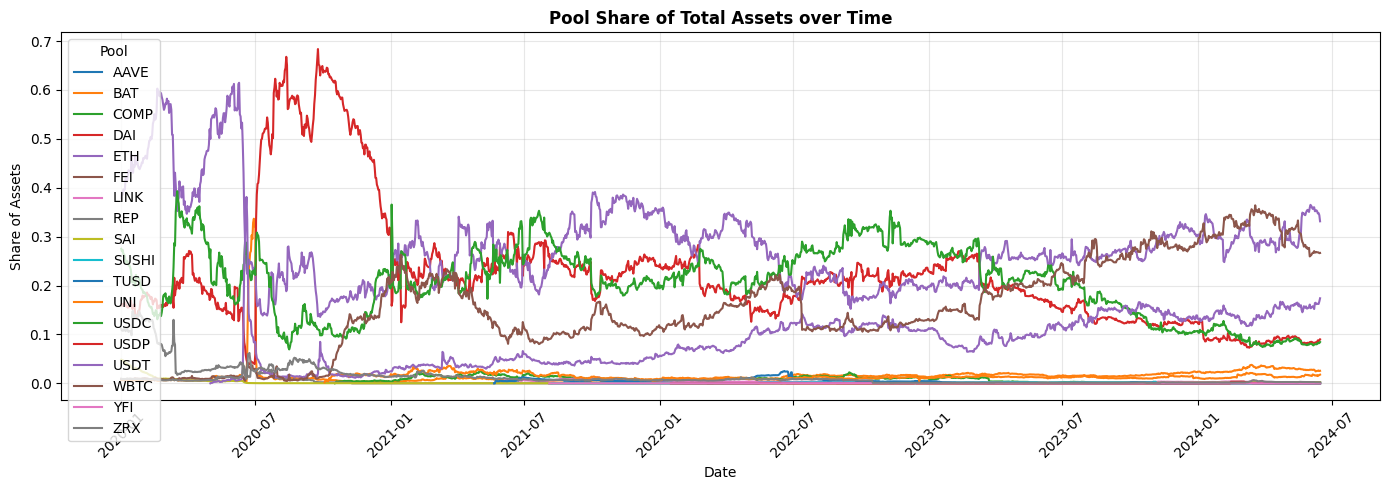

In [29]:
import matplotlib.pyplot as plt

df_assets = regr_pool_users.drop_duplicates(subset=['date', 'shockAsset'])[
    ['date', 'shockAsset', 'assets']
].sort_values('date').copy()

# Recompute total_assets on deduplicated data
df_assets['total_assets'] = df_assets.groupby('date')['assets'].transform('sum')
df_assets['share_assets'] = df_assets['assets'] / df_assets['total_assets']

fig, ax = plt.subplots(figsize=(14, 5))
for asset, df_a in df_assets.groupby('shockAsset'):
    ax.plot(df_a['date'], df_a['share_assets'], label=asset, linewidth=1.5)

ax.set_title('Pool Share of Total Assets over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Share of Assets')
ax.legend(title='Pool')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✓ share_assets sums to 1 at every date.
  Pools exceeding 0.05 share at some point: ['DAI', 'ETH', 'USDC', 'USDT', 'WBTC']


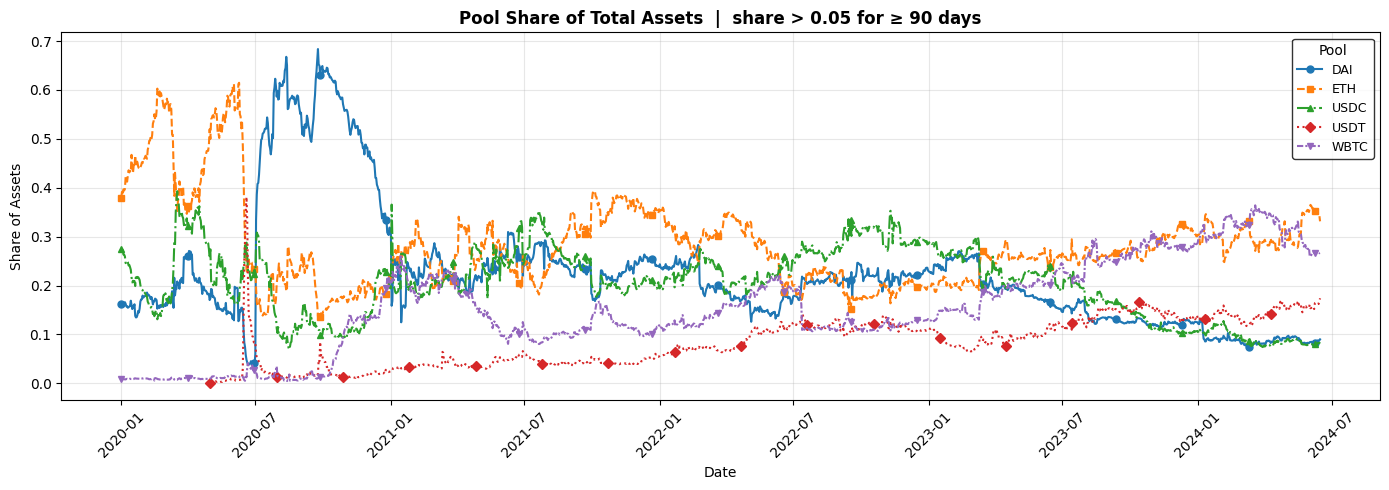

In [30]:
# Select pools and plot their share of total assets over time, keeping only those that exceed a certain share threshold for a minimum number of days

df_assets = regr_pool_users.drop_duplicates(subset=['date', 'shockAsset'])[
    ['date', 'shockAsset', 'assets']
].sort_values('date').copy()

# Recompute total_assets on deduplicated data
df_assets['total_assets'] = df_assets.groupby('date')['assets'].transform('sum')
df_assets['share_assets'] = df_assets['assets'] / df_assets['total_assets']

# Verify
share_check = df_assets.groupby('date')['share_assets'].sum()
bad_dates = share_check[~((share_check - 1).abs() < 1e-6)]
if len(bad_dates) == 0:
    print("✓ share_assets sums to 1 at every date.")
else:
    print(f"✗ {len(bad_dates)} dates where share_assets ≠ 1")
    print(bad_dates)


# ── Keep only pools that exceed 0.005 share at some point ────────
SHARE_THRESHOLD = 0.05  # ← adjust here
MIN_DAYS        = 90     # ← adjust here

def days_above_threshold(df, threshold):
    df_above = df[df['share_assets'] >= threshold].sort_values('date')
    if len(df_above) < 2:
        return 0
    # sum consecutive date spans where share is above threshold
    dates = df_above['date'].values
    total_days = sum(
        (dates[i+1] - dates[i]).astype('timedelta64[D]').astype(int)
        for i in range(len(dates) - 1)
    )
    return total_days

days_above = df_assets.groupby('shockAsset').apply(
    lambda x: days_above_threshold(x, SHARE_THRESHOLD)
)
qualifying = days_above[days_above >= MIN_DAYS].index.tolist()

df_plot = df_assets[df_assets['shockAsset'].isin(qualifying)]

print(f"  Pools exceeding {SHARE_THRESHOLD} share at some point: {qualifying}")

# ── Plot ─────────────────────────────────────────────────────────
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]
markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '+']
colors     = plt.cm.tab10.colors  # 10 distinct colors

fig, ax = plt.subplots(figsize=(14, 5))

for i, (asset, df_a) in enumerate(df_plot.groupby('shockAsset')):
    ax.plot(df_a['date'], df_a['share_assets'],
            label=asset,
            color=colors[i % len(colors)],
            linewidth=1.5,
            linestyle=linestyles[i % len(linestyles)],
            marker=markers[i % len(markers)],
            markevery=90,
            markersize=5)

ax.set_title(f'Pool Share of Total Assets  |  share > {SHARE_THRESHOLD} for ≥ {MIN_DAYS} days',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Share of Assets')
ax.legend(title='Pool', fontsize=9, frameon=True, edgecolor='black')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pool_share_assets.png', bbox_inches='tight', dpi=300)
plt.show()

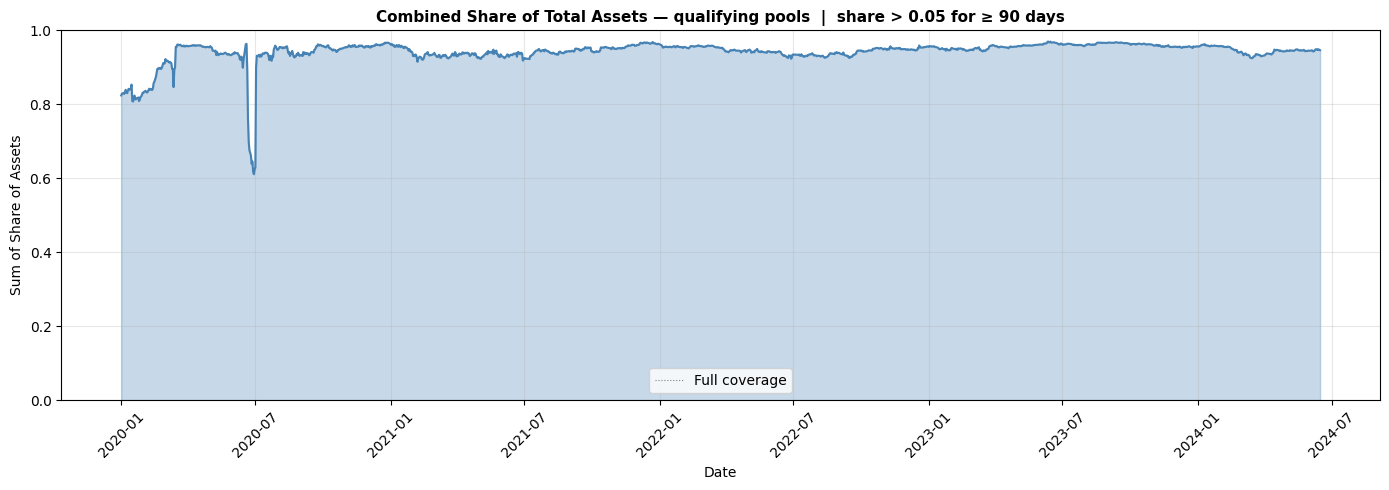

In [31]:
# Summ contribution of selected pools to total assets over time
# Sum of share_assets for qualifying pools at each date
df_qualifying_sum = df_plot.groupby('date')['share_assets'].sum().reset_index()
df_qualifying_sum.rename(columns={'share_assets': 'share_assets_qualifying'}, inplace=True)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_qualifying_sum['date'], df_qualifying_sum['share_assets_qualifying'],
                alpha=0.3, color='steelblue')
ax.plot(df_qualifying_sum['date'], df_qualifying_sum['share_assets_qualifying'],
        color='steelblue', linewidth=1.5)


ax.axhline(1, color='grey', linestyle=':', linewidth=0.8, label='Full coverage')
ax.set_ylim(0, 1)
ax.set_title(f'Combined Share of Total Assets — qualifying pools  |  share > {SHARE_THRESHOLD} for ≥ {MIN_DAYS} days',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sum of Share of Assets')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

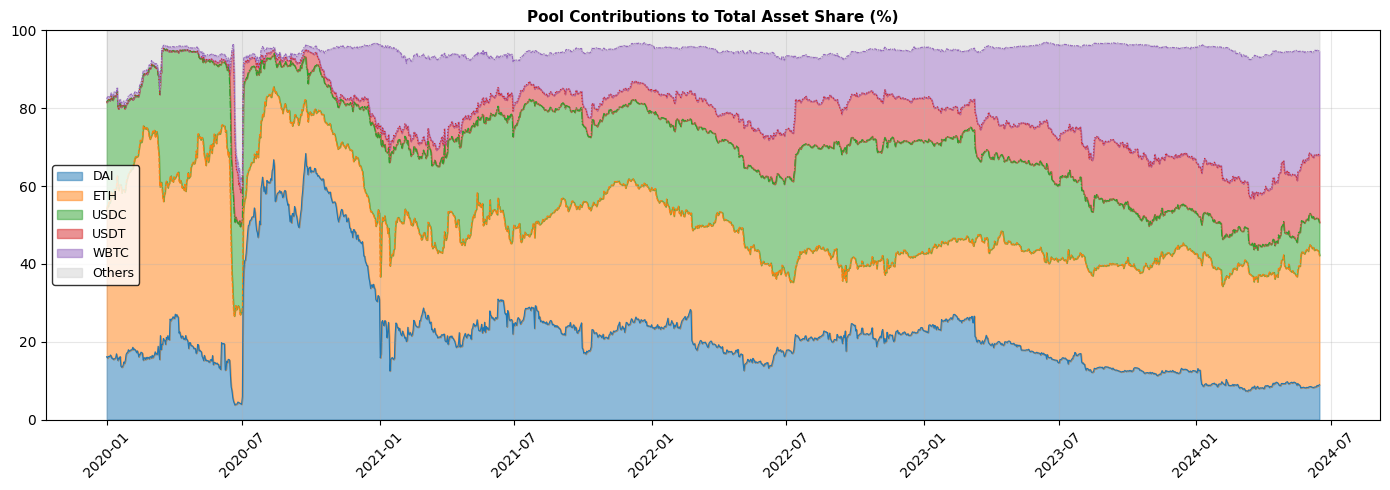

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))

linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]
colors     = plt.cm.tab10.colors

assets_ordered = sorted(df_plot['shockAsset'].unique())

cumulative = None
for i, asset in enumerate(assets_ordered):
    df_a = df_plot[df_plot['shockAsset'] == asset].set_index('date')['share_assets']
    df_a = df_a.reindex(df_qualifying_sum['date']).fillna(0).values * 100

    bottom = cumulative if cumulative is not None else np.zeros(len(df_a))
    top    = bottom + df_a

    ax.fill_between(df_qualifying_sum['date'], bottom, top,
                    alpha=0.5, color=colors[i % len(colors)], label=asset)
    ax.plot(df_qualifying_sum['date'], top,
            color=colors[i % len(colors)], linewidth=0.8,
            linestyle=linestyles[i % len(linestyles)])

    cumulative = top

# ── Others: remainder to 100 ─────────────────────────────────
others = 100 - cumulative
ax.fill_between(df_qualifying_sum['date'], cumulative, cumulative + others,
                alpha=0.5, color='lightgrey', label='Others')
ax.plot(df_qualifying_sum['date'], cumulative + others,
        color='lightgrey', linewidth=0.8)

ax.set_ylim(0, 100)
ax.set_title(f'Pool Contributions to Total Asset Share (%)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(fontsize=9, frameon=True, edgecolor='black')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


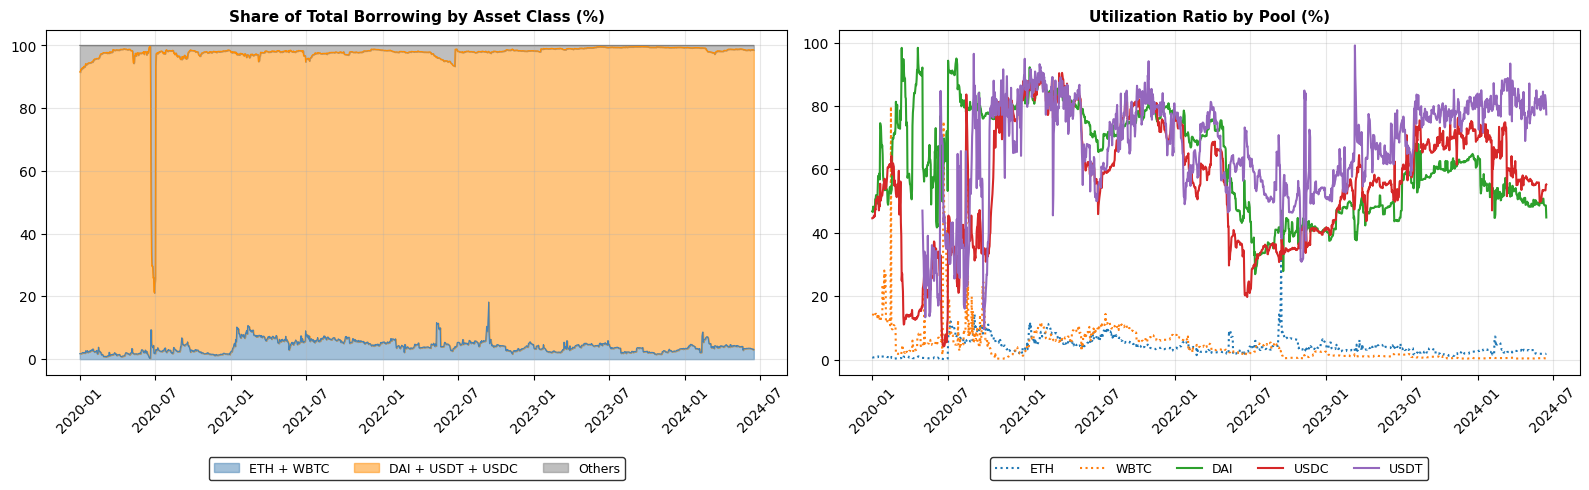

In [33]:
crypto      = ['ETH', 'WBTC']
stablecoins = ['USDC', 'DAI', 'USDT']

df_base = regr_pool_users.drop_duplicates(subset=['date', 'shockAsset'])[
    ['date', 'shockAsset', 'utilization_ratio', 'pctBorrow']
].sort_values('date').copy()

df_base['group'] = df_base['shockAsset'].apply(
    lambda s: 'Crypto' if s in crypto else ('Stablecoins' if s in stablecoins else 'Others')
)

dates = df_qualifying_sum['date']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: pctBorrow — stacked by group ──────────────────────
ax = axes[0]
grouped = (df_base.groupby(['date', 'group'])['pctBorrow']
           .sum().unstack('group').reindex(dates).fillna(0)) * 100

cumulative = np.zeros(len(dates))
for grp, color, label in zip(
    ['Crypto',        'Stablecoins',       'Others'],
    ['steelblue',     'darkorange',         'grey'],
    ['ETH + WBTC',    'DAI + USDT + USDC',  'Others']
):
    vals = grouped.get(grp, pd.Series(0, index=dates)).values
    ax.fill_between(dates, cumulative, cumulative + vals,
                    alpha=0.5, color=color, label=label)
    ax.plot(dates, cumulative + vals, color=color, linewidth=0.8)
    cumulative += vals


ax.set_title('Share of Total Borrowing by Asset Class (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
# Left plot legend
#axes[0].legend(loc='lower left', fontsize=9, frameon=True, edgecolor='black')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

# ── Right: utilization_ratio — individual lines ────────────────
ax = axes[1]
df_plot_ur = df_base[df_base['shockAsset'].isin(qualifying)].copy()

# Order: crypto first, then others
assets_crypto = [a for a in crypto if a in df_plot_ur['shockAsset'].unique()]
assets_other  = sorted([a for a in df_plot_ur['shockAsset'].unique() if a not in crypto])
assets_ordered = assets_crypto + assets_other

colors_ur = plt.cm.tab10.colors
color_map = {a: colors_ur[i] for i, a in enumerate(assets_ordered)}

for asset in assets_ordered:
    df_a      = df_plot_ur[df_plot_ur['shockAsset'] == asset].sort_values('date')
    linestyle = ':' if asset in crypto else '-'
    ax.plot(df_a['date'], df_a['utilization_ratio'] * 100,
            label=asset, linewidth=1.5,
            linestyle=linestyle, color=color_map[asset])

ax.set_title('Utilization Ratio by Pool (%)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.legend(loc='', fontsize=9, frameon=True, edgecolor='black')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
               ncol=3, fontsize=9, frameon=True, edgecolor='black')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
               ncol=5, fontsize=9, frameon=True, edgecolor='black')

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)




plt.tight_layout()  # keep this last so it accounts for the outside legend

#ax.legend(fontsize=9, frameon=True, edgecolor='black')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

#plt.suptitle(f'share > {SHARE_THRESHOLD} for ≥ {MIN_DAYS} days', fontsize=10)
plt.tight_layout()
plt.show()


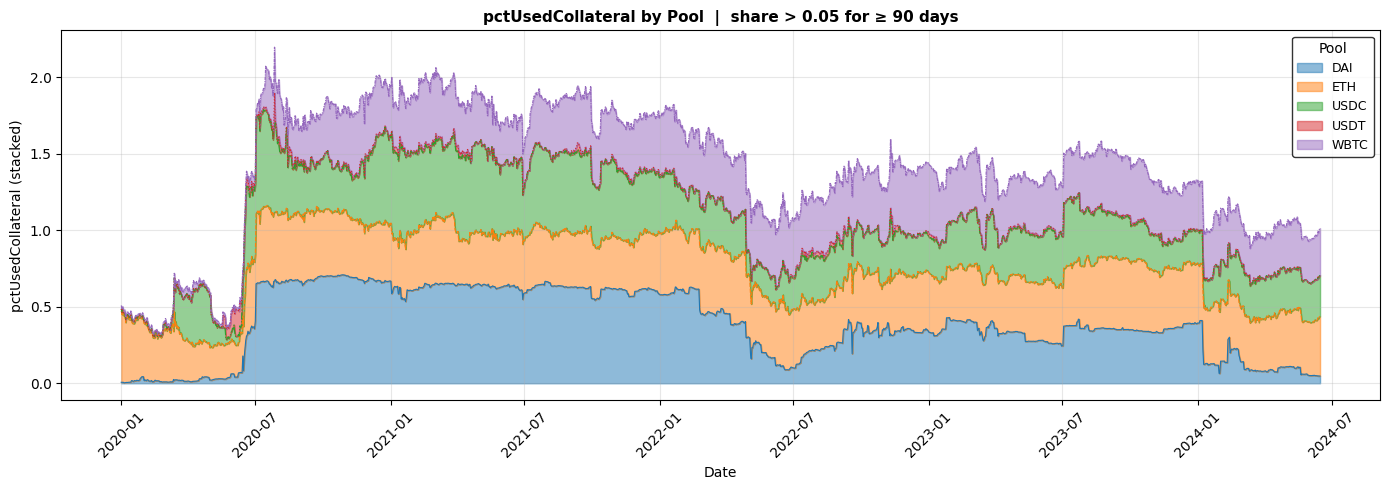

In [34]:
# Rebuild df_plot including pctUsedCollateral
df_assets_pct = regr_pool_users.drop_duplicates(subset=['date', 'shockAsset'])[
    ['date', 'shockAsset', 'pctUsedCollateral']
].sort_values('date').copy()
df_plot = df_assets_pct[df_assets_pct['shockAsset'].isin(qualifying)]

fig, ax = plt.subplots(figsize=(14, 5))

linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]
colors     = plt.cm.tab10.colors

assets_ordered = sorted(df_plot['shockAsset'].unique())
dates = df_qualifying_sum['date']

cumulative = None
for i, asset in enumerate(assets_ordered):
    df_a = (df_plot[df_plot['shockAsset'] == asset]
            .set_index('date')['pctUsedCollateral']
            .reindex(dates).fillna(0).values)

    bottom = cumulative if cumulative is not None else np.zeros(len(df_a))
    top    = bottom + df_a

    ax.fill_between(dates, bottom, top,
                    alpha=0.5, color=colors[i % len(colors)], label=asset)
    ax.plot(dates, top,
            color=colors[i % len(colors)], linewidth=0.8,
            linestyle=linestyles[i % len(linestyles)])

    cumulative = top

ax.set_title(f'pctUsedCollateral by Pool  |  share > {SHARE_THRESHOLD} for ≥ {MIN_DAYS} days',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('pctUsedCollateral (stacked)')
ax.legend(title='Pool', fontsize=9, frameon=True, edgecolor='black')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


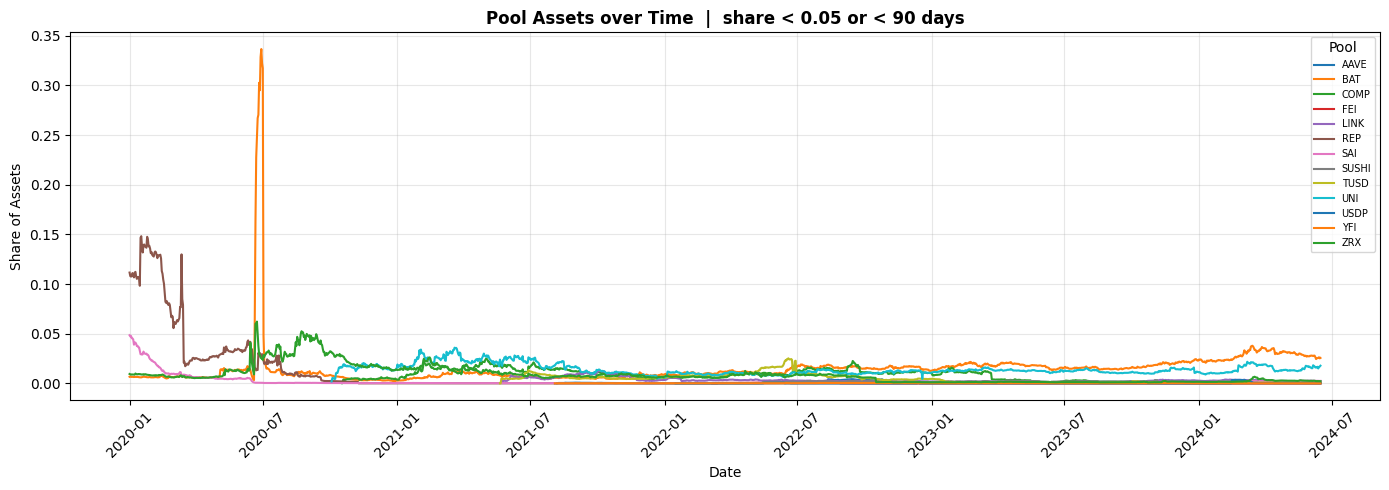

In [35]:
# Plot share of non selected pools over time
df_plot_others = df_assets[~df_assets['shockAsset'].isin(qualifying)]

fig, ax = plt.subplots(figsize=(14, 5))
for asset, df_a in df_plot_others.groupby('shockAsset'):
    ax.plot(df_a['date'], df_a['share_assets'], label=asset, linewidth=1.5)
ax.set_title(f'Pool Assets over Time  |  share < {SHARE_THRESHOLD} or < {MIN_DAYS} days',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Share of Assets')
ax.legend(title='Pool', fontsize=7)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

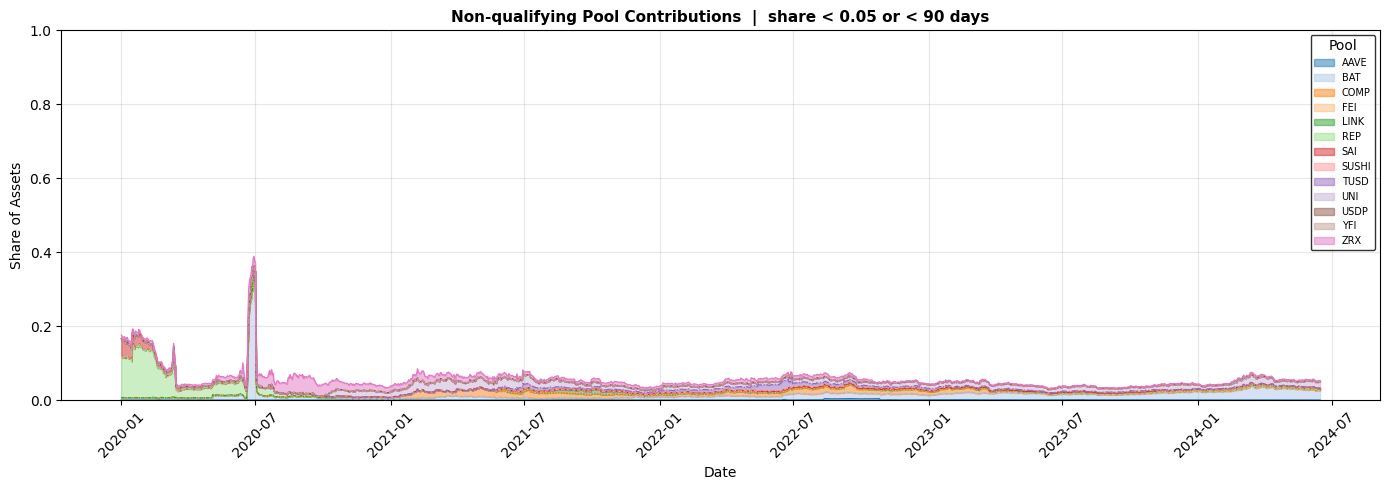

In [36]:
# Plot cumulative share of non selected pools over time (For Appendix only)

df_plot_others = df_assets[~df_assets['shockAsset'].isin(qualifying)]
df_others_sum = df_plot_others.groupby('date')['share_assets'].sum().reset_index()

assets_others = sorted(df_plot_others['shockAsset'].unique())
colors        = plt.cm.tab20.colors  # tab20 for more colors if many pools

fig, ax = plt.subplots(figsize=(14, 5))

cumulative = None
for i, asset in enumerate(assets_others):
    df_a = df_plot_others[df_plot_others['shockAsset'] == asset].set_index('date')['share_assets']
    df_a = df_a.reindex(df_others_sum['date']).fillna(0).values

    bottom = cumulative if cumulative is not None else np.zeros(len(df_a))
    top    = bottom + df_a

    ax.fill_between(df_others_sum['date'], bottom, top,
                    alpha=0.5, color=colors[i % len(colors)], label=asset)
    ax.plot(df_others_sum['date'], top,
            color=colors[i % len(colors)], linewidth=0.8,
            linestyle=linestyles[i % len(linestyles)])

    cumulative = top

ax.set_ylim(0, 1)
ax.set_title(f'Non-qualifying Pool Contributions  |  share < {SHARE_THRESHOLD} or < {MIN_DAYS} days',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Share of Assets')
ax.legend(title='Pool', fontsize=7, frameon=True, edgecolor='black')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1.2 Compare Crypto and Stablecoins

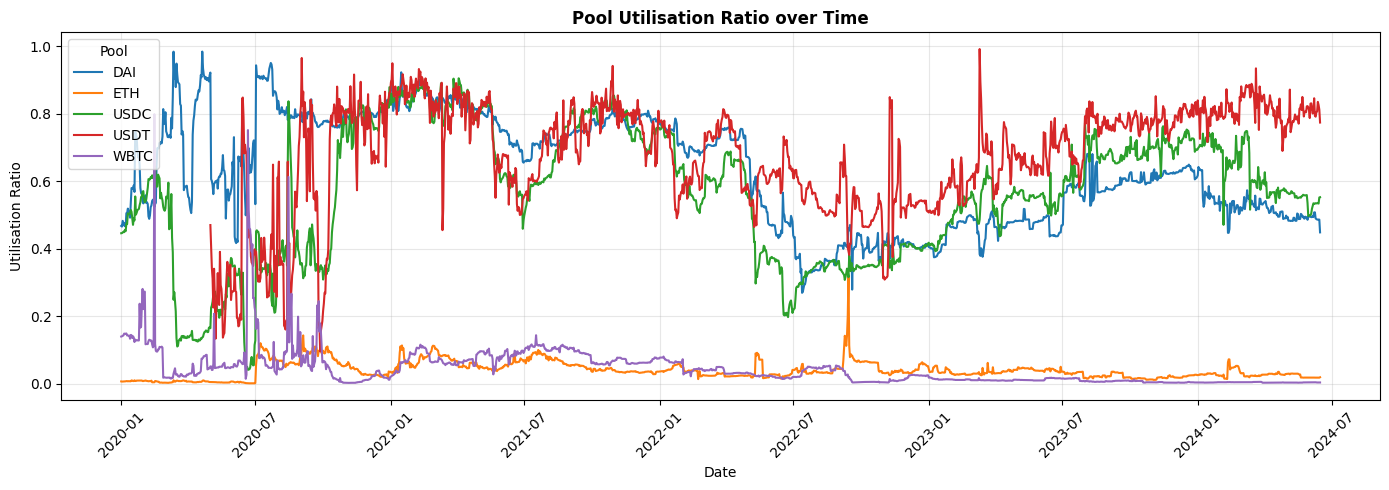

In [37]:
df_assets = regr_pool_users.drop_duplicates(subset=['date', 'shockAsset'])[
    ['date', 'shockAsset', 'utilization_ratio']
].sort_values('date').copy()

df_plot = df_assets[df_assets['shockAsset'].isin(qualifying)]

fig, ax = plt.subplots(figsize=(14, 5))
for asset, df_a in df_plot.groupby('shockAsset'):
    ax.plot(df_a['date'], df_a['utilization_ratio'], label=asset, linewidth=1.5)

ax.set_title('Pool Utilisation Ratio over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Utilisation Ratio')
ax.legend(title='Pool')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

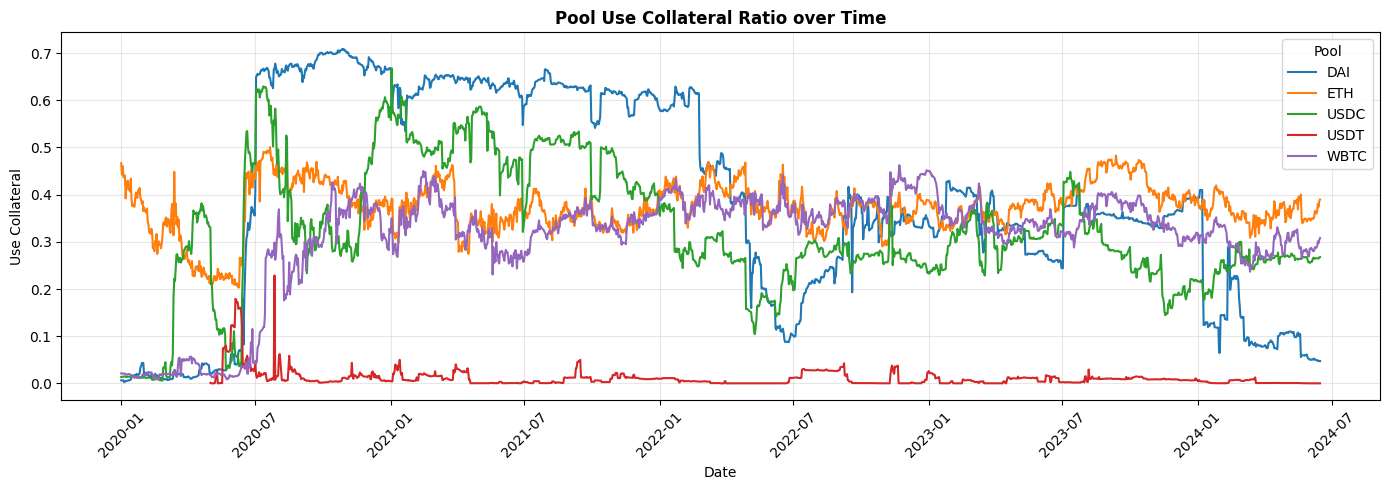

In [38]:
df_assets = regr_pool_users.drop_duplicates(subset=['date', 'shockAsset'])[
    ['date', 'shockAsset', 'pctUsedCollateral']
].sort_values('date').copy()

df_plot = df_assets[df_assets['shockAsset'].isin(qualifying)]

fig, ax = plt.subplots(figsize=(14, 5))
for asset, df_a in df_plot.groupby('shockAsset'):
    ax.plot(df_a['date'], df_a['pctUsedCollateral'], label=asset, linewidth=1.5)

ax.set_title('Pool Use Collateral Ratio over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Use Collateral')
ax.legend(title='Pool')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. ANALYSIS OF LIQUIDITY

# 2.1 Descriptive Statistics

In [39]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

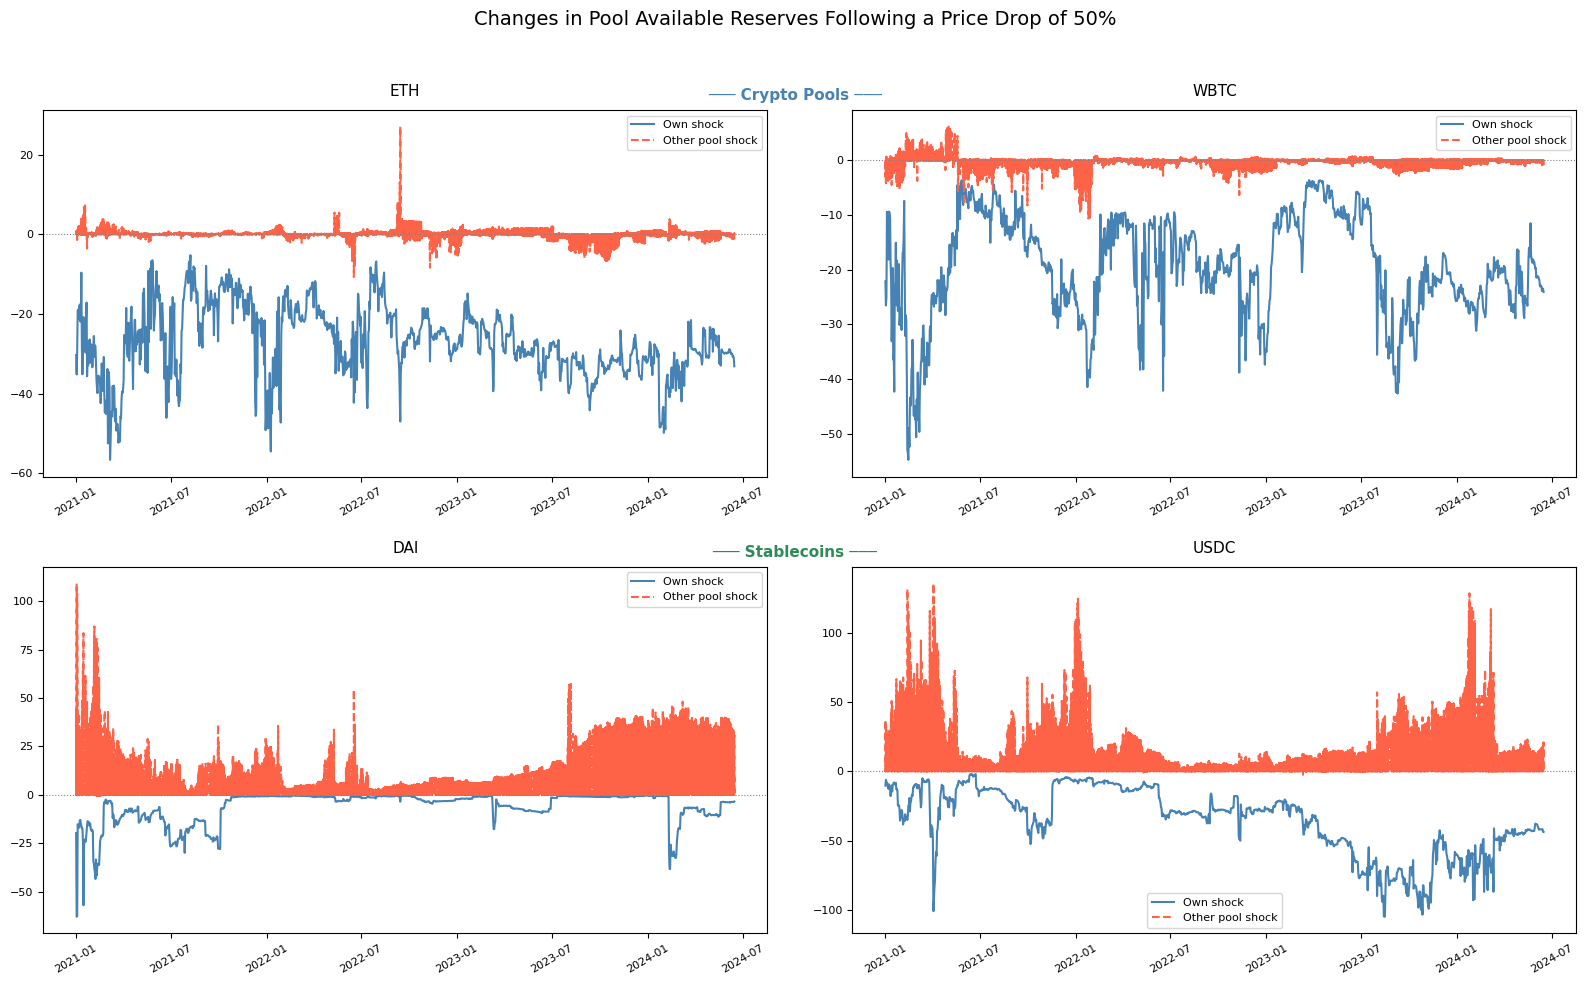

In [40]:
import math

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE      = 0.5
START_DATE     = pd.to_datetime('2021-01-01')
STABLECOINS    = ['DAI', 'USDC']
CRYPTO_POOLS   = ['ETH', 'WBTC']
SELECTED_POOLS = CRYPTO_POOLS + STABLECOINS

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    (lp['size'] == PLOT_SIZE) &
    (lp['date'] >= START_DATE)
].copy()

# ── Panel layout ─────────────────────────────────────────────────
n_cols = 2
n_rows = math.ceil(len(SELECTED_POOLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for idx, PLOT_ASSET in enumerate(SELECTED_POOLS):
    ax = axes[idx]

    df_shocked = df_plot[
        (df_plot['shockAsset'] == PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].sort_values('date').copy()

    df_notshocked = df_plot[
        (df_plot['shockAsset'] != PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].sort_values('date').copy()

    df_shocked['share_Tp_minus_T']    = (df_shocked['Tp']    - df_shocked['T'])    / df_shocked['T']*100
    df_notshocked['share_Tp_minus_T'] = (df_notshocked['Tp'] - df_notshocked['T']) / df_notshocked['T']*100


    ax.plot(df_shocked['date'],    df_shocked['share_Tp_minus_T'], label='Own shock',     color='steelblue', linewidth=1.5)
    ax.plot(df_notshocked['date'], df_notshocked['share_Tp_minus_T'], label='Other pool shock', color='tomato', linewidth=1.5, linestyle='--')

    ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
    ax.set_title(PLOT_ASSET, fontsize=11, pad=10)
    ax.set_xlabel('', fontsize=9)


    ax.set_ylabel('', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

for idx in range(len(SELECTED_POOLS), len(axes)):
    axes[idx].set_visible(False)

# ── Section headers ───────────────────────────────────────────────
n_crypto    = len(CRYPTO_POOLS)
crypto_rows = math.ceil(n_crypto / n_cols)

plt.suptitle(f'Changes in Pool Available Reserves Following a Price Drop of {int(PLOT_SIZE * 100)}%',
             fontsize=14)

plt.tight_layout(h_pad=2, w_pad=3)
plt.subplots_adjust(top=0.88)  # make room at the top

row0_top = axes[0].get_position().y1
row1_top = axes[2].get_position().y1

fig.text(0.5, row0_top + 0.01, '─── Crypto Pools ───',
         ha='center', fontsize=11, fontweight='bold', color='steelblue')
fig.text(0.5, row1_top + 0.01, '─── Stablecoins ───',
         ha='center', fontsize=11, fontweight='bold', color='seagreen')

plt.show()



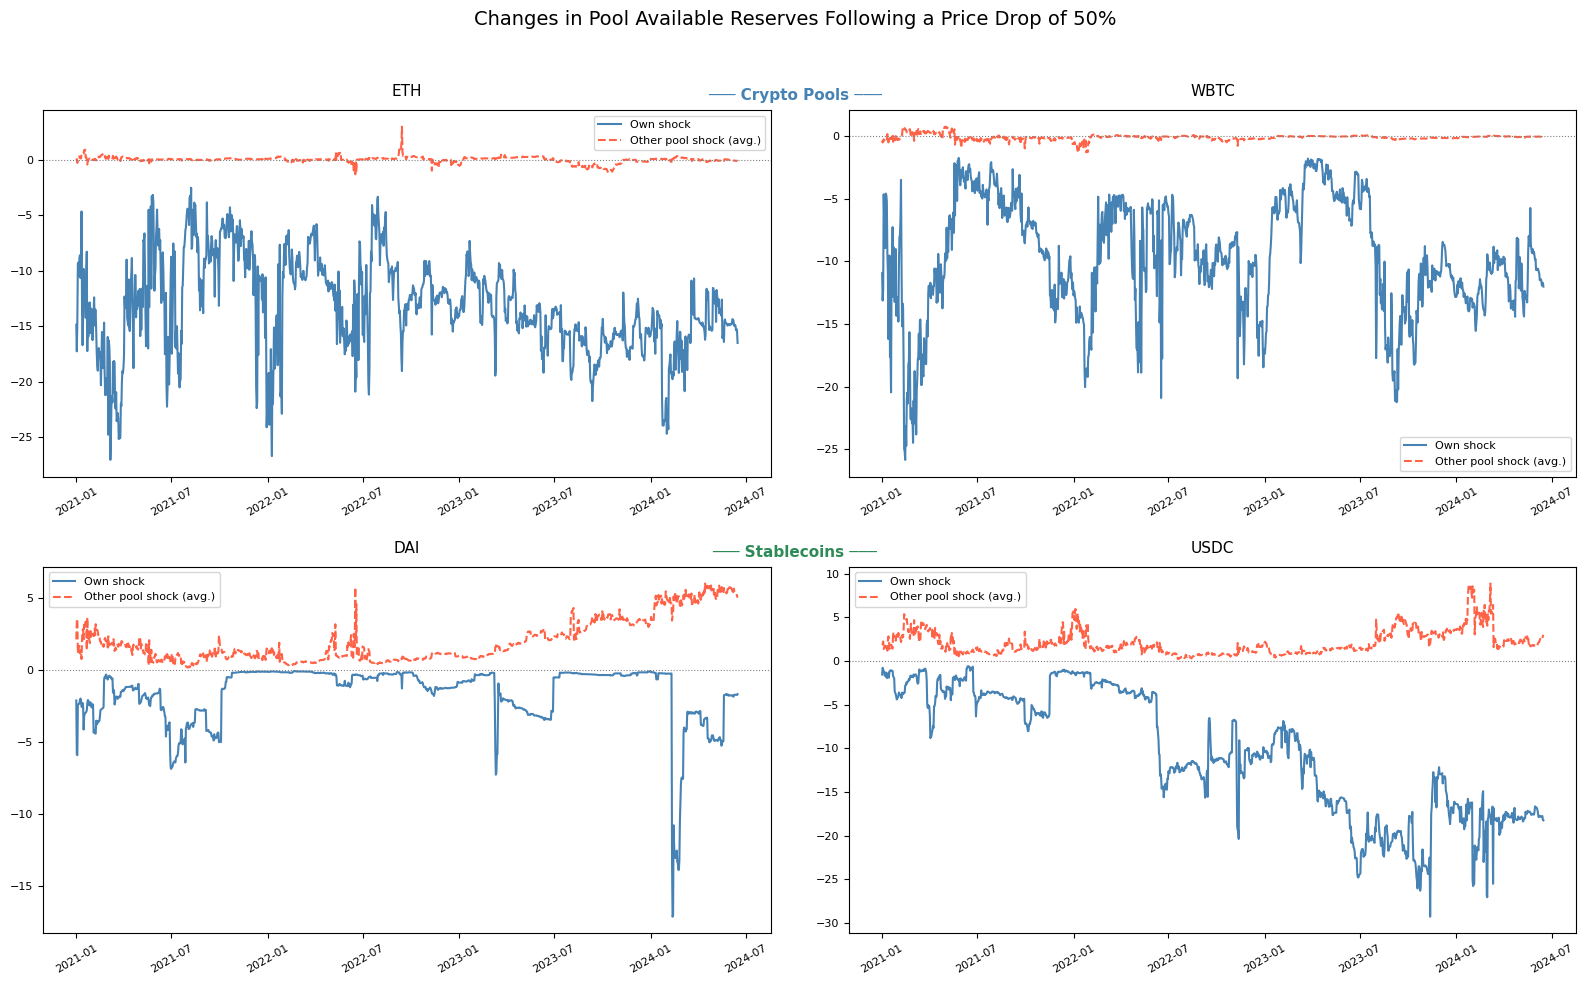

In [41]:
import math

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE      = 0.5
START_DATE     = pd.to_datetime('2021-01-01')
STABLECOINS    = ['DAI', 'USDC']
CRYPTO_POOLS   = ['ETH', 'WBTC']
SELECTED_POOLS = CRYPTO_POOLS + STABLECOINS

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    (lp['size'] == PLOT_SIZE) &
    (lp['date'] >= START_DATE)
].copy()

# ── Panel layout ─────────────────────────────────────────────────
n_cols = 2
n_rows = math.ceil(len(SELECTED_POOLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for idx, PLOT_ASSET in enumerate(SELECTED_POOLS):
    ax = axes[idx]

    df_shocked = df_plot[
        (df_plot['shockAsset'] == PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].sort_values('date').copy()

    df_notshocked = df_plot[
        (df_plot['shockAsset'] != PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].copy()

    df_shocked['share_Tp_minus_T'] = (
        (df_shocked['Tp'] - df_shocked['T']) / (df_shocked['C'] + df_shocked['T']) * 100
    )
    df_notshocked['share_Tp_minus_T'] = (
        (df_notshocked['Tp'] - df_notshocked['T']) / (df_notshocked['C'] + df_notshocked['T']) * 100
    )

    # Average across the other shocked assets on each date
    df_notshocked_avg = (
        df_notshocked
        .groupby('date')['share_Tp_minus_T']
        .mean()
        .reset_index()
        .sort_values('date')
    )

    ax.plot(df_shocked['date'], df_shocked['share_Tp_minus_T'],
            label='Own shock', color='steelblue', linewidth=1.5)
    ax.plot(df_notshocked_avg['date'], df_notshocked_avg['share_Tp_minus_T'],
            label='Other pool shock (avg.)', color='tomato',
            linewidth=1.5, linestyle='--')

    ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
    ax.set_title(PLOT_ASSET, fontsize=11, pad=10)
    ax.set_xlabel('', fontsize=9)
    ax.set_ylabel('', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

for idx in range(len(SELECTED_POOLS), len(axes)):
    axes[idx].set_visible(False)

# ── Section headers ───────────────────────────────────────────────
n_crypto    = len(CRYPTO_POOLS)
crypto_rows = math.ceil(n_crypto / n_cols)

plt.suptitle(
    f'Changes in Pool Available Reserves Following a Price Drop of {int(PLOT_SIZE * 100)}%',
    fontsize=14
)

plt.tight_layout(h_pad=2, w_pad=3)
plt.subplots_adjust(top=0.88)

row0_top = axes[0].get_position().y1
row1_top = axes[2].get_position().y1

fig.text(0.5, row0_top + 0.01, '─── Crypto Pools ───',
         ha='center', fontsize=11, fontweight='bold', color='steelblue')
fig.text(0.5, row1_top + 0.01, '─── Stablecoins ───',
         ha='center', fontsize=11, fontweight='bold', color='seagreen')

plt.savefig('reserve_changes_50pct.pdf', bbox_inches='tight', dpi=150)
plt.show()

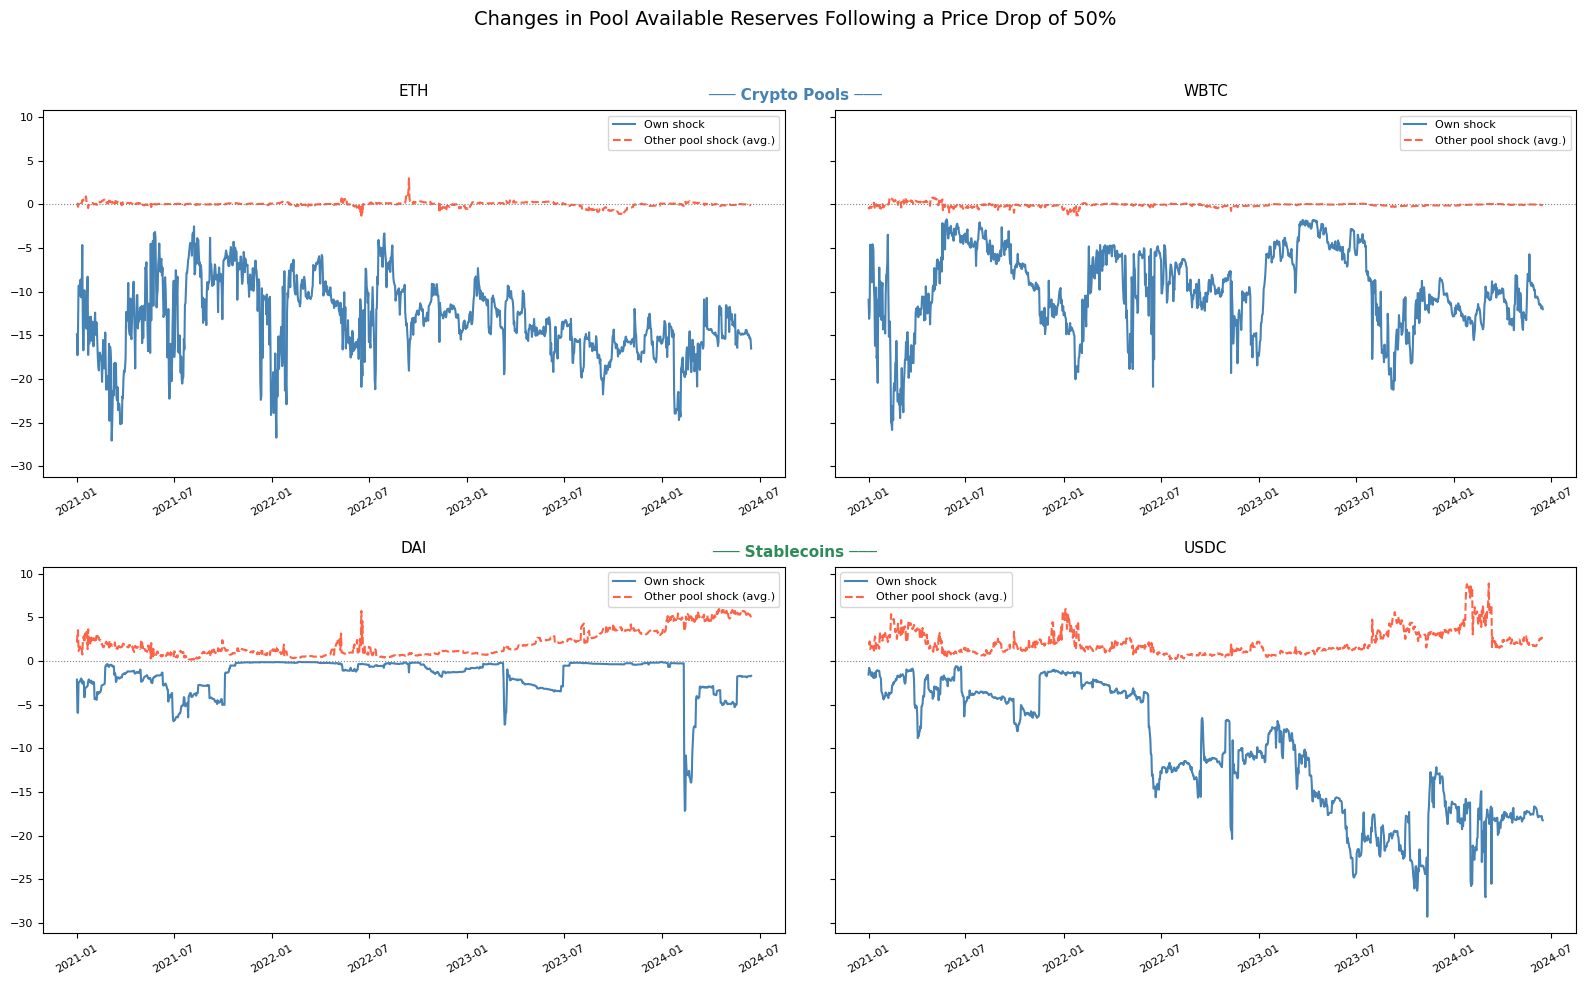

In [42]:
import math

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE      = 0.5
START_DATE     = pd.to_datetime('2021-01-01')
STABLECOINS    = ['DAI', 'USDC']
CRYPTO_POOLS   = ['ETH', 'WBTC']
SELECTED_POOLS = CRYPTO_POOLS + STABLECOINS

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    (lp['size'] == PLOT_SIZE) &
    (lp['date'] >= START_DATE)
].copy()

# ── Panel layout ─────────────────────────────────────────────────
n_cols = 2
n_rows = math.ceil(len(SELECTED_POOLS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), sharey=True)
axes = axes.flatten()

for idx, PLOT_ASSET in enumerate(SELECTED_POOLS):
    ax = axes[idx]
    df_shocked = df_plot[
        (df_plot['shockAsset'] == PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].sort_values('date').copy()
    df_notshocked = df_plot[
        (df_plot['shockAsset'] != PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].copy()
    df_shocked['share_Tp_minus_T'] = (
        (df_shocked['Tp'] - df_shocked['T']) / (df_shocked['C'] + df_shocked['T']) * 100
    )
    df_notshocked['share_Tp_minus_T'] = (
        (df_notshocked['Tp'] - df_notshocked['T']) / (df_notshocked['C'] + df_notshocked['T']) * 100
    )
    df_notshocked_avg = (
        df_notshocked
        .groupby('date')['share_Tp_minus_T']
        .mean()
        .reset_index()
        .sort_values('date')
    )
    ax.plot(df_shocked['date'], df_shocked['share_Tp_minus_T'],
            label='Own shock', color='steelblue', linewidth=1.5)
    ax.plot(df_notshocked_avg['date'], df_notshocked_avg['share_Tp_minus_T'],
            label='Other pool shock (avg.)', color='tomato',
            linewidth=1.5, linestyle='--')
    ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
    ax.set_title(PLOT_ASSET, fontsize=11, pad=10)
    ax.set_xlabel('', fontsize=9)
    ax.set_ylabel('', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# ── Force common y-scale across all panels ───────────────────────
y_min = min(ax.get_ylim()[0] for ax in axes[:len(SELECTED_POOLS)])
y_max = max(ax.get_ylim()[1] for ax in axes[:len(SELECTED_POOLS)])
for ax in axes[:len(SELECTED_POOLS)]:
    ax.set_ylim(y_min, y_max)

for idx in range(len(SELECTED_POOLS), len(axes)):
    axes[idx].set_visible(False)

# ── Section headers ───────────────────────────────────────────────
n_crypto    = len(CRYPTO_POOLS)
crypto_rows = math.ceil(n_crypto / n_cols)
plt.suptitle(
    f'Changes in Pool Available Reserves Following a Price Drop of {int(PLOT_SIZE * 100)}%',
    fontsize=14
)
plt.tight_layout(h_pad=2, w_pad=3)
plt.subplots_adjust(top=0.88)
row0_top = axes[0].get_position().y1
row1_top = axes[2].get_position().y1
fig.text(0.5, row0_top + 0.01, '─── Crypto Pools ───',
         ha='center', fontsize=11, fontweight='bold', color='steelblue')
fig.text(0.5, row1_top + 0.01, '─── Stablecoins ───',
         ha='center', fontsize=11, fontweight='bold', color='seagreen')
plt.savefig('reserve_changes_50pct.pdf', bbox_inches='tight', dpi=150)
plt.show()

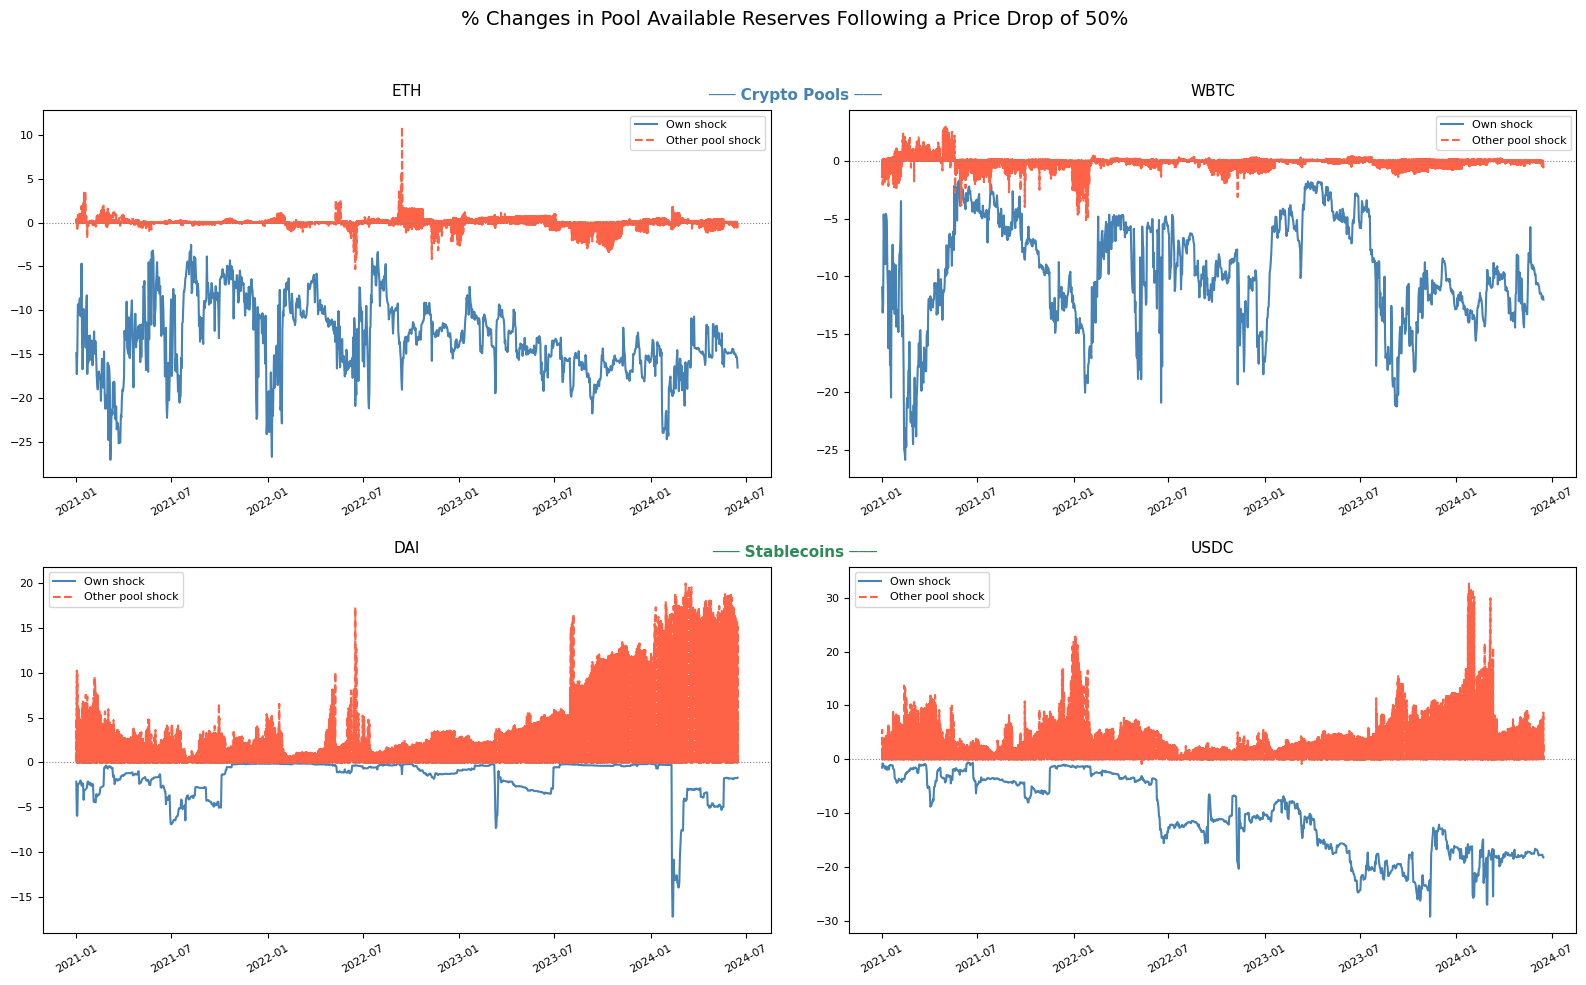

In [43]:
import math

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE      = 0.5
START_DATE     = pd.to_datetime('2021-01-01')
STABLECOINS    = ['DAI', 'USDC']
CRYPTO_POOLS   = ['ETH', 'WBTC']
SELECTED_POOLS = CRYPTO_POOLS + STABLECOINS

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    (lp['size'] == PLOT_SIZE) &
    (lp['date'] >= START_DATE)
].copy()

# ── Panel layout ─────────────────────────────────────────────────
n_cols = 2
n_rows = math.ceil(len(SELECTED_POOLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for idx, PLOT_ASSET in enumerate(SELECTED_POOLS):
    ax = axes[idx]

    df_shocked = df_plot[
        (df_plot['shockAsset'] == PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].sort_values('date').copy()

    df_notshocked = df_plot[
        (df_plot['shockAsset'] != PLOT_ASSET) &
        (df_plot['otherAsset'] == PLOT_ASSET)
    ].sort_values('date').copy()

    df_shocked['Tp_minus_T']    = (df_shocked['Tp']    - df_shocked['T'])/(df_shocked['C'] + df_shocked['T'])*100    
    df_notshocked['Tp_minus_T'] = (df_notshocked['Tp'] - df_notshocked['T']) /(df_notshocked['C'] + df_notshocked['T'])*100

    ax.plot(df_shocked['date'],    df_shocked['Tp_minus_T'], label='Own shock',     color='steelblue', linewidth=1.5)
    ax.plot(df_notshocked['date'], df_notshocked['Tp_minus_T'], label='Other pool shock', color='tomato', linewidth=1.5, linestyle='--')

    ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
    ax.set_title(PLOT_ASSET, fontsize=11, pad=10)
    ax.set_xlabel('', fontsize=9)


    ax.set_ylabel('', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

for idx in range(len(SELECTED_POOLS), len(axes)):
    axes[idx].set_visible(False)

# ── Section headers ───────────────────────────────────────────────
n_crypto    = len(CRYPTO_POOLS)
crypto_rows = math.ceil(n_crypto / n_cols)

plt.suptitle(f'% Changes in Pool Available Reserves Following a Price Drop of {int(PLOT_SIZE * 100)}%',
             fontsize=14)

plt.tight_layout(h_pad=2, w_pad=3)
plt.subplots_adjust(top=0.88)  # make room at the top

row0_top = axes[0].get_position().y1
row1_top = axes[2].get_position().y1

fig.text(0.5, row0_top + 0.01, '─── Crypto Pools ───',
         ha='center', fontsize=11, fontweight='bold', color='steelblue')
fig.text(0.5, row1_top + 0.01, '─── Stablecoins ───',
         ha='center', fontsize=11, fontweight='bold', color='seagreen')

plt.show()



In [44]:
df_shocked = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date').copy()

df_shocked['share_Tp_minus_T'] = (df_shocked['Tp_pool'] - df_shocked['T_pool']) / (df_shocked['assets'] ) * 100

df_notshocked = df_plot[
    (df_plot['shockAsset'] != PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].copy()

df_notshocked['share_Tp_minus_T'] = (df_notshocked['Tp_pool'] - df_notshocked['T_pool']) / (df_notshocked['assets'] ) * 100

df_notshocked = df_notshocked.groupby('date')['share_Tp_minus_T'].mean().reset_index().sort_values('date')

# Quick sanity check
print(df_shocked.shape, df_notshocked.shape)
print(df_notshocked['share_Tp_minus_T'].describe())

KeyError: 'Tp_pool'

In [ ]:
print(lp.groupby(['shockAsset', 'otherAsset'], dropna=False).size().reset_index().to_string())

    shockAsset otherAsset      0
0          DAI       AAVE  10470
1          DAI        BAT  16280
2          DAI       COMP  13380
3          DAI        DAI  16280
4          DAI        ETH  16280
5          DAI        FEI   8360
6          DAI       LINK  11210
7          DAI        REP  16280
8          DAI        SAI  16280
9          DAI      SUSHI  10470
10         DAI       TUSD  11220
11         DAI        UNI  13520
12         DAI       USDC  16280
13         DAI       USDP   8960
14         DAI       USDT  15070
15         DAI       WBTC  16280
16         DAI        YFI  10470
17         DAI        ZRX  16280
18         ETH       AAVE  10470
19         ETH        BAT  16280
20         ETH       COMP  13380
21         ETH        DAI  16280
22         ETH        ETH  16280
23         ETH        FEI   8360
24         ETH       LINK  11210
25         ETH        REP  16280
26         ETH        SAI  16280
27         ETH      SUSHI  10470
28         ETH       TUSD  11220
29        

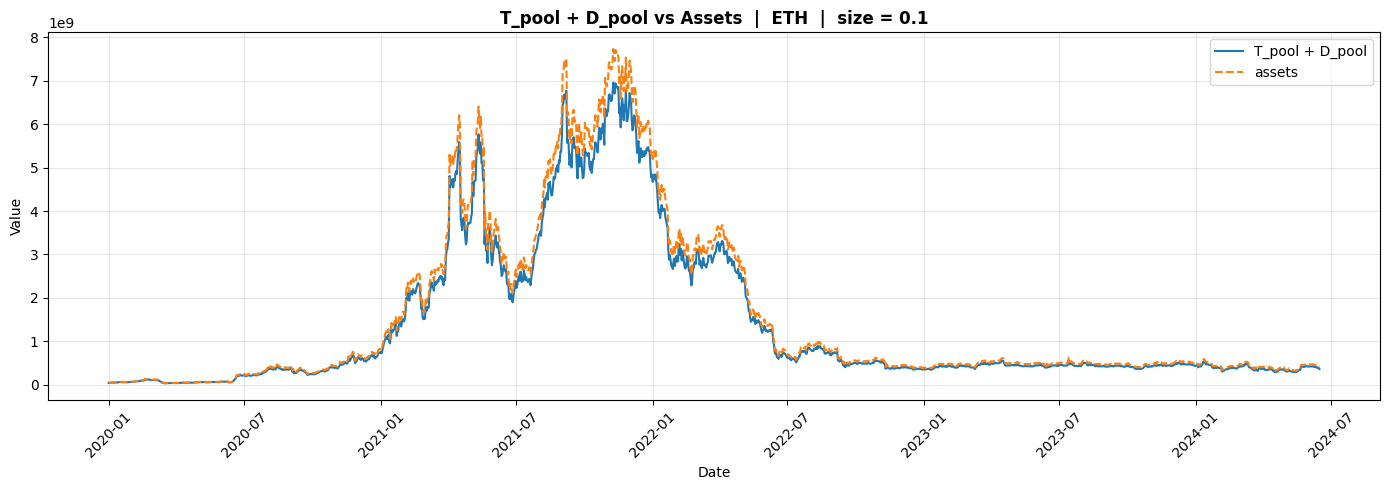

In [ ]:
# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE  = 0.1    # ← change size here
PLOT_ASSET = 'ETH'  # ← change pool here

# ── Filter ───────────────────────────────────────────────────────
df_check = final[
    (final['size']       == PLOT_SIZE) &
    (final['shockAsset'] == PLOT_ASSET)
].sort_values('date')

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_check['date'], df_check['T_pool'] + df_check['D_pool'],
        label='T_pool + D_pool', linewidth=1.5)
ax.plot(df_check['date'], df_check['assets'],
        label='assets', linewidth=1.5, linestyle='--')

ax.set_title(f'T_pool + D_pool vs Assets  |  {PLOT_ASSET}  |  size = {PLOT_SIZE}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



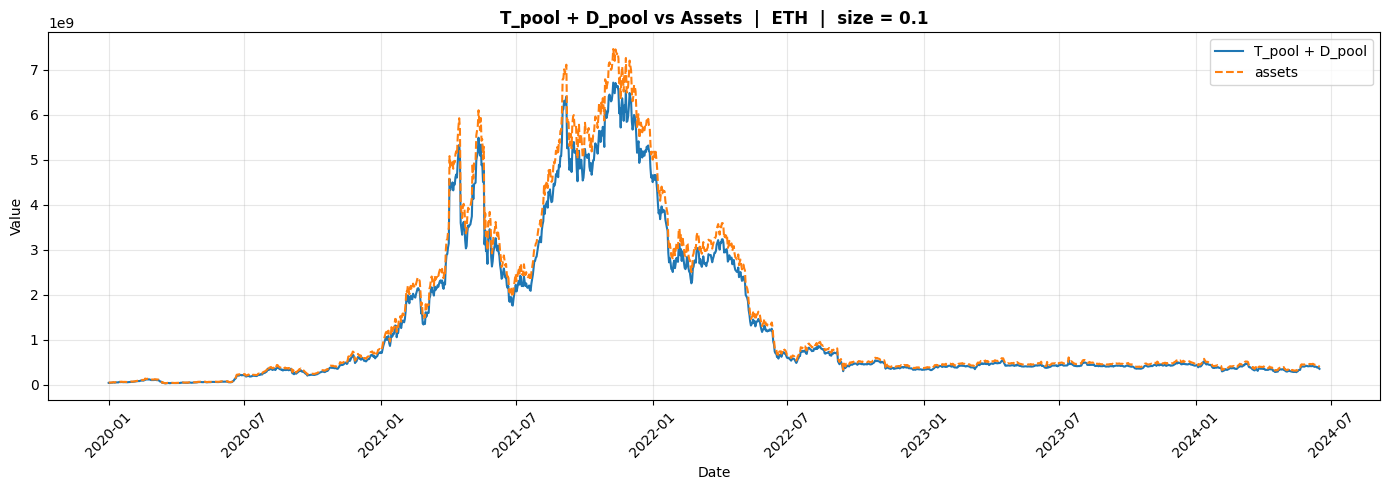

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_check['date'], df_check['T_pool'] ,
        label='T_pool + D_pool', linewidth=1.5)
ax.plot(df_check['date'], df_check['ext_assets'],
        label='assets', linewidth=1.5, linestyle='--')

ax.set_title(f'T_pool + D_pool vs Assets  |  {PLOT_ASSET}  |  size = {PLOT_SIZE}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ANALYSIS OF ETHEREUM

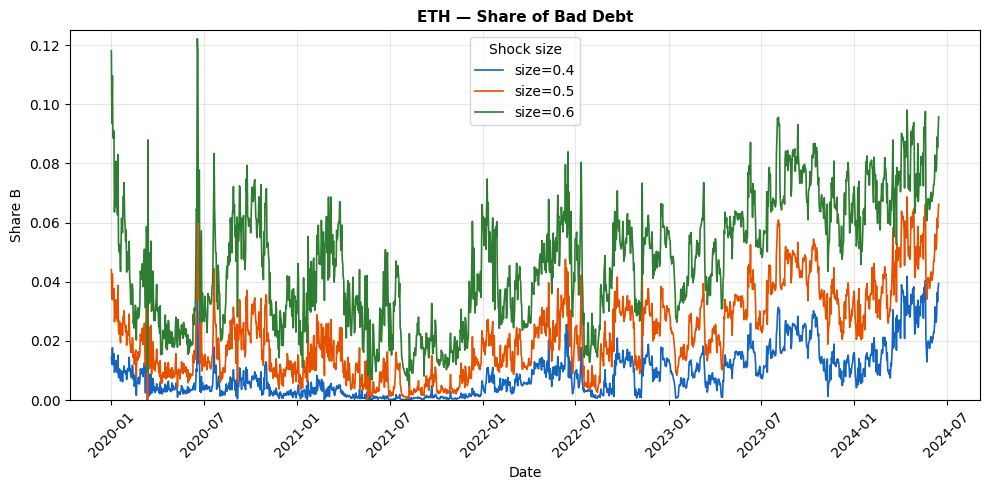

In [ ]:
SHOCK_SIZES = [0.4, 0.5, 0.6]
colors_size = {0.4: '#1565C0', 0.5: '#E65100', 0.6: '#2E7D32'}

fig, ax = plt.subplots(figsize=(10, 5))

for size in SHOCK_SIZES:
    df_a = regr_pool_users[
        (regr_pool_users['shockAsset'] == 'ETH') &
        (regr_pool_users['size'] == size)
    ]
    ax.plot(df_a['date'], df_a['share_B'],
            color=colors_size[size], linewidth=1.2, label=f'size={size}')

ax.set_title('ETH — Share of Bad Debt', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Share B')
ax.set_ylim(0, 0.125)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
ax.legend(title='Shock size')

plt.tight_layout()
plt.savefig('timeseries_share_bad_debt_ETH.png', bbox_inches='tight', dpi=300)
plt.show()

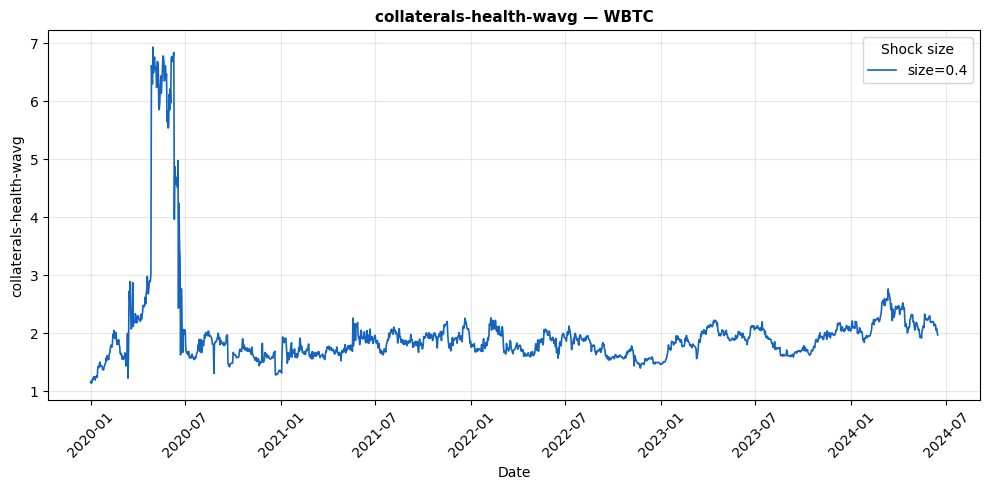

In [ ]:
SHOCK_SIZES = [0.4]
colors_size = {0.4: '#1565C0'}

fig, ax = plt.subplots(figsize=(10, 5))

for size in SHOCK_SIZES:
    df_a = regr_pool_users[
        (regr_pool_users['shockAsset'] == 'WBTC') &
        (regr_pool_users['size'] == size)
    ]
    ax.plot(df_a['date'], df_a['collaterals-health-wavg'],
            color=colors_size[size], linewidth=1.2, label=f'size={size}')

ax.set_title('collaterals-health-wavg — WBTC', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('collaterals-health-wavg')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
ax.legend(title='Shock size')
plt.tight_layout()
plt.savefig('timeseries_share_bad_debt_ETH.png', bbox_inches='tight', dpi=300)
plt.show()

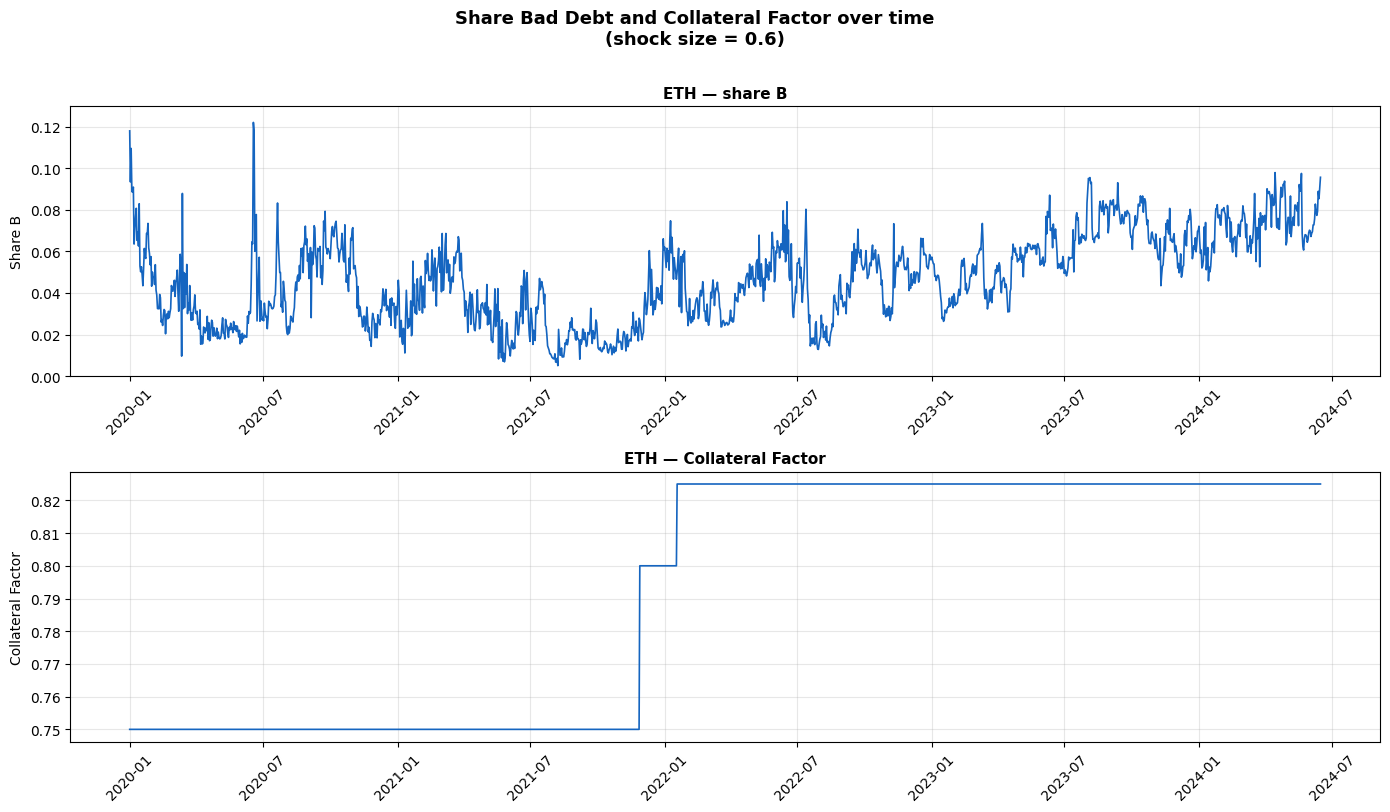

In [ ]:

# ── Filter to shock size 0.6, ETH and WBTC ───────────────────
df_plot = regr_pool_users[
    (regr_pool_users['size'] == 0.6) &
    (regr_pool_users['shockAsset'].isin(['ETH']))
].copy().sort_values('date')

fig, axes = plt.subplots(2,1, figsize=(14, 8), sharex=False)

colors = {'ETH': '#1565C0', 'WBTC': '#6A1B9A'}

for col_idx, asset in enumerate(['ETH', 'WBTC']):
    df_a = df_plot[df_plot['shockAsset'] == asset].sort_values('date')
    color = colors[asset]

    # ── B ──────────────────────────────────────────────
    ax_pr = axes[0 ]
    ax_pr.plot(df_a['date'], df_a['share_B'],
               color=color, linewidth=1.2)
    ax_pr.set_title(f'ETH — share B', fontsize=11, fontweight='bold')
    ax_pr.set_ylabel('Share B')
    ax_pr.tick_params(axis='x', rotation=45)
    ax_pr.grid(alpha=0.3)
    ax_pr.set_ylim(0, .13)
    # ── Collateral Factor ─────────────────────────────────────
    ax_cf = axes[1 ]
    ax_cf.plot(df_a['date'], df_a['collateralFactor'],
               color=color, linewidth=1.2)
    ax_cf.set_title(f'ETH — Collateral Factor', fontsize=11, fontweight='bold')
    ax_cf.set_ylabel('Collateral Factor')
    ax_cf.tick_params(axis='x', rotation=45)
    ax_cf.grid(alpha=0.3)


plt.suptitle('Share Bad Debt and Collateral Factor over time\n(shock size = 0.6)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('timeseries_cf_ETH.png', bbox_inches='tight', dpi=300)
plt.show()

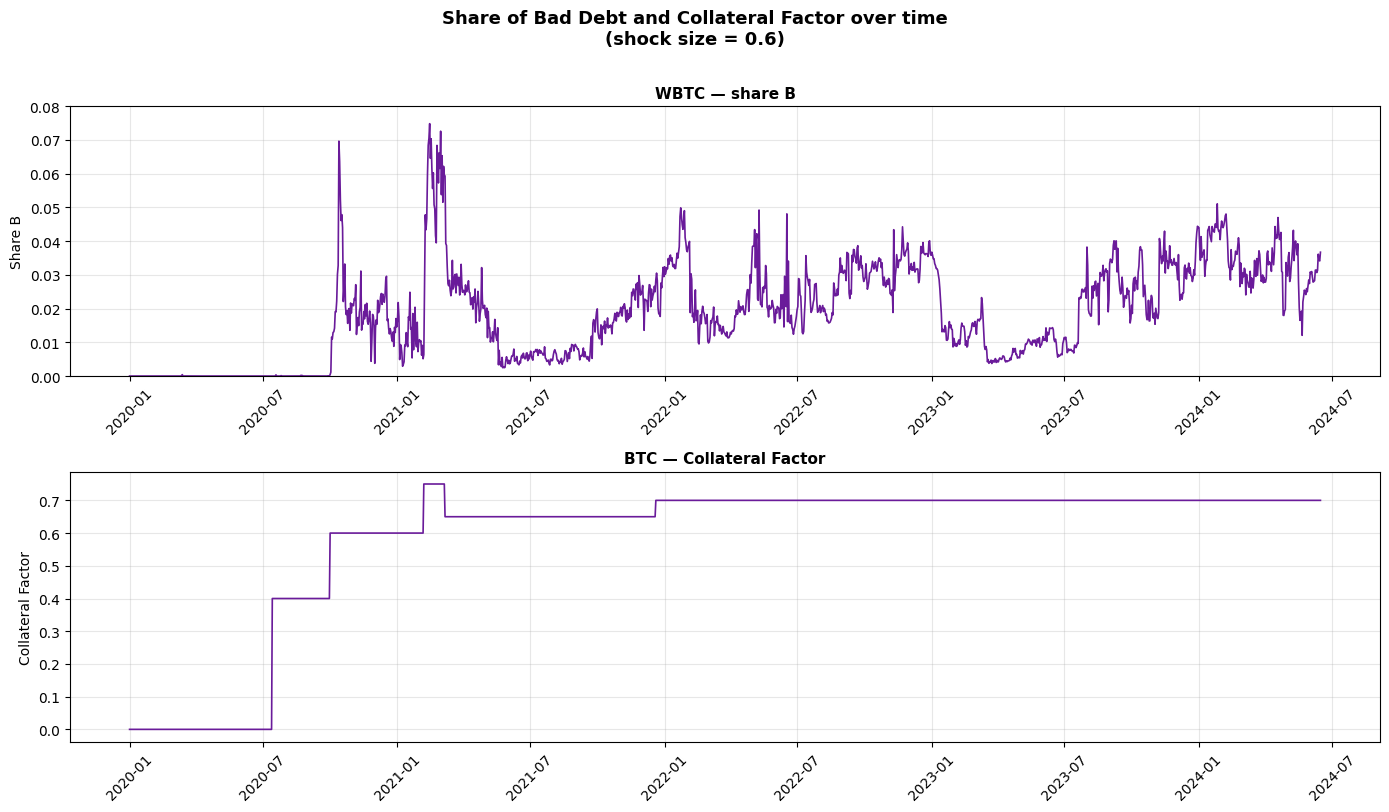

In [ ]:
# ── Filter to shock size 0., ETH and WBTC ───────────────────
df_plot = regr_pool_users[
    (regr_pool_users['size'] == 0.6) &
    (regr_pool_users['shockAsset'].isin(['WBTC']))
].copy().sort_values('date')

fig, axes = plt.subplots(2,1, figsize=(14, 8), sharex=False)

colors = {'ETH': '#1565C0', 'WBTC': '#6A1B9A'}

for col_idx, asset in enumerate(['ETH', 'WBTC']):
    df_a = df_plot[df_plot['shockAsset'] == asset].sort_values('date')
    color = colors[asset]

    # ── B ──────────────────────────────────────────────
    ax_pr = axes[0 ]
    ax_pr.plot(df_a['date'], df_a['share_B'],
               color=color, linewidth=1.2)
    ax_pr.set_title(f'WBTC — share B', fontsize=11, fontweight='bold')
    ax_pr.set_ylabel('Share B')
    ax_pr.tick_params(axis='x', rotation=45)
    ax_pr.grid(alpha=0.3)
    ax_pr.set_ylim(0, .08)
    # ── Collateral Factor ─────────────────────────────────────
    ax_cf = axes[1 ]
    ax_cf.plot(df_a['date'], df_a['collateralFactor'],
               color=color, linewidth=1.2)
    ax_cf.set_title(f'BTC — Collateral Factor', fontsize=11, fontweight='bold')
    ax_cf.set_ylabel('Collateral Factor')
    ax_cf.tick_params(axis='x', rotation=45)
    ax_cf.grid(alpha=0.3)


plt.suptitle('Share of Bad Debt and Collateral Factor over time\n(shock size = 0.6)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('timeseries_cf_BTC.png', bbox_inches='tight', dpi=300)
plt.show()

### Structural Break

In [ ]:
# WARNING: Set arbitrary break date !
break_date = pd.to_datetime('2021-01-01')  # or use this fixed date if you prefer

### ANALYSIS OF USDC AND DAI

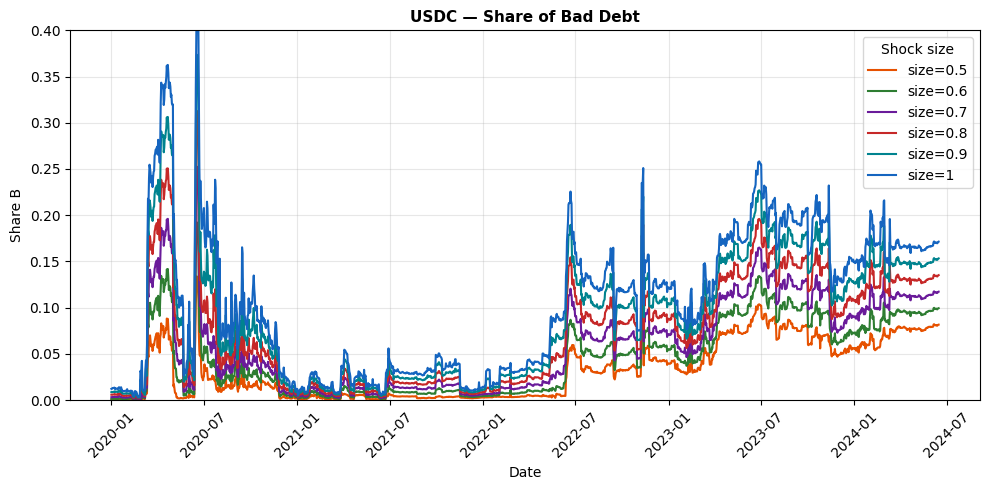

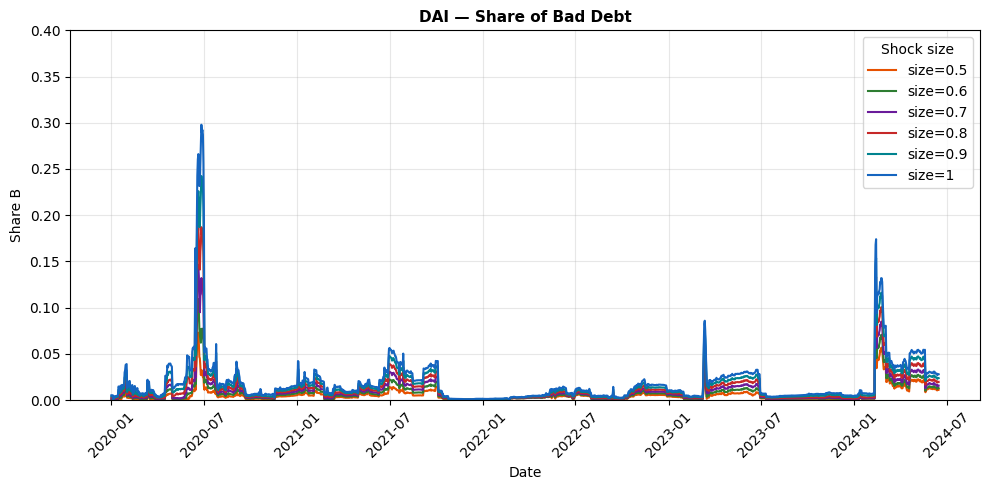

In [ ]:
SHOCK_SIZES = [0.5, 0.6, 0.7, 0.8, 0.9, 1]

colors_size = {
    0.5: '#E65100',  # orange
    0.6: '#2E7D32',  # green
    0.7: '#6A1B9A',  # purple
    0.8: '#C62828',  # red
    0.9: '#00838F',   # teal
    1.0: '#1565C0',  # blue
}

for asset in ['USDC', 'DAI']:
    fig, ax = plt.subplots(figsize=(10, 5))

    for size in SHOCK_SIZES:
        df_a = regr_pool_users[
            (regr_pool_users['shockAsset'] == asset) &
            (regr_pool_users['size'] == size)
        ]

        ax.plot(
            df_a['date'],
            df_a['share_B'],
            color=colors_size[size],
            linewidth=1.5,
            label=f'size={size}'
        )

    ax.set_title(f'{asset} — Share of Bad Debt', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Share B')
    ax.set_ylim(0, 0.4)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(title='Shock size')

    plt.tight_layout()
    plt.savefig(f'timeseries_share_bad_debt_{asset}.png', bbox_inches='tight', dpi=300)
    plt.show()

### LIQUIDITY (ETH and WTBC)

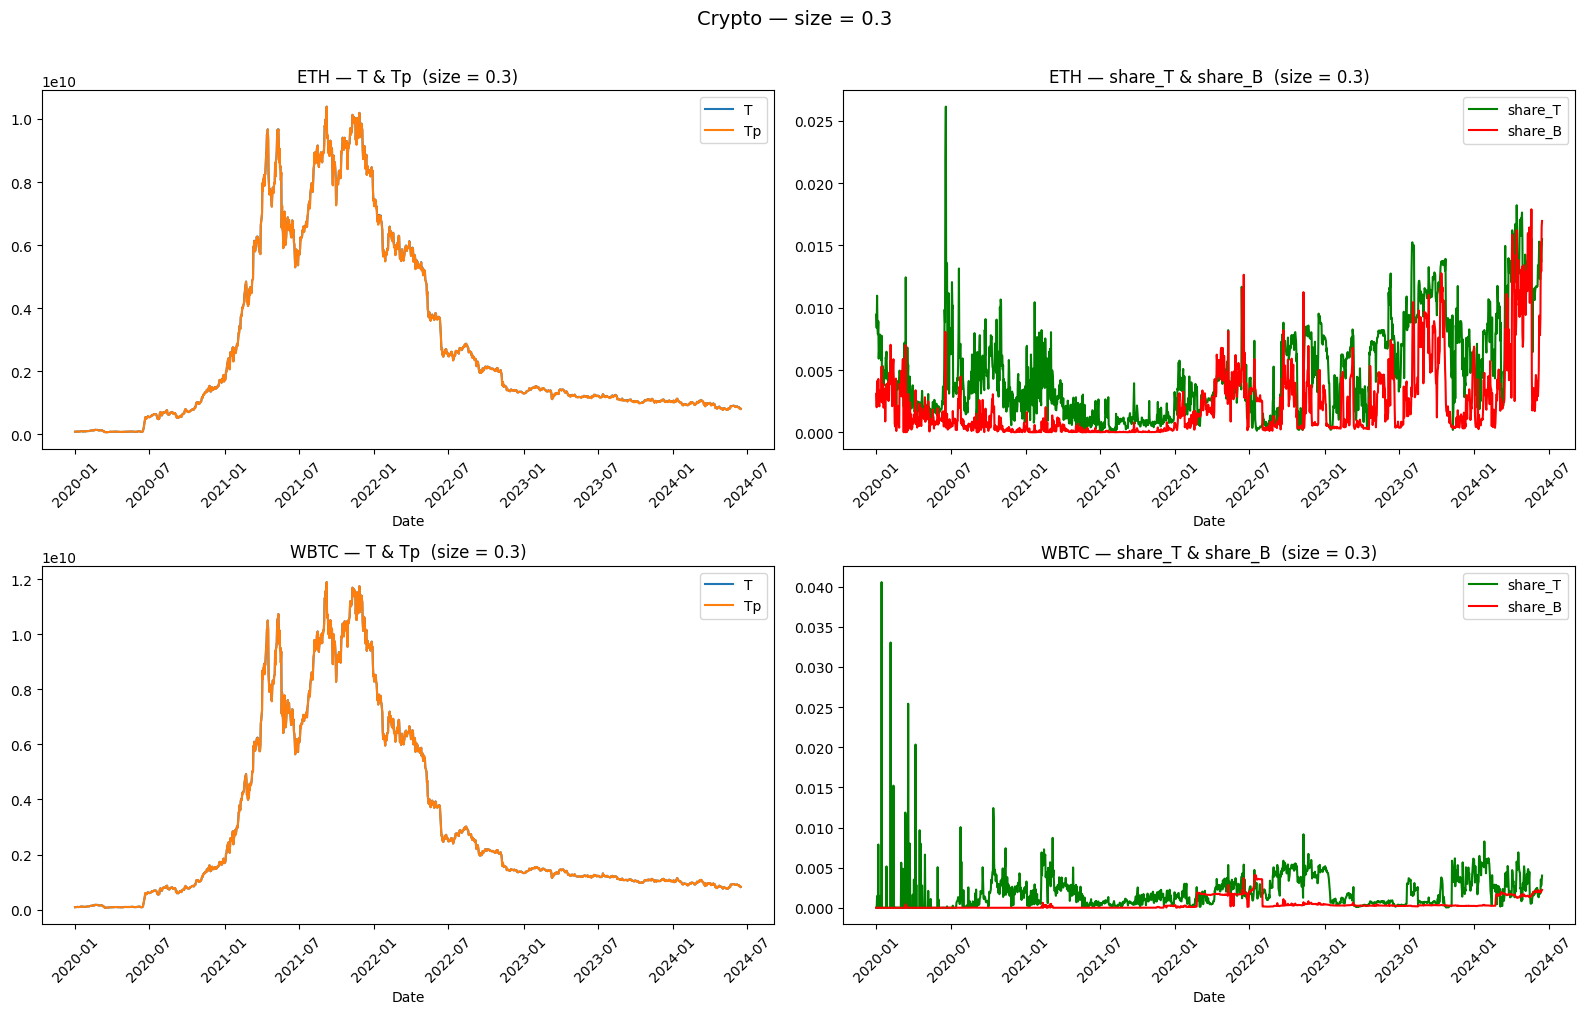

In [ ]:
import matplotlib.pyplot as plt

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE = 0.3   # ← change size here

# ── Filter ───────────────────────────────────────────────────────
plot_vars = ['date', 'shockAsset', 'T', 'Tp', 'share_T', 'share_B']

df_plot = regr_pool_users[
    regr_pool_users['size'] == PLOT_SIZE
][plot_vars].copy()

df_btc = df_plot[df_plot['shockAsset'] == 'WBTC'].sort_values('date')
df_eth = df_plot[df_plot['shockAsset'] == 'ETH'].sort_values('date')

# ── 2x2 Panel ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)

for row, (df, asset) in enumerate([(df_eth, 'ETH'), (df_btc, 'WBTC')]):

    # Left: T and Tp
    ax = axes[row, 0]
    ax.plot(df['date'], df['T'],  label='T',  linewidth=1.5)
    ax.plot(df['date'], df['Tp'], label='Tp', linewidth=1.5)
    ax.set_title(f'{asset} — T & Tp  (size = {PLOT_SIZE})')
    ax.set_xlabel('Date')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

    # Right: share_T and share_B
    ax = axes[row, 1]
    ax.plot(df['date'], df['share_T'], label='share_T', linewidth=1.5, color='green')
    ax.plot(df['date'], df['share_B'], label='share_B', linewidth=1.5, color='red')
    ax.set_title(f'{asset} — share_T & share_B  (size = {PLOT_SIZE})')
    ax.set_xlabel('Date')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Crypto — size = {PLOT_SIZE}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

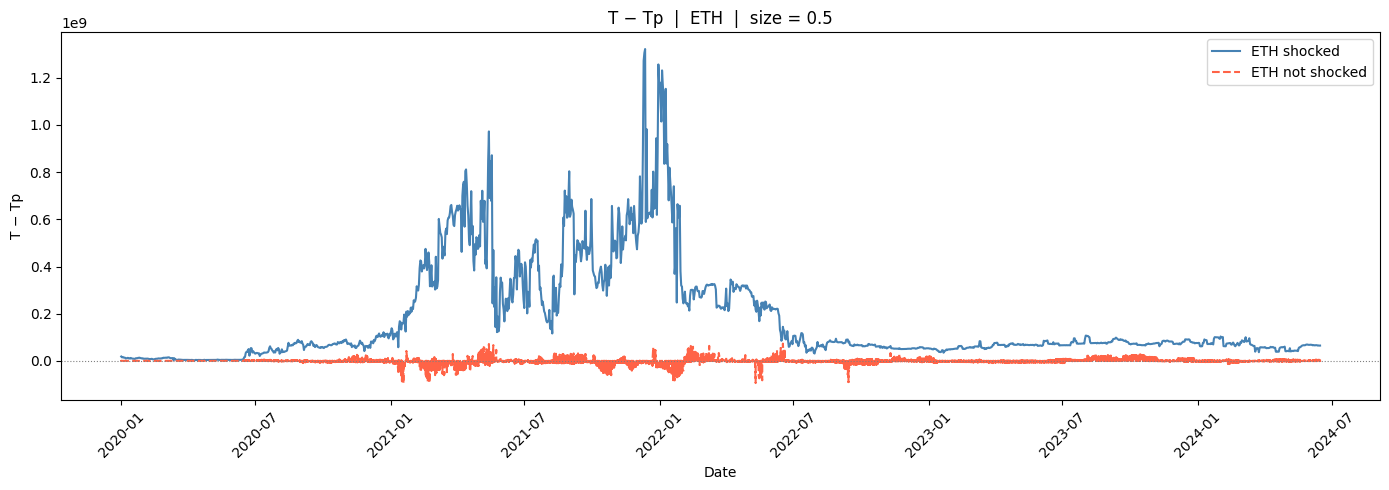

In [ ]:
# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE  = 0.5    # ← change size here
PLOT_ASSET = 'ETH'  # ← change asset here

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    lp['size'] == PLOT_SIZE
].copy()

# Shocked: pool is ETH and ETH is the shocked asset
df_shocked = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

# Not shocked: ETH is the pool asset but is NOT the shocked asset
df_notshocked = df_plot[
    (df_plot['shockAsset'] != PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_shocked['T_minus_Tp']    = df_shocked['T']    - df_shocked['Tp']
df_notshocked['T_minus_Tp'] = df_notshocked['T'] - df_notshocked['Tp']

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_shocked['date'],    df_shocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} shocked',     color='steelblue', linewidth=1.5)
ax.plot(df_notshocked['date'], df_notshocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} not shocked', color='tomato',    linewidth=1.5, linestyle='--')

ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)

ax.set_title(f'T − Tp  |  {PLOT_ASSET}  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

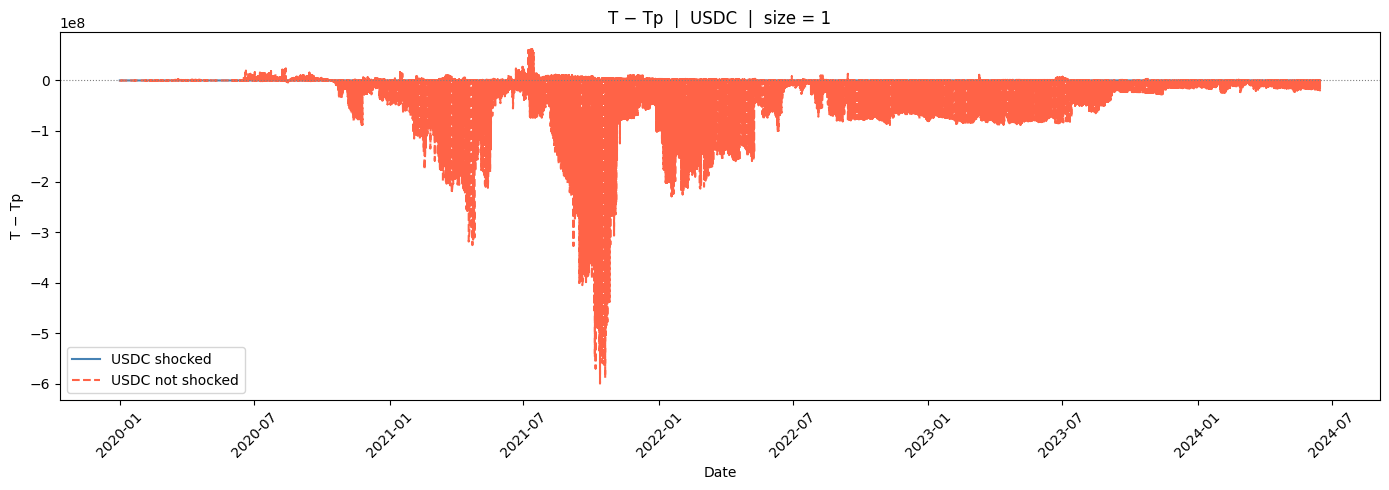

In [ ]:
# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE  = 1    # ← change size here
PLOT_ASSET = 'USDC'  # ← change asset here

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    lp['size'] == PLOT_SIZE
].copy()

# Shocked: pool is USDC and USDC is the shocked asset
df_shocked = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

# Not shocked: USDC is the pool asset but is NOT the shocked asset
df_notshocked = df_plot[
    (df_plot['shockAsset'] != PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_shocked['T_minus_Tp']    = df_shocked['T']    - df_shocked['Tp']
df_notshocked['T_minus_Tp'] = df_notshocked['T'] - df_notshocked['Tp']

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_shocked['date'],    df_shocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} shocked',     color='steelblue', linewidth=1.5)
ax.plot(df_notshocked['date'], df_notshocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} not shocked', color='tomato',    linewidth=1.5, linestyle='--')

ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)

ax.set_title(f'T − Tp  |  {PLOT_ASSET}  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

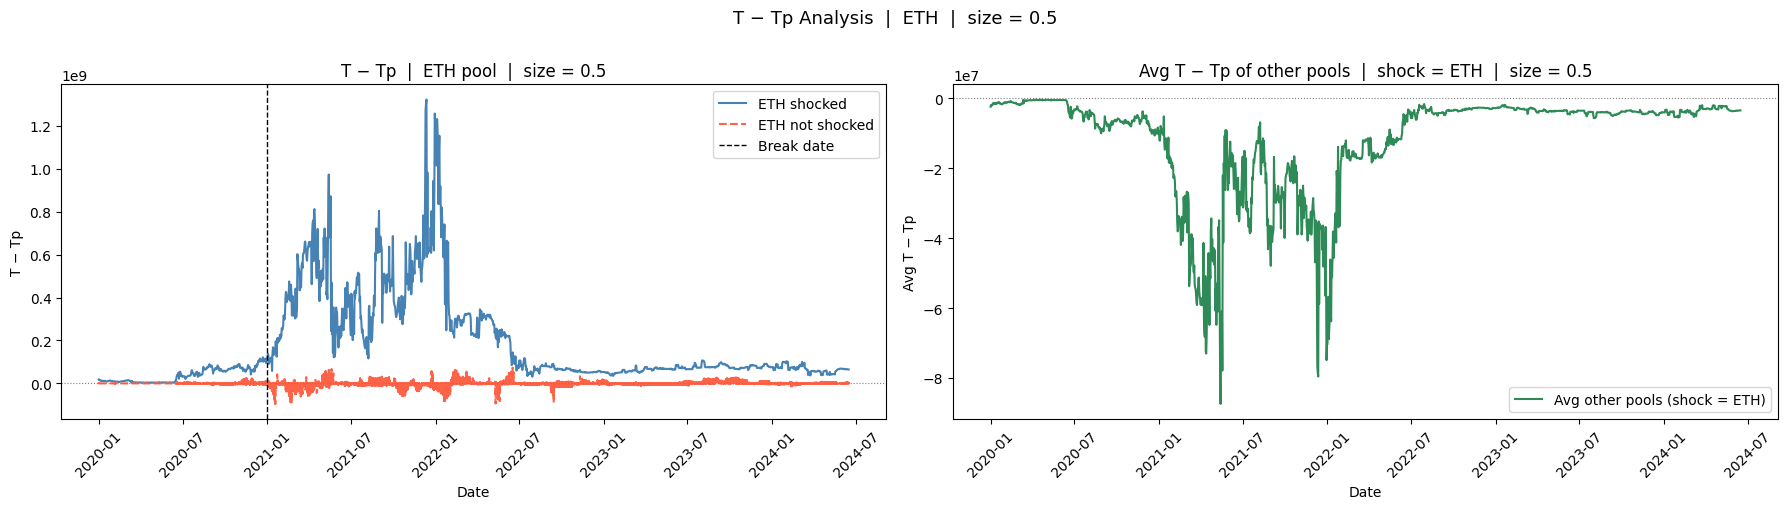

In [ ]:
import matplotlib.pyplot as plt

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE  = 0.5    # ← change size here
PLOT_ASSET = 'ETH'  # ← change asset here

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    lp['size'] == PLOT_SIZE
].copy()

# Graph 1: ETH pool — shocked vs not shocked
df_shocked = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_notshocked = df_plot[
    (df_plot['shockAsset'] != PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_shocked['T_minus_Tp']    = df_shocked['T']    - df_shocked['Tp']
df_notshocked['T_minus_Tp'] = df_notshocked['T'] - df_notshocked['Tp']

# Graph 2: average T-Tp of OtherAsset pools when PLOT_ASSET is the shockAsset
df_others = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] != PLOT_ASSET)
].copy()
df_others['T_minus_Tp'] = df_others['T'] - df_others['Tp']
df_others_avg = df_others.groupby('date')['T_minus_Tp'].mean().reset_index()

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: ETH shocked vs not shocked
ax = axes[0]
ax.plot(df_shocked['date'],    df_shocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} shocked',     color='steelblue', linewidth=1.5)
ax.plot(df_notshocked['date'], df_notshocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} not shocked', color='tomato',    linewidth=1.5, linestyle='--')
ax.axvline(break_date, color='black', linestyle='--', linewidth=1, label='Break date')
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
ax.set_title(f'T − Tp  |  {PLOT_ASSET} pool  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Right: average T-Tp of other pools when PLOT_ASSET is shocked
ax = axes[1]
ax.plot(df_others_avg['date'], df_others_avg['T_minus_Tp'],
        label=f'Avg other pools (shock = {PLOT_ASSET})', color='seagreen', linewidth=1.5)
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
ax.set_title(f'Avg T − Tp of other pools  |  shock = {PLOT_ASSET}  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('Avg T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'T − Tp Analysis  |  {PLOT_ASSET}  |  size = {PLOT_SIZE}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

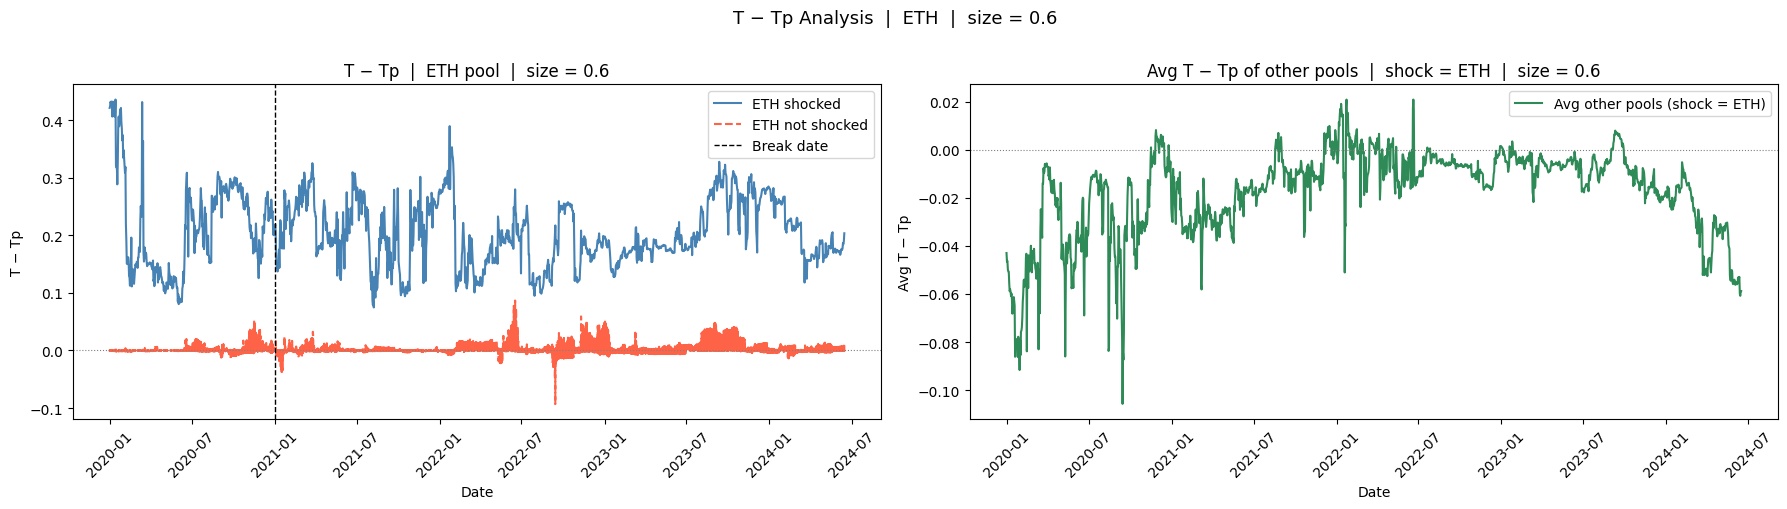

In [ ]:
import matplotlib.pyplot as plt

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE  = 0.6    # ← change size here
PLOT_ASSET = 'ETH'  # ← change asset here

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    lp['size'] == PLOT_SIZE
].copy()

# Graph 1: ETH pool — shocked vs not shocked
df_shocked = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_notshocked = df_plot[
    (df_plot['shockAsset'] != PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_shocked['T_minus_Tp']    = (df_shocked['T']    - df_shocked['Tp'])/(df_shocked['T'] + df_shocked['C'])
df_notshocked['T_minus_Tp'] = (df_notshocked['T'] - df_notshocked['Tp'])/(df_notshocked['T'] + df_notshocked['C'])

# Graph 2: average T-Tp of OtherAsset pools when PLOT_ASSET is the shockAsset
df_others = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] != PLOT_ASSET)
].copy()
df_others['T_minus_Tp'] = (df_others['T'] - df_others['Tp'])/(df_others['T'] + df_others['C'])
df_others_avg = df_others.groupby('date')['T_minus_Tp'].mean().reset_index()

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: ETH shocked vs not shocked
ax = axes[0]
ax.plot(df_shocked['date'],    df_shocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} shocked',     color='steelblue', linewidth=1.5)
ax.plot(df_notshocked['date'], df_notshocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} not shocked', color='tomato',    linewidth=1.5, linestyle='--')
ax.axvline(break_date, color='black', linestyle='--', linewidth=1, label='Break date')
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
ax.set_title(f'T − Tp  |  {PLOT_ASSET} pool  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Right: average T-Tp of other pools when PLOT_ASSET is shocked
ax = axes[1]
ax.plot(df_others_avg['date'], df_others_avg['T_minus_Tp'],
        label=f'Avg other pools (shock = {PLOT_ASSET})', color='seagreen', linewidth=1.5)
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
ax.set_title(f'Avg T − Tp of other pools  |  shock = {PLOT_ASSET}  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('Avg T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'T − Tp Analysis  |  {PLOT_ASSET}  |  size = {PLOT_SIZE}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

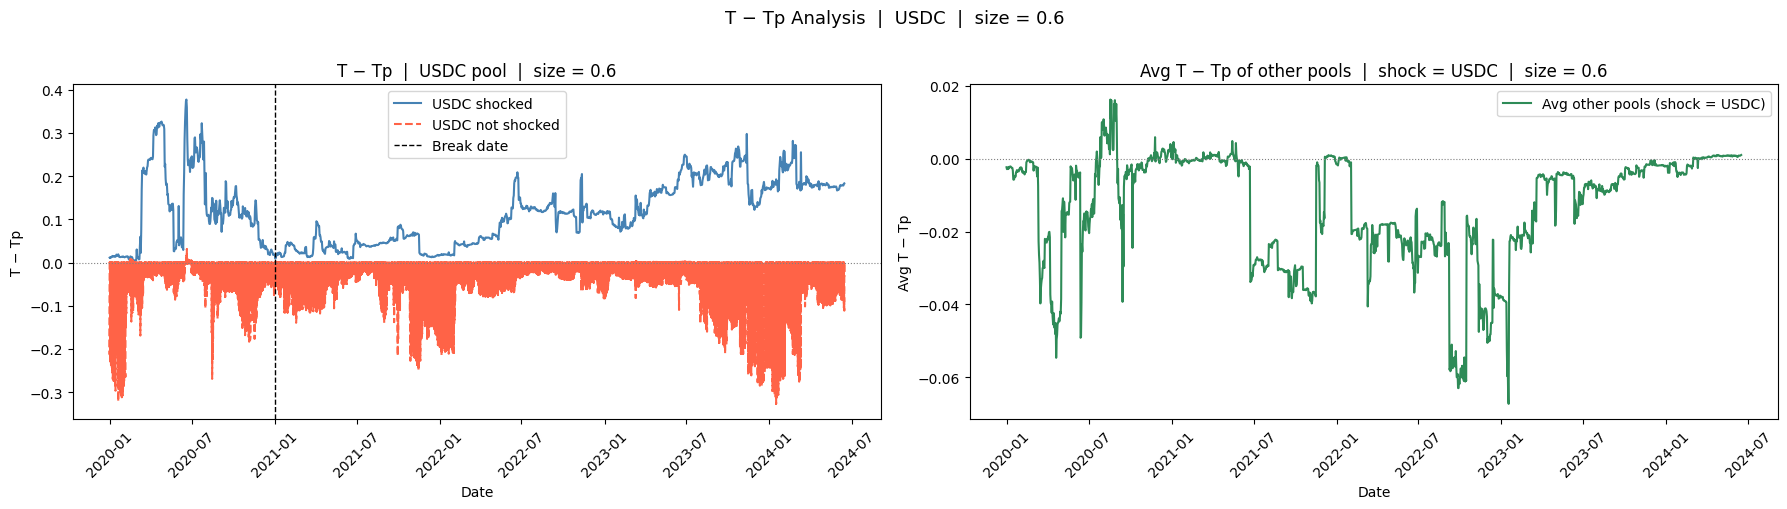

In [ ]:
import matplotlib.pyplot as plt

# ── Config ───────────────────────────────────────────────────────
PLOT_SIZE  = 0.6    # ← change size here
PLOT_ASSET = 'USDC'  # ← change asset here

# ── Filter ───────────────────────────────────────────────────────
df_plot = lp[
    lp['size'] == PLOT_SIZE
].copy()

# Graph 1: DAI pool — shocked vs not shocked
df_shocked = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_notshocked = df_plot[
    (df_plot['shockAsset'] != PLOT_ASSET) &
    (df_plot['otherAsset'] == PLOT_ASSET)
].sort_values('date')

df_shocked['T_minus_Tp']    = (df_shocked['T']    - df_shocked['Tp'])/(df_shocked['T'] + df_shocked['C'])
df_notshocked['T_minus_Tp'] = (df_notshocked['T'] - df_notshocked['Tp'])/(df_notshocked['T'] + df_notshocked['C'])

# Graph 2: average T-Tp of OtherAsset pools when PLOT_ASSET is the shockAsset
df_others = df_plot[
    (df_plot['shockAsset'] == PLOT_ASSET) &
    (df_plot['otherAsset'] != PLOT_ASSET)
].copy()
df_others['T_minus_Tp'] = (df_others['T'] - df_others['Tp'])/(df_others['T'] + df_others['C'])
df_others_avg = df_others.groupby('date')['T_minus_Tp'].mean().reset_index()

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: ETH shocked vs not shocked
ax = axes[0]
ax.plot(df_shocked['date'],    df_shocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} shocked',     color='steelblue', linewidth=1.5)
ax.plot(df_notshocked['date'], df_notshocked['T_minus_Tp'],
        label=f'{PLOT_ASSET} not shocked', color='tomato',    linewidth=1.5, linestyle='--')
ax.axvline(break_date, color='black', linestyle='--', linewidth=1, label='Break date')
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
ax.set_title(f'T − Tp  |  {PLOT_ASSET} pool  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Right: average T-Tp of other pools when PLOT_ASSET is shocked
ax = axes[1]
ax.plot(df_others_avg['date'], df_others_avg['T_minus_Tp'],
        label=f'Avg other pools (shock = {PLOT_ASSET})', color='seagreen', linewidth=1.5)
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
ax.set_title(f'Avg T − Tp of other pools  |  shock = {PLOT_ASSET}  |  size = {PLOT_SIZE}')
ax.set_xlabel('Date')
ax.set_ylabel('Avg T − Tp')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'T − Tp Analysis  |  {PLOT_ASSET}  |  size = {PLOT_SIZE}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3. Features' selection, Analysis of liquidation, Regressions 

### 3.1 Features' dictionary

In [ ]:
# Create dictionary of column groups for pool-level features

pool_cols = {
    'own': [
        'ext_assets', 'equity', 
        # 'selfBorrowUSD', 'pctSelfBorrow_x', 'self_borrow',
        'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity',
        'assets', 'log_assets', 'equity_share', 'extassets_share',
        'size_share',  'self_borrow_2',
        'log_out_weight', 'utilization_ratio', 'C_pool', 'D_pool', 'T_pool', 'E_pool', 'collateralFactor', 
         'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio' 
    ],
    'centrality': [
        'eigenvector', 'pagerank', 'hub', 'authority', 'core',
        'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding',
        'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled',
        'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled',
        'closeness_scaled', 'borrowing_scaled', 'funding_scaled',
        'density', 'reciprocity', 'biDensity', 'biAvgClustering', 'biAvgLatapyClustering'
    ],
    'aggregate': [
        'nPool', 'nUsers', 'nPureLenders', 'nBorrowers',
        'nPureLenders100', 'nBorrowers100',
        'nNewPureLenders', 'nNewBorrowers', 'nNewPureLenders100', 'nNewBorrowers100',
        'totDeposit', 'totPureLender', 'totCollateral', 'totBorrow', 'utilization',
        'totNewDeposit', 'totNewBorrow', 'newUtilization',
        'nDeposit', 'nBorrow', 'nDeposit100', 'nBorrow100',
        'nNewDeposit', 'nNewBorrow', 'nNewDeposit100', 'nNewBorrow100',
        'C', 'D', 'T', 'E', 'TD', 'total_assets'
    ],
    'cross_pool': [
        c for c in final.columns if c.startswith('pools_')
    ]
}

# Verify all columns exist in final
for group, cols in pool_cols.items():
    missing = [c for c in cols if c not in final.columns]
    if missing:
        print(f"[{group}] Missing: {missing}")
    else:
        print(f"[{group}] OK — {len(cols)} columns")


[own] Missing: ['log_assets', 'log_out_weight']
[centrality] OK — 27 columns
[aggregate] Missing: ['TD']
[cross_pool] OK — 72 columns


In [ ]:
users_cols = {
    'network': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio'])
    ],
    'financial': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['equity', 'health', 'pctSelfBorrow'])
    ]
}

for group, cols in users_cols.items():
    print(f"[{group}] {len(cols)} columns: {cols}")


[network] 54 columns: ['users_in_degree_mean', 'users_in_degree_std', 'users_in_degree_25%', 'users_in_degree_50%', 'users_in_degree_75%', 'users_in_degree_skew', 'users_in_degree_kurtosis', 'users_in_weight_mean', 'users_in_weight_std', 'users_in_weight_25%', 'users_in_weight_50%', 'users_in_weight_75%', 'users_in_weight_skew', 'users_in_weight_kurtosis', 'users_in_weight_hhi_mean', 'users_in_weight_hhi_std', 'users_in_weight_hhi_25%', 'users_in_weight_hhi_50%', 'users_in_weight_hhi_75%', 'users_in_weight_hhi_skew', 'users_in_weight_hhi_kurtosis', 'users_out_degree_mean', 'users_out_degree_std', 'users_out_degree_25%', 'users_out_degree_50%', 'users_out_degree_75%', 'users_out_degree_skew', 'users_out_degree_kurtosis', 'users_out_weight_mean', 'users_out_weight_std', 'users_out_weight_25%', 'users_out_weight_50%', 'users_out_weight_75%', 'users_out_weight_skew', 'users_out_weight_kurtosis', 'users_out_weight_hhi_mean', 'users_out_weight_hhi_std', 'users_out_weight_hhi_25%', 'users_out

In [ ]:
features = {                                                                                     
      'pool_own': pool_cols['own'],                                                                
      'pool_centrality': pool_cols['centrality'],                                                  
      'pool_aggregate': pool_cols['aggregate'],                                                    
      'pool_cross': pool_cols['cross_pool'],                                                       
      'users_network': users_cols['network'],                                                    
      'users_financial': users_cols['financial'],
      'outcome'        : ['log_B', 'share_B', 'log_share_B', 'share_T', 'delta_T', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'Cp_pool', 'Dp_pool',           
                            'Tp_pool', 'B_pool', 'Ep_pool', 'shareT_pool']                                                   
  }

In [ ]:
# Pool additions                                                                               
features['shock']    = ['date', 'year', 'month', 'shockAsset', 'size']   
                                                                                                   
# Collaterals & borrowers: split by topic                                                        
_financial_keys = ['depositUSD', 'borrowUSD', 'ext_assets', 'equity', 'selfBorrowUSD',           
                     'pctSelfBorrow', 'usedCollateralUSD', 'pctUsedCollateral', 'maxCollateralUSD',
                     'health', 'pctBorrow', 'pctDeposit', 'debtToCollateral',
                     'lenders100_hhiDeposit', 'borrowers100_hhiBorrow',
                     'borrowers100_health_mean', 'borrowers100_health_std',
                     'borrowers100_health_25%', 'borrowers100_health_50%', 'borrowers100_health_75%',
                     'borrowers100_health_wavg', 'borrowers100_health_skew', 'borrowers100_health_kurtosis',
                     'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
                      
_network_keys   = ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio']         
                                                                                                   
for prefix in ['collaterals', 'borrowers']:                                                    
      features['users_financial'] += [c for c in final.columns if c.startswith(f'{prefix}-')       
                                       and any(k in c for k in _financial_keys)]                   
      features['users_network']   += [c for c in final.columns if c.startswith(f'{prefix}-')
                                       and any(k in c for k in _network_keys)                      
                                       and c not in features['users_financial']]                 
                                                                                                   
features['users_financial'] += ['log_borrowers-equity-wavg',                                     
                                   'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
features['users_network']   += ['log_collaterals-in_weight-sum', 'log_collaterals-equity-wavg',  
                                   'log_collaterals-out_weight-wavg',                              
                                  'log_collaterals-out_degree-wavg',
                                   'log_borrowers-out_weight-wavg']                                
                                                                                                   
# Clean pool groups: remove misplaced columns
_exclude = ['borrowers-', 'collaterals-', 'users_hhiDeposit', 'users_hhiBorrow',                 
              'users_hhiEquity']                                                                               
for key in ['pool_own', 'pool_aggregate', 'pool_centrality', 'pool_cross']:
      features[key] = [c for c in features[key]                                                    
                       if not any(c.startswith(e) if e.endswith('-') else c == e for e in          
                          _exclude)]                                                                                       
                                                                                                   
# Deduplicate all groups                                                                         
features = {k: list(dict.fromkeys(v)) for k, v in features.items()}

# Remove features ending with 'USD' from all feature lists
                                                                                                                                                                                               
def drop_usd(lst):                                                                   
      return [f for f in lst if 'USD' not in f]                                                                                                                                      
                                                                                                                                                                                                                                                                                                                                                                                           
# Fix features dict (cell 59) — needs explicit update since it's a separate reference                                                                                                        
features['pool_own'] = drop_usd(features['pool_own'])                                                                                                                                        
features['users_financial'] = drop_usd(features['users_financial'])   

# Fix _financial_keys (cell 60)                                                                                                                                                              
_financial_keys = drop_usd(_financial_keys)                                                                                                                                                  
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for k, v in features.items():                                                        
      remaining = [f for f in v if 'USD' in f]                                         
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")                                       
print("Done — no output above means all USD features removed.")   

def drop_100(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('100')]                                                                                                                                         
                                                                                                                                                                                                                                                                                                                                                                                     
# Fix features dict (cell 59) — explicit update needed                                                                                                                                       
features['pool_aggregate'] = drop_100(features['pool_aggregate'])                                                                                                                            
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
print("100-ending remaining in features['pool_aggregate']:", [f for f in features['pool_aggregate'] if f.endswith('100')])  

# Remove features ending with '%' from all feature lists                                                                                                                                     
                                                                                                                                                                                               
def drop_pct(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('%')]                                                                                                                                           
                                                                                                                                                                                               
_financial_keys              = drop_pct(_financial_keys)                                                                                                                                     
features['users_financial']  = drop_pct(features['users_financial'])                                                                                                                         
features['pool_cross']       = drop_pct(features['pool_cross'])                                                                                                                              
features['users_network']    = drop_pct(features['users_network'])                                                                                                                           
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for name, lst in [('_financial_keys', _financial_keys),                                                                                                                                      
                    ('users_financial', features['users_financial']),                                                                                                                          
                    ('pool_cross',      features['pool_cross']),                                                                                                                               
                    ('users_network',   features['users_network'])]:                                                                                                                           
      remaining = [f for f in lst if f.endswith('%')]                                                                                                                                          
      print(f"%-ending remaining in {name}: {remaining or 'None'}") 

# Remove features starting with 'log_' from all feature lists                                                                                                                                
                                                                                                                                                                                               
def drop_log(lst):                                                                                                                                                                           
      return [f for f in lst if not f.startswith('log_')]  
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
# Cell 59/60 — features dict (all groups including users_network)
for key in features:
      features[key] = drop_log(features[key])

# Verification
for k, v in features.items():
      remaining = [f for f in v if f.startswith('log_')]
      if remaining:
          print(f"log_ remaining in features['{k}']: {remaining}")
print("Done")    

# Remove features ending with 'sum' from all lists                                                                                                          
def drop_sum(lst):                                                                   
      return [f for f in lst if not f.endswith('sum')]
                                                                                       
for key in features:                                                                 
      features[key] = drop_sum(features[key])                                          
                                                                                       
# Verification                                                                       
for k, v in features.items():                                                        
      remaining = [f for f in v if f.endswith('sum')]                                  
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")
print("Done — no output above means all -sum features removed.")

# Split features['users_network'] into two groups
features['collaterals_network'] = [f for f in features['users_network'] if           
f.startswith('collaterals')]
features['users_network']       = [f for f in features['users_network'] if not       
f.startswith('collaterals')]                                                         
  
                                                       
# Split features['users_financial'] into two groups                                  
features['collaterals_financial'] = [f for f in features['users_financial'] if
  f.startswith('collaterals')]                                                         
features['users_financial']       = [f for f in features['users_financial'] if not
  f.startswith('collaterals')]                                                         
                  
# Verification                                                                       
for key in ['collaterals_network', 'users_network', 'collaterals_financial',
  'users_financial']:                                                                  
      print(f"{key} ({len(features[key])}):", features[key])

# Verify
all_captured = [c for cols in features.values() for c in cols]                                   
print(f"Duplicates: {[c for c in all_captured if all_captured.count(c) > 1] or 'None'}")
print(f"Not selected ({sum(c not in all_captured for c in final.columns)}): "
        f"{[c for c in final.columns if c not in all_captured]}")   

Done — no output above means all USD features removed.
100-ending remaining in features['pool_aggregate']: []
%-ending remaining in _financial_keys: None
%-ending remaining in users_financial: None
%-ending remaining in pool_cross: None
%-ending remaining in users_network: None
Done
Done — no output above means all -sum features removed.
collaterals_network (23): ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-in_degree-median', 'collaterals-in_weight-median', 'collaterals-in_weight_hhi-median', 'collaterals-out_degree-median', 'collaterals-out_weight-median', 'collaterals-out_weight_hhi-median', 'collaterals-in_out_ratio-median', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degr

In [ ]:
# Features per group

for group, cols in features.items():                                                             
    print(f"[{group}] {len(cols)} columns")

[pool_own] 24 columns
[pool_centrality] 27 columns
[pool_aggregate] 24 columns
[pool_cross] 45 columns
[users_network] 56 columns
[users_financial] 38 columns
[outcome] 14 columns
[shock] 5 columns
[collaterals_network] 23 columns
[collaterals_financial] 21 columns


### 3.2 Features' selection for regressions

In [ ]:
# Backup features dict before further modifications
import copy                                                                                 
features_backup = copy.deepcopy(features) 

In [ ]:
features['pool_own']              = ['pctUsedCollateral', 'self_borrow_2', 
                                    'utilization_ratio', 'collateralFactor', 
                                    'in_degree','in_weight_hhi', 'out_degree', 
                                    'out_weight_hhi' ] 

features['pool_centrality']       = ['pagerank', 'pagerank_scaled', 'hub', 'hub_scaled']

features['pool_cross']            = ['pools_hhiDeposit', 'pools_hhiBorrow', 'pools_in_degree_std', 
                                    'pools_out_degree_std', 'pools_pctSelfBorrow_std', 
                                    'pools_out_degree_wavg','pools_in_degree_wavg','pools_pctSelfBorrow_wavg']

features['collaterals_network']   = ['collaterals-in_degree-wavg',
                                    'collaterals-in_weight-wavg',
                                    'collaterals-in_weight_hhi-wavg',
                                    'collaterals-out_degree-wavg',
                                    'collaterals-out_weight-wavg',
                                    'collaterals-out_weight_hhi-wavg']

features['collaterals_financial'] = ['collaterals-pctSelfBorrow-wavg',
                                    'collaterals-pctUsedCollateral-wavg',
                                    'collaterals-health-wavg',
                                    'collaterals-pctDeposit-wavg']


### 3.3 Regressions - ETH & WBTC - Liquidation

In [ ]:
# ── Config ───────────────────────────────────────────────────────
CRYPTO_ASSETS      = ['ETH','WBTC']
CRYPTO_BREAK_REF_SIZE = 0.5

# ── Reference sample & column definitions ────────────────────────
subset_crypto_ref = final[
    (final['size'] == CRYPTO_BREAK_REF_SIZE) &
    (final['shockAsset'].isin(CRYPTO_ASSETS))
].copy().sort_values('date')

regr_postbreak = final[
    (final['date'] >= break_date) &
    (final['size'] == CRYPTO_BREAK_REF_SIZE) &   # ← == not >=
    (final['shockAsset'].isin(CRYPTO_ASSETS))
].copy()


In [ ]:
## Estimate LASSO with Rolling Cross-Validation Fit LASSO across a grid of penalty values λ using a rolling window cross-validation scheme that respects the time series ordering. 
# At each fold, train on the past and validate on the next period. Use the λ1se rule — the largest λ whose error is within one standard error of the minimum — to favor sparser and more 
# robust models.
## Identify Selected Variables Record which predictors have nonzero coefficients at the chosen λ. With a short time series, be conservative: if the selected model still contains 
# many predictors relative to sample size, increase λ further.

In [ ]:
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════
# Config
# ══════════════════════════════════════════════════════════════════
ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200
ADF_PVAL         = 0.05


### 3.3.1 Regression & Predictions on pool ETH-WBTC - No asset fixed effects

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 1: Build X and y
# ══════════════════════════════════════════════════════════════════

GROUPS_flat = ['pool_own','pool_cross','pool_centrality','collaterals_network','collaterals_financial']

theory_vars_flat = [v for group in GROUPS_flat for v in features[group]] 

available = [v for v in theory_vars_flat if v in regr_postbreak.columns]
missing   = [v for v in theory_vars_flat if v not in regr_postbreak.columns]
if missing:
    print(f"\n*** Missing from regr_postbreak: {missing}")

X_th  = regr_postbreak[available].copy()
y_th  = regr_postbreak['shareT_pool'].copy()
#fe_th = regr_postbreak['asset_fe'].copy()
dt_th = regr_postbreak['date'].copy()

# drop rows with any NaN
row_mask = X_th.notna().all(axis=1) & y_th.notna()
X_th     = X_th.loc[row_mask]
y_th     = y_th.loc[row_mask]
#fe_th    = fe_th.loc[row_mask]
dt_th    = dt_th.loc[row_mask]

# drop constant columns
X_th     = X_th.loc[:, X_th.std() > 0]
available = list(X_th.columns)

print(f"\nClean sample: N={len(y_th)}  "
      f"Predictors={X_th.shape[1]}")
print(f"Variables: {available}")



Clean sample: N=2524  Predictors=30
Variables: ['pctUsedCollateral', 'self_borrow_2', 'utilization_ratio', 'collateralFactor', 'in_degree', 'in_weight_hhi', 'out_degree', 'out_weight_hhi', 'pools_hhiDeposit', 'pools_hhiBorrow', 'pools_in_degree_std', 'pools_out_degree_std', 'pools_pctSelfBorrow_std', 'pools_out_degree_wavg', 'pools_in_degree_wavg', 'pools_pctSelfBorrow_wavg', 'pagerank', 'pagerank_scaled', 'hub', 'hub_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-out_weight-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg', 'collaterals-pctUsedCollateral-wavg', 'collaterals-health-wavg', 'collaterals-pctDeposit-wavg']


In [ ]:
                                                                                              
# ══════════════════════════════════════════════════════════════════                        
# Step 2: Train/test split — chronological
# ══════════════════════════════════════════════════════════════════                        
mask     = dt_th >= break_date                                                              
X_th_br  = X_th[mask]                                                                       
y_th_br  = y_th[mask]
dt_th_br = dt_th[mask]


# ── Trim full sample to final date ───────────────────────────────                         
TEST_END_DATE = '2023-10-01'
end_mask = dt_th_br.values <= pd.Timestamp(TEST_END_DATE)                                   
X_th_br  = X_th_br[end_mask]                                                                
y_th_br  = y_th_br[end_mask]                                                                
dt_th_br = dt_th_br[end_mask]                                                               
                                                                                              
# ── Train/test split — chronological 80/20 ───────────────────────                         
n_total  = len(y_th_br)                                                                     
n_test   = int(n_total * TEST_SIZE)                                                         
n_train  = n_total - n_test

X_tr_raw = X_th_br.iloc[:n_train]                                                           
X_te_raw = X_th_br.iloc[n_train:]
y_tr     = y_th_br.iloc[:n_train]                                                           
y_te     = y_th_br.iloc[n_train:]
dates_tr = dt_th_br.iloc[:n_train]                                                          
dates_te = dt_th_br.iloc[n_train:]
                                                                                              
print(f"\nTrain: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")           
print(f"Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")
                                                                 
# ══════════════════════════════════════════════════════════════════
# Step 3: Scale on train only
# ══════════════════════════════════════════════════════════════════
scaler_th = StandardScaler()
X_tr_sc   = pd.DataFrame(
    scaler_th.fit_transform(X_tr_raw),
    columns=available, index=X_tr_raw.index
)
X_te_sc   = pd.DataFrame(
    scaler_th.transform(X_te_raw),
    columns=available, index=X_te_raw.index
)


Train: N=1607  2021-01-01 → 2023-03-15
Test:  N=401   2023-03-15 → 2023-10-01


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 4: OLS — full theory specification
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 4: OLS ETH - all features")
print(f"{'='*65}")

X_tr_ols             = X_tr_sc.copy()
# X_tr_ols['asset_fe'] = fe_tr.values
X_tr_const           = sm.add_constant(X_tr_ols)

model_hc3 = sm.OLS(y_tr, X_tr_const).fit(cov_type='HC3')
model_hac = sm.OLS(y_tr, X_tr_const).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)

dw = sm.stats.stattools.durbin_watson(model_hc3.resid)

print(f"\n  N={n_train}  "
      f"R²={model_hc3.rsquared:.4f}  "
      f"Adj.R²={model_hc3.rsquared_adj:.4f}  "
      f"DW={dw:.3f}")

print(f"\n  {'Variable':<45} {'coef':>8} "
      f"{'HC3-p':>8} {'HAC-p':>8}  ")
print(f"  {'-'*90}")

for var in X_tr_const.columns:
    coef   = model_hac.params[var]
    hc3_p  = model_hc3.pvalues[var]
    hac_p  = model_hac.pvalues[var]
    sig    = '✓' if hac_p < ALPHA else 'n.s.'
    actual = '+' if coef > 0 else '-'
    print(f"  {var:<45} {coef:>8.4f} "
          f"{hc3_p:>8.4f} {hac_p:>8.4f}  ")

print(f"\n  DW={dw:.3f} → "
      f"{'autocorrelation — prefer HAC' if dw < 1.5 else 'no strong autocorrelation'}")
print("\n  Full HAC summary:")
print(model_hac.summary())



  Step 4: OLS ETH - all features

  N=1607  R²=0.8138  Adj.R²=0.8103  DW=2.153

  Variable                                          coef    HC3-p    HAC-p  
  ------------------------------------------------------------------------------------------
  const                                          -0.1037   0.0000   0.0000  
  pctUsedCollateral                              -0.0287   0.0000   0.0000  
  self_borrow_2                                   0.0113   0.0000   0.0000  
  utilization_ratio                              -0.0000   0.9642   0.9732  
  collateralFactor                                0.0013   0.6415   0.7114  
  in_degree                                      -0.0994   0.0318   0.1292  
  in_weight_hhi                                   0.0006   0.3636   0.4745  
  out_degree                                      0.0286   0.0000   0.0000  
  out_weight_hhi                                  0.0070   0.0000   0.0000  
  pools_hhiDeposit                               -0.0036

/Users/Stefania/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 5: Incremental R² by mechanism
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 5: Incremental R² by mechanism")
print(f"{'='*65}")

print(f"\n  {'Model':<55} {'R²':>8} {'ΔR²':>8}")
print(f"  {'-'*75}")

#X_base   = sm.add_constant(
#    pd.DataFrame({'asset_fe': fe_tr.values},
#                 index=X_tr_raw.index)
#)
#r2_base  = sm.OLS(y_tr, X_base).fit().rsquared
#print(f"  {'Baseline (asset_fe only)':<55} "
#      f"{r2_base:>8.4f} {'—':>8}")
#r2_prev  = r2_base

r2_prev  = 0                                                                                
cum_vars = []
for group in GROUPS_flat:                                                                 
      avail_m = [v for v in features[group] if v in available]
      if not avail_m:                                                                         
          continue
      cum_vars += avail_m                                                                     
      r2_cum = sm.OLS(                                                                      
          y_tr, sm.add_constant(X_tr_sc[cum_vars])
      ).fit().rsquared                                                                        
      delta  = r2_cum - r2_prev
      print(f"  {'+ ' + group:<55} {r2_cum:>8.4f} {delta:>+8.4f}")                            
      r2_prev = r2_cum                                                                        
  
print(f"  {'Full theory model':<55} {model_hac.rsquared:>8.4f}")     


  Step 5: Incremental R² by mechanism

  Model                                                         R²      ΔR²
  ---------------------------------------------------------------------------
  + pool_own                                                0.5544  +0.5544
  + pool_cross                                              0.6463  +0.0919
  + pool_centrality                                         0.7518  +0.1055
  + collaterals_network                                     0.8092  +0.0574
  + collaterals_financial                                   0.8138  +0.0046
  Full theory model                                         0.8138


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 6: Out-of-sample validation
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 6: Out-of-sample validation")
print(f"{'='*65}")

X_te_ols             = X_te_sc.copy()
#X_te_ols['asset_fe'] = fe_te.values
y_pred_te = model_hac.predict(
    sm.add_constant(X_te_ols, has_constant='add')
)

res_te  = y_te - y_pred_te
r2_te   = 1 - (res_te**2).sum() / \
          ((y_te - y_te.mean())**2).sum()
rmse_te = np.sqrt((res_te**2).mean())
mae_te  = res_te.abs().mean()

print(f"\n  {'':20} {'R²':>8} {'RMSE':>12} {'MAE':>12}")
print(f"  {'-'*55}")
print(f"  {'Train':<20} {model_hac.rsquared:>8.4f} "
      f"{np.sqrt((model_hac.resid**2).mean()):>12.6f} "
      f"{model_hac.resid.abs().mean():>12.6f}")
print(f"  {'Test':<20} {r2_te:>8.4f} "
      f"{rmse_te:>12.6f} {mae_te:>12.6f}")
print(f"  {'R² gap':<20} "
      f"{model_hac.rsquared - r2_te:>8.4f}")

if model_hac.rsquared - r2_te > 0.10:
    print("  *** Substantial degradation")
elif model_hac.rsquared - r2_te > 0.05:
    print("  Moderate degradation")
else:
    print("  Minimal degradation — model generalises well")


  Step 6: Out-of-sample validation

                             R²         RMSE          MAE
  -------------------------------------------------------
  Train                  0.8138     0.019646     0.015138
  Test                   0.7566     0.027898     0.022357
  R² gap                 0.0572
  Moderate degradation


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 8: LASSO as robustness check
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 8: LASSO robustness check")
print(f"  Do theory vars survive data-driven selection?")
print(f"{'='*65}")

tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
lasso_cv = LassoCV(
    cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
    max_iter=10000, random_state=42
)
lasso_cv.fit(X_tr_sc, y_tr)

lambdas    = lasso_cv.alphas_
mse_path   = lasso_cv.mse_path_
mean_mse   = mse_path.mean(axis=1)
std_mse    = mse_path.std(axis=1) / np.sqrt(N_SPLITS)
lam_min    = lasso_cv.alpha_
min_idx    = np.argmin(mean_mse)
threshold  = mean_mse[min_idx] + std_mse[min_idx]
within_1se = np.where(mean_mse <= threshold)[0]
lam_1se    = lambdas[within_1se[0]]

coefs_min  = pd.Series(lasso_cv.coef_, index=available)
coefs_1se  = pd.Series(
    Lasso(alpha=lam_1se, max_iter=10000).fit(
        X_tr_sc, y_tr).coef_,
    index=available
)

print(f"\n  λ_min={lam_min:.6f}  "
      f"({(coefs_min != 0).sum()} vars)")
print(f"  λ_1se={lam_1se:.6f}  "
      f"({(coefs_1se != 0).sum()} vars)")

print(f"\n  {'Variable':<45} {'λ_1se':>6} {'λ_min':>6}  "
      f"{'coef@min':>10}  Mechanism")
print(f"  {'-'*85}")
for group in GROUPS_flat:                                                                                    
      for var in features[group]:                                                                              
          if var not in available:                                                                             
              print(f"  {'MISSING: '+var:<45} {'—':>6} {'—':>6}  {'—':>10}  {group}")                          
              continue
          s_1se = '✓' if coefs_1se[var] != 0 else '✗'                                                          
          s_min = '✓' if coefs_min[var] != 0 else '✗'                                                          
          print(f"  {var:<45} {s_1se:>6} {s_min:>6}  {coefs_min[var]:>10.4f}  {group}")


  Step 8: LASSO robustness check
  Do theory vars survive data-driven selection?

  λ_min=0.001185  (17 vars)
  λ_1se=0.002544  (13 vars)

  Variable                                       λ_1se  λ_min    coef@min  Mechanism
  -------------------------------------------------------------------------------------
  pctUsedCollateral                                  ✓      ✓     -0.0238  pool_own
  self_borrow_2                                      ✓      ✓      0.0060  pool_own
  utilization_ratio                                  ✓      ✓     -0.0035  pool_own
  collateralFactor                                   ✗      ✗     -0.0000  pool_own
  in_degree                                          ✗      ✗     -0.0000  pool_own
  in_weight_hhi                                      ✗      ✗     -0.0000  pool_own
  out_degree                                         ✗      ✗     -0.0000  pool_own
  out_weight_hhi                                     ✓      ✓      0.0064  pool_own
  pools_hhiDepo

### 3.3.2 Regression & Predictions on pool ETH-WBTC - No asset fixed effects - Selected features ONLY


  Step 9: Model comparison

  Model                                          Train R²   Test R²       RMSE  Vars
  --------------------------------------------------------------------------------
  Theory model (all vars)                          0.8138    0.7566   0.027898    30
  LASSO λ_min (17 vars)                            0.7634    0.8112   0.024567    17


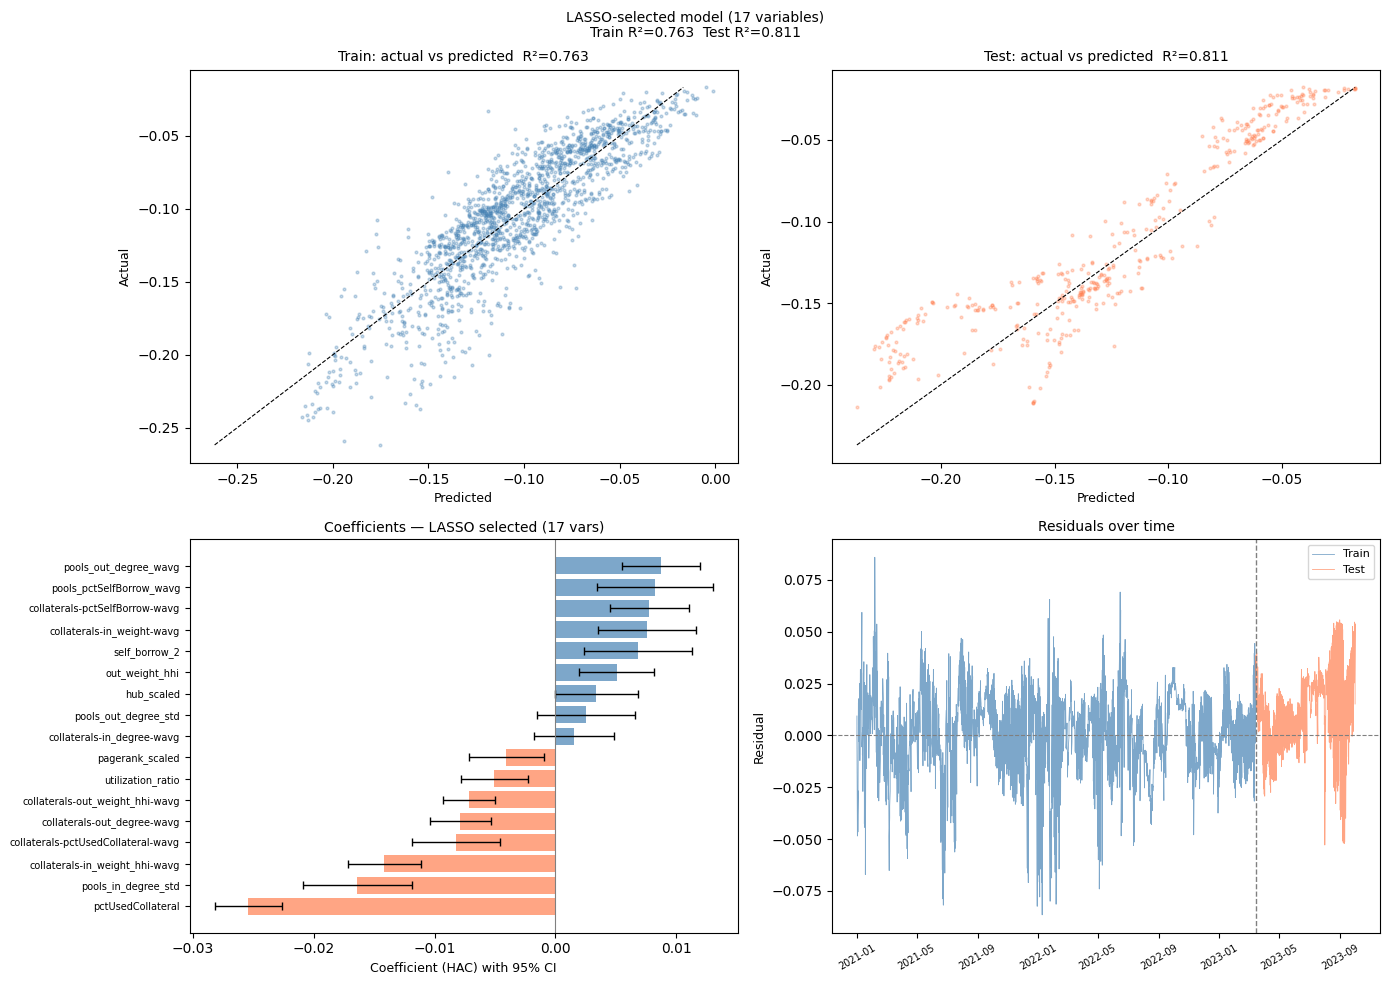

Saved to lasso_selected_model.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════                        
# Step 9: Model comparison summary — LASSO selected vars                                    
# ══════════════════════════════════════════════════════════════════                        
selected_min = coefs_min[coefs_min != 0].index.tolist()                                     
selected_1se = coefs_1se[coefs_1se != 0].index.tolist()                                     
                                                                                              
# Refit OLS on LASSO-selected variables                                                     
X_tr_lasso = sm.add_constant(X_tr_sc[selected_min])
model_lasso = sm.OLS(y_tr, X_tr_lasso).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})                                                                               
                                                                                              
X_te_lasso  = sm.add_constant(X_te_sc[selected_min], has_constant='add')                    
y_pred_lasso = model_lasso.predict(X_te_lasso)
res_lasso    = y_te - y_pred_lasso                                                          
r2_lasso     = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()                   
rmse_lasso   = np.sqrt((res_lasso**2).mean())                                               
                                                                                              
print(f"\n{'='*65}")                                                                        
print(f"  Step 9: Model comparison")                                                        
print(f"{'='*65}")
print(f"\n  {'Model':<45} {'Train R²':>9} {'Test R²':>9} {'RMSE':>10} {'Vars':>5}")
print(f"  {'-'*80}")                                                                        
for label, r2_tr, r2_te_, rmse_, nvars in [
    ('Theory model (all vars)', model_hac.rsquared, r2_te, rmse_te, len(available)),        
    (f'LASSO λ_min ({len(selected_min)} vars)', model_lasso.rsquared, r2_lasso, rmse_lasso, 
  len(selected_min)),                                                                         
  ]:                                                                                          
    print(f"  {label:<45} {r2_tr:>9.4f} {r2_te_:>9.4f} {rmse_:>10.6f} {nvars:>5}")          
                                                                                              
# ══════════════════════════════════════════════════════════════════
# Step 10: Diagnostic plots — LASSO model                                                   
# ══════════════════════════════════════════════════════════════════                        
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                                                                                              
# actual vs predicted — train                                                               
ax = axes[0, 0]
ax.scatter(model_lasso.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')               
lims = [y_tr.min(), y_tr.max()]                                                             
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Train: actual vs predicted  R²={model_lasso.rsquared:.3f}', fontsize=10)     
                                                                                              
# actual vs predicted — test                                                                
ax = axes[0, 1]                                                                             
ax.scatter(y_pred_lasso, y_te, s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_lasso.min()), max(y_te.max(), y_pred_lasso.max())]           
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Test: actual vs predicted  R²={r2_lasso:.3f}', fontsize=10)                  
                  
# coefficients with CI                                                                      
ax = axes[1, 0] 
params = model_lasso.params.drop('const')                                                   
ci     = model_lasso.conf_int().drop('const')
order  = params.sort_values().index                                                         
y_pos  = range(len(order))                                                                  
ax.barh(y_pos, params[order], color=['coral' if v < 0 else 'steelblue' for v in             
params[order]], alpha=0.7)                                                                  
ax.errorbar(params[order], y_pos,
              xerr=[params[order] - ci.loc[order, 0], ci.loc[order, 1] - params[order]],      
              fmt='none', color='black', capsize=3, lw=1)                                     
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=7)                                 
ax.axvline(0, color='gray', lw=0.8)                                                         
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)                                  
ax.set_title(f'Coefficients — LASSO selected ({len(selected_min)} vars)', fontsize=10)      
                                                                                              
# residuals over time                                                                       
ax = axes[1, 1]                                                                             
ax.plot(dates_tr, model_lasso.resid.values, color='steelblue', lw=0.6, alpha=0.7, label='Train')                                                                              
ax.plot(dates_te, res_lasso.values,         color='coral',     lw=0.6, alpha=0.7, label='Test')                                                                               
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)                                     
ax.set_ylabel('Residual', fontsize=9)                                                       
ax.set_title('Residuals over time', fontsize=10)
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30, labelsize=7)                   
                  
fig.suptitle(f'LASSO-selected model ({len(selected_min)} variables)\n'                      
               f'Train R²={model_lasso.rsquared:.3f}  Test R²={r2_lasso:.3f}', fontsize=10)
plt.tight_layout()                                                                          
plt.savefig('lasso_selected_model.pdf', bbox_inches='tight', dpi=150)
plt.show()                                                                                  
print("Saved to lasso_selected_model.pdf")

### Check why 'collateralFactor', 'collaterals-health-wavg' are not included

In [ ]:
# ── Diagnostic: why was a feature not selected? ──────────────────           
# - collateralFactor — never enters even at very low alpha. Reason: it's almost 
#  perfectly collinear with pagerank_scaled (r=0.934). LASSO absorbs all its
#  signal through pagerank_scaled and never needs it.                            
#  - collaterals-health-wavg — enters only at α=0.0001, which is very small.   
#  Reason: highly correlated with collaterals-pctUsedCollateral-wavg (r=-0.780). 
#  Most of its signal is captured by that variable. It only adds marginal
#  information at very low penalty.   
      
INSPECT = ['collateralFactor', 'collaterals-health-wavg']  # ← your important features     
                                                                                
print(f"\n{'='*65}")                                                          
print(f"  LASSO exclusion diagnostic")                                        
print(f"{'='*65}")                                                            
                                                                              
for var in INSPECT:                                                           
    if var not in available:                                                
          print(f"\n{var}: NOT IN DATASET")                                   
          continue                                                              
   
    print(f"\n── {var} ──")                                                   
                                                                              
    # 1. Correlation with outcome                                             
    r_y = X_tr_sc[var].corr(y_tr)                                           
    print(f"  Corr with y:        {r_y:+.4f}")                                
   
    # 2. Correlation with selected features                                   
    print(f"  Corr with selected features:")                                
    for sel in selected_min:                                                  
        r = X_tr_sc[var].corr(X_tr_sc[sel])                                   
        if abs(r) > 0.3:                                                    
            print(f"    {sel:<45} {r:+.3f}")                                  
                                                                                
    # 3. Coefficient path as alpha decreases                                
    print(f"  Coef at different alphas:")                                     
    for alpha in [0.01, 0.005, 0.001, 0.0005, 0.0001]:                        
        coefs = pd.Series(                                                    
            Lasso(alpha=alpha, max_iter=10000).fit(X_tr_sc, y_tr).coef_,      
              index=X_tr_sc.columns                                                  
          )                                                                   
        status = '✓ selected' if coefs[var] != 0 else '✗ zeroed'              
print(f"    α={alpha:.4f}  coef={coefs[var]:+.6f}  {status}")  


  LASSO exclusion diagnostic

── collateralFactor ──
  Corr with y:        -0.2916
  Corr with selected features:
    pctUsedCollateral                             +0.302
    self_borrow_2                                 -0.355
    pools_in_degree_std                           -0.313
    pools_out_degree_std                          -0.353
    pagerank_scaled                               +0.934
    hub_scaled                                    +0.303
    collaterals-out_degree-wavg                   -0.357
    collaterals-out_weight_hhi-wavg               +0.348
    collaterals-pctUsedCollateral-wavg            +0.395
  Coef at different alphas:

── collaterals-health-wavg ──
  Corr with y:        +0.4662
  Corr with selected features:
    pctUsedCollateral                             -0.597
    collaterals-pctSelfBorrow-wavg                -0.340
    collaterals-pctUsedCollateral-wavg            -0.780
  Coef at different alphas:
    α=0.0001  coef=-0.003291  ✓ selected


### Include 'collateralFactor', 'collaterals-health-wavg' and exclude 'pagerank_scaled' and 'collaterals-pctUsedCollateral-wavg'

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 8: LASSO as robustness check
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 8: LASSO robustness check")
print(f"  Do theory vars survive data-driven selection?")
print(f"{'='*65}")

# ── swap proxies for theory-preferred variables before LASSO sees them       
swap_out = ['pagerank_scaled', 'collaterals-pctUsedCollateral-wavg']          
swap_in  = ['collateralFactor', 'collaterals-health-wavg']              
exclude = set(swap_out) | set(swap_in)
available_lasso = [v for v in list(available) if v not in exclude] + swap_in    
  
X_tr_lasso = X_tr_sc[available_lasso]  

tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
lasso_cv = LassoCV(
    cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
    max_iter=10000, random_state=42
)
lasso_cv.fit(X_tr_lasso, y_tr)

lambdas    = lasso_cv.alphas_
mse_path   = lasso_cv.mse_path_
mean_mse   = mse_path.mean(axis=1)
std_mse    = mse_path.std(axis=1) / np.sqrt(N_SPLITS)
lam_min    = lasso_cv.alpha_
min_idx    = np.argmin(mean_mse)
threshold  = mean_mse[min_idx] + std_mse[min_idx]
within_1se = np.where(mean_mse <= threshold)[0]
lam_1se    = lambdas[within_1se[0]]

coefs_min  = pd.Series(lasso_cv.coef_, index=available_lasso)
coefs_1se  = pd.Series(
    Lasso(alpha=lam_1se, max_iter=10000).fit(
        X_tr_lasso, y_tr).coef_,
    index=available_lasso
)

print(f"\n  λ_min={lam_min:.6f}  "
      f"({(coefs_min != 0).sum()} vars)")
print(f"  λ_1se={lam_1se:.6f}  "
      f"({(coefs_1se != 0).sum()} vars)")

print(f"\n  {'Variable':<45} {'λ_1se':>6} {'λ_min':>6}  "
      f"{'coef@min':>10}  Mechanism")
print(f"  {'-'*85}")
for group in GROUPS_flat:                                                                                    
      for var in features[group]:                                                                              
          if var not in available_lasso:                                                                             
              print(f"  {'MISSING: '+var:<45} {'—':>6} {'—':>6}  {'—':>10}  {group}")                          
              continue
          s_1se = '✓' if coefs_1se[var] != 0 else '✗'                                                          
          s_min = '✓' if coefs_min[var] != 0 else '✗'                                                          
          print(f"  {var:<45} {s_1se:>6} {s_min:>6}  {coefs_min[var]:>10.4f}  {group}")


  Step 8: LASSO robustness check
  Do theory vars survive data-driven selection?

  λ_min=0.000838  (18 vars)
  λ_1se=0.002457  (12 vars)

  Variable                                       λ_1se  λ_min    coef@min  Mechanism
  -------------------------------------------------------------------------------------
  pctUsedCollateral                                  ✓      ✓     -0.0275  pool_own
  self_borrow_2                                      ✓      ✓      0.0061  pool_own
  utilization_ratio                                  ✓      ✓     -0.0034  pool_own
  collateralFactor                                   ✗      ✓     -0.0010  pool_own
  in_degree                                          ✗      ✗     -0.0000  pool_own
  in_weight_hhi                                      ✗      ✗      0.0000  pool_own
  out_degree                                         ✗      ✗     -0.0000  pool_own
  out_weight_hhi                                     ✓      ✓      0.0054  pool_own
  pools_hhiDepo


  Step 9: Model comparison

  Model                                          Train R²   Test R²       RMSE  Vars
  --------------------------------------------------------------------------------
  Theory model (all vars)                          0.8138    0.7566   0.027898    30
  LASSO λ_min (18 vars)                            0.7561    0.8413   0.022523    18


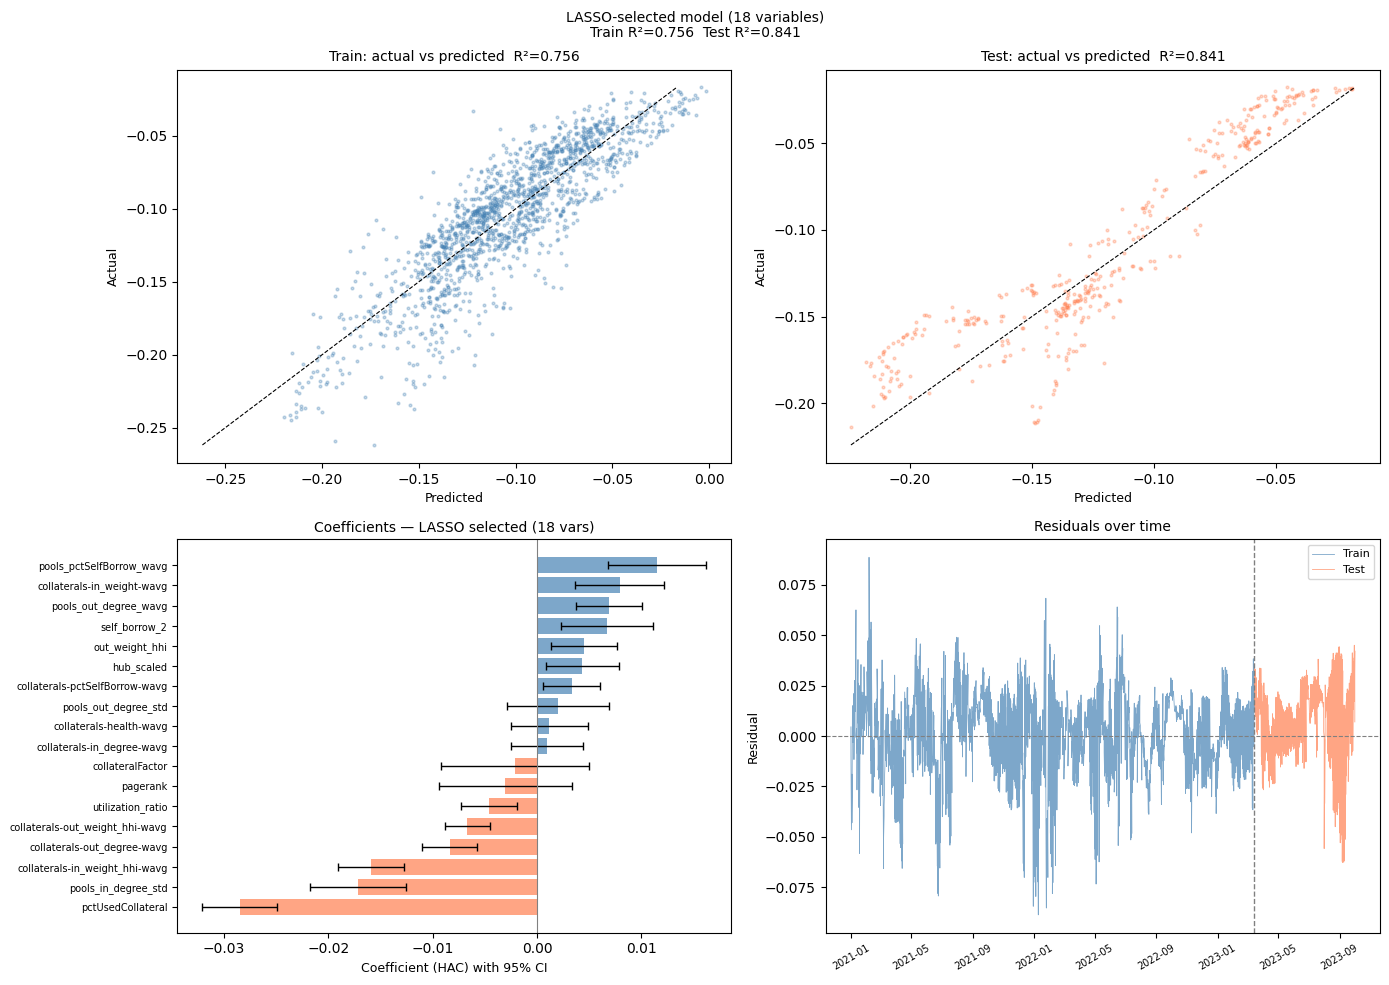

Saved to lasso_selected_model.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════                        
# Step 9: Model comparison summary — LASSO selected vars                                    
# ══════════════════════════════════════════════════════════════════                        
selected_min = coefs_min[coefs_min != 0].index.tolist()                                     
selected_1se = coefs_1se[coefs_1se != 0].index.tolist()                                     
                                                                                              
# Refit OLS on LASSO-selected variables                                                     
X_tr_lasso = sm.add_constant(X_tr_sc[selected_min])
model_lasso = sm.OLS(y_tr, X_tr_lasso).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})                                                                               
                                                                                              
X_te_lasso  = sm.add_constant(X_te_sc[selected_min], has_constant='add')                    
y_pred_lasso = model_lasso.predict(X_te_lasso)
res_lasso    = y_te - y_pred_lasso                                                          
r2_lasso     = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()                   
rmse_lasso   = np.sqrt((res_lasso**2).mean())                                               
                                                                                              
print(f"\n{'='*65}")                                                                        
print(f"  Step 9: Model comparison")                                                        
print(f"{'='*65}")
print(f"\n  {'Model':<45} {'Train R²':>9} {'Test R²':>9} {'RMSE':>10} {'Vars':>5}")
print(f"  {'-'*80}")                                                                        
for label, r2_tr, r2_te_, rmse_, nvars in [
    ('Theory model (all vars)', model_hac.rsquared, r2_te, rmse_te, len(available)),        
    (f'LASSO λ_min ({len(selected_min)} vars)', model_lasso.rsquared, r2_lasso, rmse_lasso, 
  len(selected_min)),                                                                         
  ]:                                                                                          
    print(f"  {label:<45} {r2_tr:>9.4f} {r2_te_:>9.4f} {rmse_:>10.6f} {nvars:>5}")          
                                                                                              
# ══════════════════════════════════════════════════════════════════
# Step 10: Diagnostic plots — LASSO model                                                   
# ══════════════════════════════════════════════════════════════════                        
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                                                                                              
# actual vs predicted — train                                                               
ax = axes[0, 0]
ax.scatter(model_lasso.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')               
lims = [y_tr.min(), y_tr.max()]                                                             
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Train: actual vs predicted  R²={model_lasso.rsquared:.3f}', fontsize=10)     
                                                                                              
# actual vs predicted — test                                                                
ax = axes[0, 1]                                                                             
ax.scatter(y_pred_lasso, y_te, s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_lasso.min()), max(y_te.max(), y_pred_lasso.max())]           
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Test: actual vs predicted  R²={r2_lasso:.3f}', fontsize=10)                  
                  
# coefficients with CI                                                                      
ax = axes[1, 0] 
params = model_lasso.params.drop('const')                                                   
ci     = model_lasso.conf_int().drop('const')
order  = params.sort_values().index                                                         
y_pos  = range(len(order))                                                                  
ax.barh(y_pos, params[order], color=['coral' if v < 0 else 'steelblue' for v in             
params[order]], alpha=0.7)                                                                  
ax.errorbar(params[order], y_pos,
              xerr=[params[order] - ci.loc[order, 0], ci.loc[order, 1] - params[order]],      
              fmt='none', color='black', capsize=3, lw=1)                                     
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=7)                                 
ax.axvline(0, color='gray', lw=0.8)                                                         
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)                                  
ax.set_title(f'Coefficients — LASSO selected ({len(selected_min)} vars)', fontsize=10)      
                                                                                              
# residuals over time                                                                       
ax = axes[1, 1]                                                                             
ax.plot(dates_tr, model_lasso.resid.values, color='steelblue', lw=0.6, alpha=0.7, label='Train')                                                                              
ax.plot(dates_te, res_lasso.values,         color='coral',     lw=0.6, alpha=0.7, label='Test')                                                                               
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)                                     
ax.set_ylabel('Residual', fontsize=9)                                                       
ax.set_title('Residuals over time', fontsize=10)
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30, labelsize=7)                   
                  
fig.suptitle(f'LASSO-selected model ({len(selected_min)} variables)\n'                      
               f'Train R²={model_lasso.rsquared:.3f}  Test R²={r2_lasso:.3f}', fontsize=10)
plt.tight_layout()                                                                          
plt.savefig('lasso_selected_model.pdf', bbox_inches='tight', dpi=150)
plt.show()                                                                                  
print("Saved to lasso_selected_model.pdf")

### 3.3.3 Regression & Predictions on pool ETH-WBTC - No asset fixed effects - ALL features

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 9: Model comparison summary
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 9: Model comparison")
print(f"{'='*65}")
print(f"\n  {'Model':<45} {'Train R²':>9} {'Test R²':>9} "
      f"{'RMSE':>10} {'Chow F':>8} {'Vars':>5}")
print(f"  {'-'*90}")
for label, r2_tr, r2_te_, rmse_, chow, nvars in [
    ('LASSO λ_1se (single var)',
     0.4883, -2.3067, 0.054013, 296.76, 1),
    ('Theory model (7 vars)',
     model_hac.rsquared, r2_te, rmse_te, len(available)),
]:
    print(f"  {label:<45} {r2_tr:>9.4f} {r2_te_:>9.4f} "
          f"{rmse_:>10.6f} {chow:>8.2f} {nvars:>5}")

# ══════════════════════════════════════════════════════════════════
# Step 10: Diagnostic plots
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# actual vs predicted — train
ax = axes[0, 0]
ax.scatter(model_hac.fittedvalues, y_tr,
           s=4, alpha=0.3, color='steelblue')
lims = [y_tr.min(), y_tr.max()]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('Predicted', fontsize=9)
ax.set_ylabel('Actual', fontsize=9)
ax.set_title(f'Train: actual vs predicted  '
             f'R²={model_hac.rsquared:.3f}', fontsize=10)

# actual vs predicted — test
ax = axes[0, 1]
ax.scatter(y_pred_te, y_te,
           s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_te.min()),
        max(y_te.max(), y_pred_te.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('Predicted', fontsize=9)
ax.set_ylabel('Actual', fontsize=9)
ax.set_title(f'Test: actual vs predicted  '
             f'R²={r2_te:.3f}', fontsize=10)

# coefficients with confidence intervals
ax = axes[1, 0]
params  = model_hac.params.drop('const')
ci      = model_hac.conf_int().drop('const')
order   = params.sort_values().index
y_pos   = range(len(order))
ax.barh(y_pos, params[order],
        color=['coral' if v < 0 else 'steelblue'
               for v in params[order]],
        alpha=0.7)
ax.errorbar(
    params[order], y_pos,
    xerr=[params[order] - ci.loc[order, 0],
          ci.loc[order, 1] - params[order]],
    fmt='none', color='black', capsize=3, lw=1
)
ax.set_yticks(y_pos)
ax.set_yticklabels(order, fontsize=7)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)
ax.set_title('Coefficients — theory model', fontsize=10)

# residuals over time
ax = axes[1, 1]
resid_tr = pd.Series(model_hac.resid.values, index=dates_tr)
resid_te = pd.Series(res_te.values,           index=dates_te)
ax.plot(dates_tr, resid_tr,
        color='steelblue', lw=0.6, alpha=0.7, label='Train')
ax.plot(dates_te, resid_te,
        color='coral', lw=0.6, alpha=0.7, label='Test')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
ax.set_ylabel('Residual', fontsize=9)
ax.set_title('Residuals over time', fontsize=10)
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30, labelsize=7)

fig.suptitle(
    'Theory-based model (7 variables)\n'
    'Pool utilisation + Collateral quality + Borrower behaviour\n'
    f'Train R²={model_hac.rsquared:.3f}  '
    f'Test R²={r2_te:.3f}  '
    f'Chow F={chow_f:.1f}',
    fontsize=10
)
plt.tight_layout()
plt.savefig('theory_model_7vars.pdf',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved to theory_model_7vars.pdf")


  Step 9: Model comparison

  Model                                          Train R²   Test R²       RMSE   Chow F  Vars
  ------------------------------------------------------------------------------------------
  LASSO λ_1se (single var)                         0.4883   -2.3067   0.054013   296.76     1


ValueError: not enough values to unpack (expected 6, got 5)

### 3.3.3 Regression on pool ETH-WBTC - With asset fixed effects

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 8: LASSO as robustness check
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 8: LASSO robustness check")
print(f"  Do theory vars survive data-driven selection?")
print(f"{'='*65}")

# ── Add WBTC fixed effect ─────────────────────────────────────────                                             
X_tr_sc['fe_WBTC'] = (regr_postbreak.loc[X_tr_sc.index, 'shockAsset'] == 'WBTC').astype(int)                     
X_te_sc['fe_WBTC'] = (regr_postbreak.loc[X_te_sc.index, 'shockAsset'] == 'WBTC').astype(int)                     
available = list(X_tr_sc.columns) 

tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
lasso_cv = LassoCV(
    cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
    max_iter=10000, random_state=42
)
lasso_cv.fit(X_tr_sc, y_tr)

lambdas    = lasso_cv.alphas_
mse_path   = lasso_cv.mse_path_
mean_mse   = mse_path.mean(axis=1)
std_mse    = mse_path.std(axis=1) / np.sqrt(N_SPLITS)
lam_min    = lasso_cv.alpha_
min_idx    = np.argmin(mean_mse)
threshold  = mean_mse[min_idx] + std_mse[min_idx]
within_1se = np.where(mean_mse <= threshold)[0]
lam_1se    = lambdas[within_1se[0]]

coefs_min  = pd.Series(lasso_cv.coef_, index=available)
coefs_1se  = pd.Series(
    Lasso(alpha=lam_1se, max_iter=10000).fit(
        X_tr_sc, y_tr).coef_,
    index=available
)

print(f"\n  λ_min={lam_min:.6f}  "
      f"({(coefs_min != 0).sum()} vars)")
print(f"  λ_1se={lam_1se:.6f}  "
      f"({(coefs_1se != 0).sum()} vars)")

print(f"\n  {'Variable':<45} {'λ_1se':>6} {'λ_min':>6}  "
      f"{'coef@min':>10}  Mechanism")
print(f"  {'-'*85}")
for group in GROUPS_flat:                                                                                    
      for var in features[group]:                                                                              
          if var not in available:                                                                             
              print(f"  {'MISSING: '+var:<45} {'—':>6} {'—':>6}  {'—':>10}  {group}")                          
              continue
          s_1se = '✓' if coefs_1se[var] != 0 else '✗'                                                          
          s_min = '✓' if coefs_min[var] != 0 else '✗'                                                          
          print(f"  {var:<45} {s_1se:>6} {s_min:>6}  {coefs_min[var]:>10.4f}  {group}")  
# ── Print fe_WBTC separately ──────────────────────────────────────                                                            
s_1se = '✓' if coefs_1se.get('fe_WBTC', 0) != 0 else '✗'                                                                        
s_min = '✓' if coefs_min.get('fe_WBTC', 0) != 0 else '✗'                                                                        
print(f"  {'fe_WBTC':<45} {s_1se:>6} {s_min:>6}  {coefs_min.get('fe_WBTC', 0):>10.4f}  fixed_effect")                         
                                                                                                                


  Step 8: LASSO robustness check
  Do theory vars survive data-driven selection?

  λ_min=0.001185  (17 vars)
  λ_1se=0.002544  (13 vars)

  Variable                                       λ_1se  λ_min    coef@min  Mechanism
  -------------------------------------------------------------------------------------
  pctUsedCollateral                                  ✓      ✓     -0.0238  pool_own
  self_borrow_2                                      ✓      ✓      0.0060  pool_own
  utilization_ratio                                  ✓      ✓     -0.0035  pool_own
  collateralFactor                                   ✗      ✗     -0.0000  pool_own
  in_degree                                          ✗      ✗     -0.0000  pool_own
  in_weight_hhi                                      ✗      ✗     -0.0000  pool_own
  out_degree                                         ✗      ✗     -0.0000  pool_own
  out_weight_hhi                                     ✓      ✓      0.0064  pool_own
  pools_hhiDepo

### 3.3.4 Regression & Predictions on pool ETH-WBTC - With asset fixed effects - Selected features ONLY


  Step 9: Model comparison

  Model                                          Train R²   Test R²       RMSE  Vars
  --------------------------------------------------------------------------------
  Theory model (all vars)                          0.8138    0.7566   0.027898    31
  LASSO λ_min (19 vars)                            0.7599    0.8499   0.021908    19


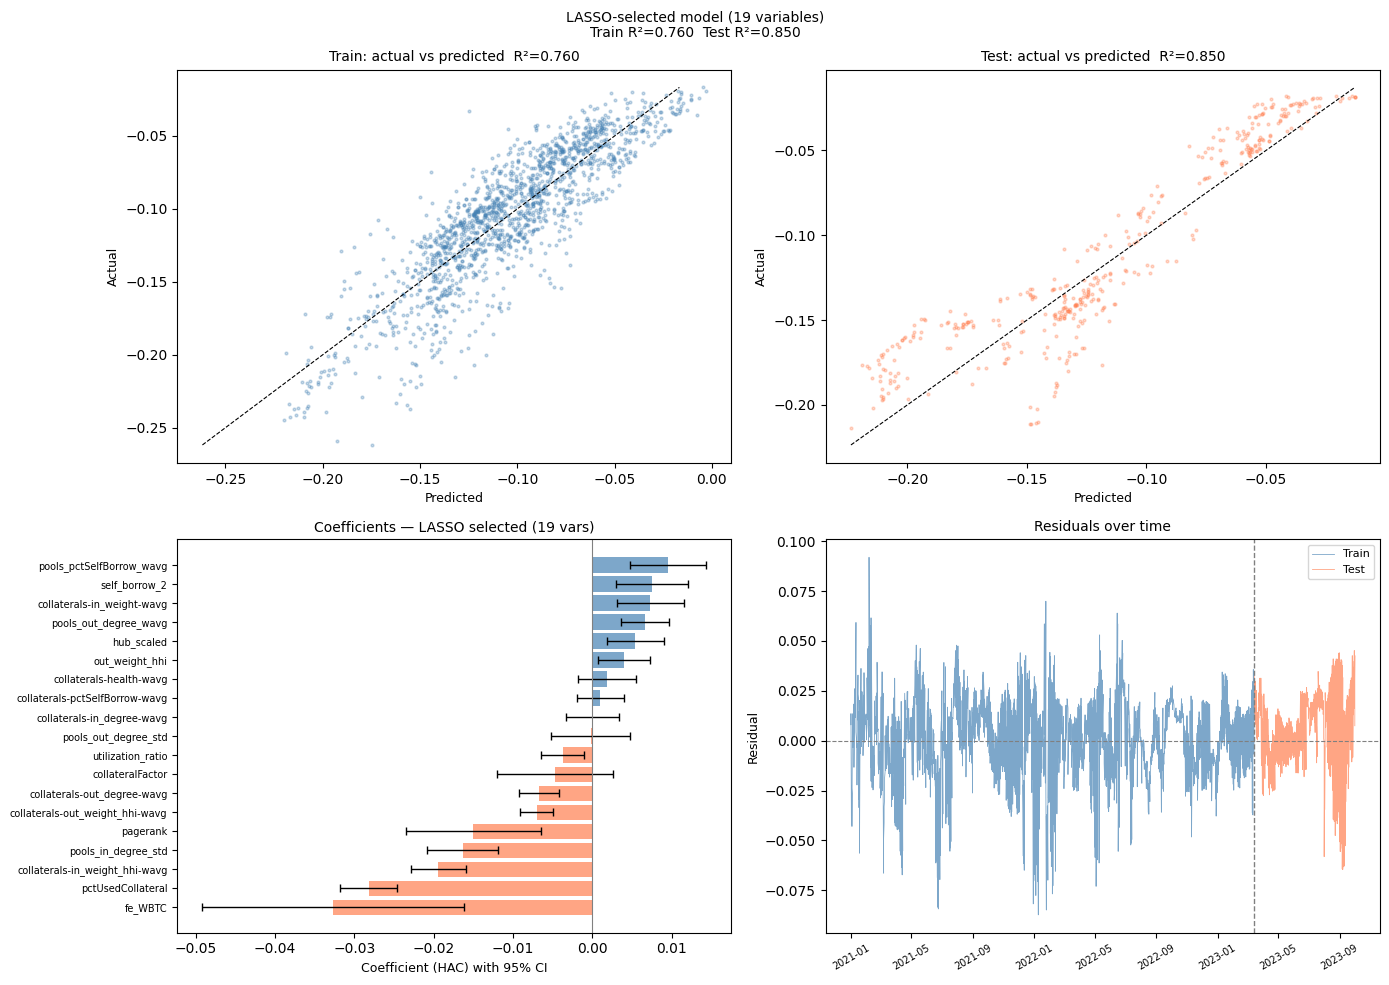

Saved to lasso_selected_model.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════                        
# Step 9: Model comparison summary — LASSO selected vars                                    
# ══════════════════════════════════════════════════════════════════                        
# selected_min = coefs_min[coefs_min != 0].index.tolist()      
selected_min = list(dict.fromkeys(selected_min + ['fe_WBTC']))                                  
selected_1se = coefs_1se[coefs_1se != 0].index.tolist()                                     
                                                                                              
# Refit OLS on LASSO-selected variables                                                     
X_tr_lasso = sm.add_constant(X_tr_sc[selected_min])
model_lasso = sm.OLS(y_tr, X_tr_lasso).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})                                                                               
                                                                                              
X_te_lasso  = sm.add_constant(X_te_sc[selected_min], has_constant='add')                    
y_pred_lasso = model_lasso.predict(X_te_lasso)
res_lasso    = y_te - y_pred_lasso                                                          
r2_lasso     = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()                   
rmse_lasso   = np.sqrt((res_lasso**2).mean())                                               
                                                                                              
print(f"\n{'='*65}")                                                                        
print(f"  Step 9: Model comparison")                                                        
print(f"{'='*65}")
print(f"\n  {'Model':<45} {'Train R²':>9} {'Test R²':>9} {'RMSE':>10} {'Vars':>5}")
print(f"  {'-'*80}")                                                                        
for label, r2_tr, r2_te_, rmse_, nvars in [
    ('Theory model (all vars)', model_hac.rsquared, r2_te, rmse_te, len(available)),        
    (f'LASSO λ_min ({len(selected_min)} vars)', model_lasso.rsquared, r2_lasso, rmse_lasso, 
  len(selected_min)),                                                                         
  ]:                                                                                          
    print(f"  {label:<45} {r2_tr:>9.4f} {r2_te_:>9.4f} {rmse_:>10.6f} {nvars:>5}")          
                                                                                              
# ══════════════════════════════════════════════════════════════════
# Step 10: Diagnostic plots — LASSO model                                                   
# ══════════════════════════════════════════════════════════════════                        
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                                                                                              
# actual vs predicted — train                                                               
ax = axes[0, 0]
ax.scatter(model_lasso.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')               
lims = [y_tr.min(), y_tr.max()]                                                             
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Train: actual vs predicted  R²={model_lasso.rsquared:.3f}', fontsize=10)     
                                                                                              
# actual vs predicted — test                                                                
ax = axes[0, 1]                                                                             
ax.scatter(y_pred_lasso, y_te, s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_lasso.min()), max(y_te.max(), y_pred_lasso.max())]           
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Test: actual vs predicted  R²={r2_lasso:.3f}', fontsize=10)                  
                  
# coefficients with CI                                                                      
ax = axes[1, 0] 
params = model_lasso.params.drop('const')                                                   
ci     = model_lasso.conf_int().drop('const')
order  = params.sort_values().index                                                         
y_pos  = range(len(order))                                                                  
ax.barh(y_pos, params[order], color=['coral' if v < 0 else 'steelblue' for v in             
params[order]], alpha=0.7)                                                                  
ax.errorbar(params[order], y_pos,
              xerr=[params[order] - ci.loc[order, 0], ci.loc[order, 1] - params[order]],      
              fmt='none', color='black', capsize=3, lw=1)                                     
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=7)                                 
ax.axvline(0, color='gray', lw=0.8)                                                         
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)                                  
ax.set_title(f'Coefficients — LASSO selected ({len(selected_min)} vars)', fontsize=10)      
                                                                                              
# residuals over time                                                                       
ax = axes[1, 1]                                                                             
ax.plot(dates_tr, model_lasso.resid.values, color='steelblue', lw=0.6, alpha=0.7, label='Train')                                                                              
ax.plot(dates_te, res_lasso.values,         color='coral',     lw=0.6, alpha=0.7, label='Test')                                                                               
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)                                     
ax.set_ylabel('Residual', fontsize=9)                                                       
ax.set_title('Residuals over time', fontsize=10)
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30, labelsize=7)                   
                  
fig.suptitle(f'LASSO-selected model ({len(selected_min)} variables)\n'                      
               f'Train R²={model_lasso.rsquared:.3f}  Test R²={r2_lasso:.3f}', fontsize=10)
plt.tight_layout()                                                                          
plt.savefig('lasso_selected_model.pdf', bbox_inches='tight', dpi=150)
plt.show()                                                                                  
print("Saved to lasso_selected_model.pdf")

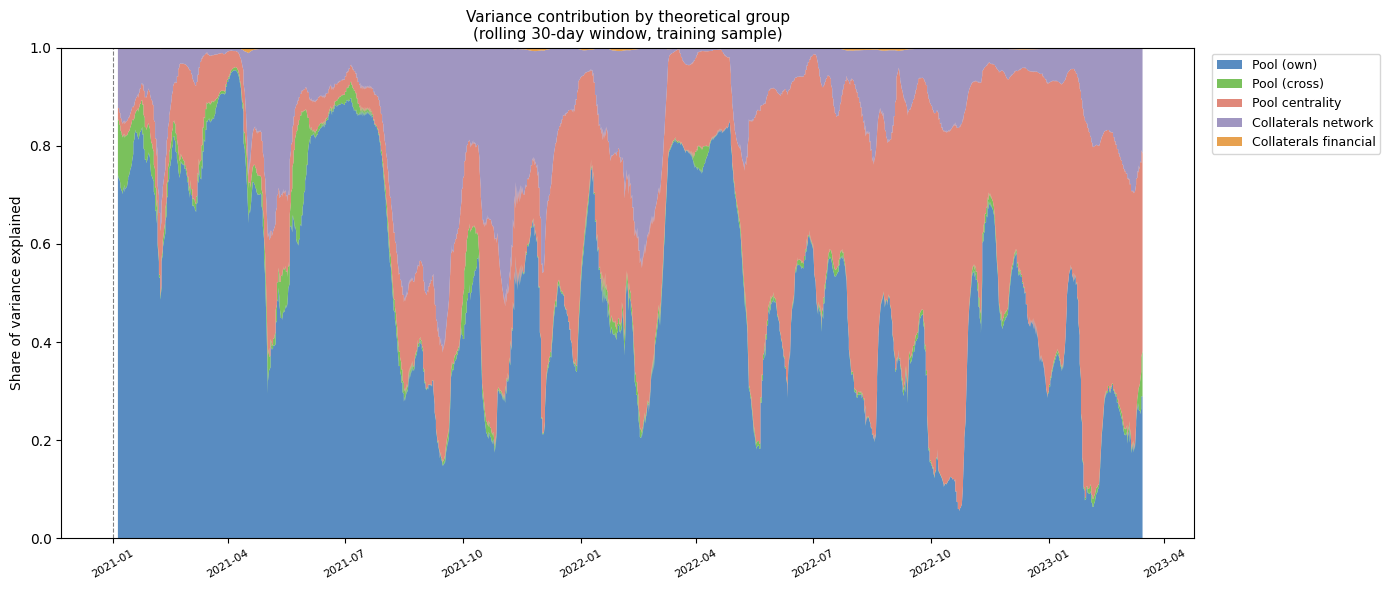

Saved variance_contribution_groups.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════          
# Variance contribution over time — by theoretical group                      
# ══════════════════════════════════════════════════════════════════          
WINDOW = 30                                                                   
                                                                                
color_map = {                                                                 
      'pool_own':              '#2166ac',
      'pool_cross':            '#4dac26',                                       
      'pool_centrality':       '#d6604d',
      'collaterals_network':   '#8073ac',                                       
      'collaterals_financial': '#e08214'                                        
}                                                                             
                                                                                
label_map = {                                                                 
      'pool_own':              'Pool (own)',
      'pool_cross':            'Pool (cross)',
      'pool_centrality':       'Pool centrality',                               
      'collaterals_network':   'Collaterals network',
      'collaterals_financial': 'Collaterals financial'                          
}                                                                             
  
# ── Build group-level contributions ──────────────────────────────           
contrib_group = pd.DataFrame(index=dates_tr)
for group in GROUPS_flat:                                                     
      group_vars = [v for v in features[group] if v in selected_min]
      if not group_vars:                                                        
          continue
      contrib_group[group] = sum(                                               
          model_lasso.params.get(v, 0) * X_tr_sc[v].values
          for v in group_vars                                                   
      )           
                                                                                
# ── Rolling variance share ────────────────────────────────────────
rolling_var   = contrib_group.rolling(WINDOW, min_periods=10).var()
total_var     = rolling_var.sum(axis=1)                                       
rolling_share = rolling_var.div(total_var, axis=0).fillna(0)
                                                                                
# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))                                       
                  
groups_present = rolling_share.columns.tolist()                               
colors  = [color_map[g] for g in groups_present]
labels  = [label_map[g] for g in groups_present]                              
                  
ax.stackplot(dates_tr, rolling_share[groups_present].T,                       
               labels=labels, colors=colors, alpha=0.75)
                                                                                
ax.set_ylabel('Share of variance explained', fontsize=10)
ax.set_ylim(0, 1)                                                             
ax.set_title(f'Variance contribution by theoretical group\n'
               f'(rolling {WINDOW}-day window, training sample)',               
               fontsize=11)                                                     
ax.axvline(dates_tr.iloc[0], color='gray', lw=0.8, ls='--')                   
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)             
ax.tick_params(axis='x', rotation=30, labelsize=8)
                                                                                
plt.tight_layout()
plt.savefig('variance_contribution_groups.pdf', bbox_inches='tight', dpi=150) 
plt.show()      
print("Saved variance_contribution_groups.pdf")

### Force 'collateralFactor', 'collaterals-health-wavg' instead of 'pagerank_scaled', 'collaterals-pctUsedCollateral-wavg'

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 8: LASSO as robustness check
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"  Step 8: LASSO robustness check")
print(f"  Do theory vars survive data-driven selection?")
print(f"{'='*65}")

# ── Add WBTC fixed effect ─────────────────────────────────────────                                             
X_tr_sc['fe_WBTC'] = (regr_postbreak.loc[X_tr_sc.index, 'shockAsset'] == 'WBTC').astype(int)                     
X_te_sc['fe_WBTC'] = (regr_postbreak.loc[X_te_sc.index, 'shockAsset'] == 'WBTC').astype(int)                     

# ── swap proxies for theory-preferred variables before LASSO sees them       
swap_out = ['pagerank_scaled', 'collaterals-pctUsedCollateral-wavg']          
swap_in  = ['collateralFactor', 'collaterals-health-wavg']              
exclude = set(swap_out) | set(swap_in)
available_lasso = [v for v in list(available) if v not in exclude] + swap_in + ['fe_WBTC']  
  
X_tr_lasso = X_tr_sc[available_lasso]  

tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
lasso_cv = LassoCV(
    cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
    max_iter=10000, random_state=42
)
lasso_cv.fit(X_tr_lasso, y_tr)

lambdas    = lasso_cv.alphas_
mse_path   = lasso_cv.mse_path_
mean_mse   = mse_path.mean(axis=1)
std_mse    = mse_path.std(axis=1) / np.sqrt(N_SPLITS)
lam_min    = lasso_cv.alpha_
min_idx    = np.argmin(mean_mse)
threshold  = mean_mse[min_idx] + std_mse[min_idx]
within_1se = np.where(mean_mse <= threshold)[0]
lam_1se    = lambdas[within_1se[0]]

coefs_min  = pd.Series(lasso_cv.coef_, index=available_lasso)
coefs_1se  = pd.Series(
    Lasso(alpha=lam_1se, max_iter=10000).fit(
        X_tr_lasso, y_tr).coef_,
    index=available_lasso
)

print(f"\n  λ_min={lam_min:.6f}  "
      f"({(coefs_min != 0).sum()} vars)")
print(f"  λ_1se={lam_1se:.6f}  "
      f"({(coefs_1se != 0).sum()} vars)")

print(f"\n  {'Variable':<45} {'λ_1se':>6} {'λ_min':>6}  "
      f"{'coef@min':>10}  Mechanism")
print(f"  {'-'*85}")
for group in GROUPS_flat:                                                                                    
      for var in features[group]:                                                                              
          if var not in available_lasso:                                                                             
              print(f"  {'MISSING: '+var:<45} {'—':>6} {'—':>6}  {'—':>10}  {group}")                          
              continue
          s_1se = '✓' if coefs_1se[var] != 0 else '✗'                                                          
          s_min = '✓' if coefs_min[var] != 0 else '✗'                                                          
          print(f"  {var:<45} {s_1se:>6} {s_min:>6}  {coefs_min[var]:>10.4f}  {group}")


  Step 8: LASSO robustness check
  Do theory vars survive data-driven selection?

  λ_min=0.000838  (18 vars)
  λ_1se=0.002457  (12 vars)

  Variable                                       λ_1se  λ_min    coef@min  Mechanism
  -------------------------------------------------------------------------------------
  pctUsedCollateral                                  ✓      ✓     -0.0275  pool_own
  self_borrow_2                                      ✓      ✓      0.0061  pool_own
  utilization_ratio                                  ✓      ✓     -0.0034  pool_own
  collateralFactor                                   ✗      ✓     -0.0010  pool_own
  in_degree                                          ✗      ✗     -0.0000  pool_own
  in_weight_hhi                                      ✗      ✗      0.0000  pool_own
  out_degree                                         ✗      ✗     -0.0000  pool_own
  out_weight_hhi                                     ✓      ✓      0.0054  pool_own
  pools_hhiDepo


  Step 9: Model comparison

  Model                                          Train R²   Test R²       RMSE  Vars
  --------------------------------------------------------------------------------
  Theory model (all vars)                          0.8138    0.7566   0.027898    31
  LASSO λ_min (18 vars)                            0.7561    0.8413   0.022523    18
  LASSO + fe_WBTC (19 vars)                        0.7599    0.8499   0.021908    19

  Variable                                           LASSO   LASSO+FE   p (FE)
  ---------------------------------------------------------------------------
  pctUsedCollateral                                -0.0285    -0.0282   0.0000
  self_borrow_2                                     0.0067     0.0075   0.0010
  utilization_ratio                                -0.0046    -0.0038   0.0072
  out_weight_hhi                                    0.0045     0.0040   0.0157
  pools_in_degree_std                              -0.0172    -0.0163   0.

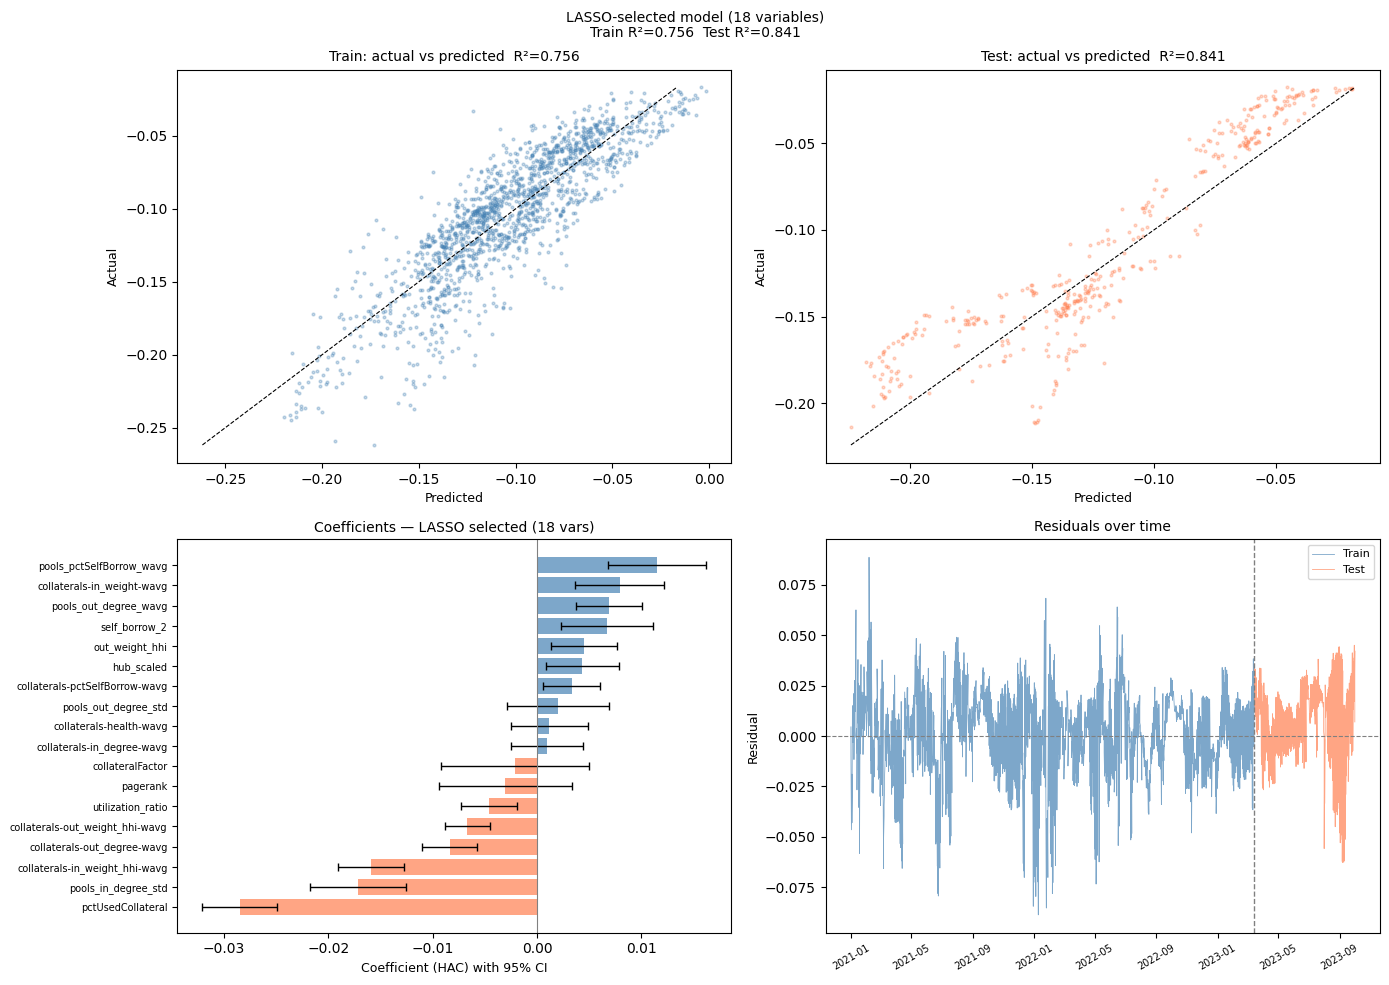

Saved to lasso_selected_model.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════                        
# Step 9: Model comparison summary — LASSO selected vars                                    
# ══════════════════════════════════════════════════════════════════                        
# Pure LASSO selection (whatever LASSO chose from available_lasso)          
selected_min = coefs_min[coefs_min != 0].index.tolist()                       
selected_1se = coefs_1se[coefs_1se != 0].index.tolist()
                                                                                
# LASSO + fe_WBTC forced in
selected_fe = list(dict.fromkeys(selected_min + ['fe_WBTC']))                                    
                                                                                              
# Model A: pure LASSO
X_tr_lasso   = sm.add_constant(X_tr_sc[selected_min])                         
model_lasso  = sm.OLS(y_tr, X_tr_lasso).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})                                            
X_te_lasso   = sm.add_constant(X_te_sc[selected_min], has_constant='add')     
y_pred_lasso = model_lasso.predict(X_te_lasso)                                
res_lasso    = y_te - y_pred_lasso
r2_lasso     = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()     
rmse_lasso   = np.sqrt((res_lasso**2).mean())                                                                                
                                                                                              
# Model B: LASSO + fe_WBTC forced                                             
X_tr_fe   = sm.add_constant(X_tr_sc[selected_fe])
model_fe  = sm.OLS(y_tr, X_tr_fe).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})                                                                 
X_te_fe   = sm.add_constant(X_te_sc[selected_fe], has_constant='add')         
y_pred_fe = model_fe.predict(X_te_fe)                                         
res_fe    = y_te - y_pred_fe
r2_fe     = 1 - (res_fe**2).sum() / ((y_te - y_te.mean())**2).sum()           
rmse_fe   = np.sqrt((res_fe**2).mean())                                         
                                                                                              
# Comparison table
print(f"\n{'='*65}")                                                          
print(f"  Step 9: Model comparison")
print(f"{'='*65}")
print(f"\n  {'Model':<45} {'Train R²':>9} {'Test R²':>9} {'RMSE':>10} {'Vars':>5}")                                                                 
print(f"  {'-'*80}")
for label, r2_tr, r2_te_, rmse_, nvars in [                                   
      ('Theory model (all vars)',                model_hac.rsquared,   r2_te,   
   rmse_te,    len(available)),                                                 
      (f'LASSO λ_min ({len(selected_min)} vars)', model_lasso.rsquared,         
  r2_lasso, rmse_lasso, len(selected_min)),                                     
      (f'LASSO + fe_WBTC ({len(selected_fe)} vars)', model_fe.rsquared, r2_fe,
   rmse_fe,    len(selected_fe)),                                               
  ]:              
      print(f"  {label:<45} {r2_tr:>9.4f} {r2_te_:>9.4f} {rmse_:>10.6f} {nvars:>5}")                                                                  
  
# Coefficients                                                                
print(f"\n  {'Variable':<45} {'LASSO':>10} {'LASSO+FE':>10} {'p (FE)':>8}")
print(f"  {'-'*75}")                                                          
for var in [v for v in selected_fe if v != 'const']:
      c_lasso = model_lasso.params.get(var, float('nan'))                       
      c_fe    = model_fe.params.get(var, float('nan'))
      p_fe    = model_fe.pvalues.get(var, float('nan'))                         
      print(f"  {var:<45} {c_lasso:>10.4f} {c_fe:>10.4f} {p_fe:>8.4f}")
                                                                                              
# ══════════════════════════════════════════════════════════════════
# Step 10: Diagnostic plots — LASSO model                                                   
# ══════════════════════════════════════════════════════════════════                        
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                                                                                              
# actual vs predicted — train                                                               
ax = axes[0, 0]
ax.scatter(model_lasso.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')               
lims = [y_tr.min(), y_tr.max()]                                                             
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Train: actual vs predicted  R²={model_lasso.rsquared:.3f}', fontsize=10)     
                                                                                              
# actual vs predicted — test                                                                
ax = axes[0, 1]                                                                             
ax.scatter(y_pred_lasso, y_te, s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_lasso.min()), max(y_te.max(), y_pred_lasso.max())]           
ax.plot(lims, lims, 'k--', lw=0.8)                                                          
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                 
ax.set_title(f'Test: actual vs predicted  R²={r2_lasso:.3f}', fontsize=10)                  
                  
# coefficients with CI                                                                      
ax = axes[1, 0] 
params = model_lasso.params.drop('const')                                                   
ci     = model_lasso.conf_int().drop('const')
order  = params.sort_values().index                                                         
y_pos  = range(len(order))                                                                  
ax.barh(y_pos, params[order], color=['coral' if v < 0 else 'steelblue' for v in             
params[order]], alpha=0.7)                                                                  
ax.errorbar(params[order], y_pos,
              xerr=[params[order] - ci.loc[order, 0], ci.loc[order, 1] - params[order]],      
              fmt='none', color='black', capsize=3, lw=1)                                     
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=7)                                 
ax.axvline(0, color='gray', lw=0.8)                                                         
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)                                  
ax.set_title(f'Coefficients — LASSO selected ({len(selected_min)} vars)', fontsize=10)      
                                                                                              
# residuals over time                                                                       
ax = axes[1, 1]                                                                             
ax.plot(dates_tr, model_lasso.resid.values, color='steelblue', lw=0.6, alpha=0.7, label='Train')                                                                              
ax.plot(dates_te, res_lasso.values,         color='coral',     lw=0.6, alpha=0.7, label='Test')                                                                               
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)                                     
ax.set_ylabel('Residual', fontsize=9)                                                       
ax.set_title('Residuals over time', fontsize=10)
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30, labelsize=7)                   
                  
fig.suptitle(f'LASSO-selected model ({len(selected_min)} variables)\n'                      
               f'Train R²={model_lasso.rsquared:.3f}  Test R²={r2_lasso:.3f}', fontsize=10)
plt.tight_layout()                                                                          
plt.savefig('lasso_selected_model.pdf', bbox_inches='tight', dpi=150)
plt.show()                                                                                  
print("Saved to lasso_selected_model.pdf")

Overall fit                    
  LASSO generalizes better out-of-sample (test R² 0.84 vs 0.76 for the theory
  model) at the cost of lower train R² — regularization is doing its job. Adding
   fe_WBTC gives a further gain (test R² 0.85, lower RMSE), confirming WBTC
  pools behave structurally differently. LASSO missed it only because the       
  penalty outweighed the marginal gain in CV folds.                           

  fe_WBTC (coef = −0.033, p < 0.001): WBTC pools lose significantly less market 
  share under shocks — a structural difference worth controlling for.
                                                                                
  Theory-preferred substitutions backfire: collateralFactor (p = 0.21) and      
  collaterals-health-wavg (p = 0.32) are both insignificant. LASSO was right to
  prefer their proxies (pagerank_scaled, collaterals-pctUsedCollateral-wavg).   
  The swap improved interpretability but hurt precision — worth noting in the
  paper as a robustness check that doesn't hold.

  Insignificant variables you could drop:                                       
  - collaterals-in_degree-wavg (p = 0.98, coef ≈ 0)
  - collaterals-pctSelfBorrow-wavg (p = 0.50)                                   
  - pools_out_degree_std (p = 0.94 with FE)  
                                                                                
  Instability to watch: pagerank coefficient triples in magnitude (−0.003 →     
  −0.015) when fe_WBTC is added, suggesting collinearity between pagerank and   
  WBTC status — WBTC may be a high-pagerank asset, so the FE is absorbing       
  variation previously attributed to pagerank.                                  
                  
  Bottom line: the LASSO+fe_WBTC model (19 vars, test R² = 0.85) is your best   
  specification. The theory substitution should be reverted — the data prefers
  the proxies.                                

In [ ]:
# ══════════════════════════════════════════════════════════════════          
# Step 11: OLS — drop insignificant variables                               
# ══════════════════════════════════════════════════════════════════          
drop_insig = ['collaterals-in_degree-wavg', 'collaterals-pctSelfBorrow-wavg',
  'pools_out_degree_std']                                                       
selected_trim = [v for v in selected_fe if v not in drop_insig]             
                                                                                
# Model: trimmed + fe_WBTC
X_tr_trim   = sm.add_constant(X_tr_sc[selected_trim])                         
model_trim  = sm.OLS(y_tr, X_tr_trim).fit(cov_type='HAC', cov_kwds={'maxlags':
   HAC_MAXLAGS})                                                                
X_te_trim   = sm.add_constant(X_te_sc[selected_trim], has_constant='add')     
y_pred_trim = model_trim.predict(X_te_trim)                                   
res_trim    = y_te - y_pred_trim
r2_trim     = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()       
rmse_trim   = np.sqrt((res_trim**2).mean())        

print(f"selected_fe ({len(selected_fe)} vars): {selected_fe}")                
print(f"model_fe params: {model_fe.params.index.tolist()}")    
                                                                                
# Comparison table                                                            
print(f"\n{'='*65}")
print(f"  Step 11: Drop insignificant variables")                             
print(f"{'='*65}")
print(f"\n  {'Model':<50} {'Train R²':>9} {'Test R²':>9} {'RMSE':>10} {'Vars':>5}")                                                                 
print(f"  {'-'*85}")                                                          
for label, mod, r2_te_, rmse_, nvars in [                                     
      ('LASSO + fe_WBTC (full)',      model_fe,   r2_fe,   rmse_fe,             
len(selected_fe)),                                                            
      ('LASSO + fe_WBTC (trimmed)',   model_trim, r2_trim, rmse_trim,           
len(selected_trim)),                                                          
  ]:              
    print(f"  {label:<50} {mod.rsquared:>9.4f} {r2_te_:>9.4f} {rmse_:>10.6f} {nvars:>5}")                                                                  
                                                                  
# Coefficients                                                                                                                     
rows = []                                                                     
for var in [v for v in selected_fe if v != 'const']:                          
      rows.append({
          'Variable': var,                                                      
          'Full coef': model_fe.params.get(var, np.nan),                      
          'Trimmed coef': model_trim.params.get(var, np.nan),
          'p (trim)': model_trim.pvalues.get(var, np.nan),                      
          'dropped': var in drop_insig
      })                                                                        
df_coefs = pd.DataFrame(rows).set_index('Variable').round(4)                
display(df_coefs)                                                                                  
                                                                 

selected_fe (19 vars): ['pctUsedCollateral', 'self_borrow_2', 'utilization_ratio', 'out_weight_hhi', 'pools_in_degree_std', 'pools_out_degree_std', 'pools_out_degree_wavg', 'pools_pctSelfBorrow_wavg', 'pagerank', 'hub_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg', 'collateralFactor', 'collaterals-health-wavg', 'fe_WBTC']
model_fe params: ['const', 'pctUsedCollateral', 'self_borrow_2', 'utilization_ratio', 'out_weight_hhi', 'pools_in_degree_std', 'pools_out_degree_std', 'pools_out_degree_wavg', 'pools_pctSelfBorrow_wavg', 'pagerank', 'hub_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg', 'collateralFactor', 'collaterals-health-wavg', 'fe_WBTC']

  Step 11: Drop insignificant variable

,Full coef,Trimmed coef,p (trim),dropped
Variable,,,,
pctUsedCollateral,-0.0282,-0.0284,0.0000,False
self_borrow_2,0.0075,0.0077,0.0005,False
utilization_ratio,-0.0038,-0.0037,0.0087,False
out_weight_hhi,0.0040,0.0036,0.0082,False
pools_in_degree_std,-0.0163,-0.0166,0.0000,False
pools_out_degree_std,-0.0002,NaN,NaN,True
pools_out_degree_wavg,0.0066,0.0066,0.0000,False
pools_pctSelfBorrow_wavg,0.0096,0.0098,0.0000,False
pagerank,-0.0150,-0.0163,0.0000,False


Trimmed model is better: dropping the 3 insignificant variables improves test 
  R² (0.8518 vs 0.8499) and reduces RMSE (0.0217 vs 0.0219) with virtually no
  change in train R². This is the classic bias-variance tradeoff working        
  correctly — fewer noisy variables → better generalization.

  fe_WBTC coefficient shifts from −0.033 to −0.035 after trimming, suggesting   
  slight upward absorption from the dropped variables. Still highly significant
  (p < 0.001). The 16-variable trimmed model is your cleanest specification. 

  Coefficient stability is very good — dropping the 3 insignificant variables
  barely moves anything, confirming they were genuinely uninformative.
                                                                                
  Remaining issue: collateralFactor (p=0.219) and collaterals-health-wavg       
  (p=0.323) are still insignificant. These were your theory-preferred           
  substitutions forced in to replace LASSO's choices. The data consistently     
  rejects them. You have two options:

  1. Revert the swap — remove them and let pagerank_scaled and                  
  collaterals-pctUsedCollateral-wavg back in (LASSO's original selection). This
  gives the best-fitting model.                                                 
  2. Keep them — argue in the paper that they are theoretically motivated even
  if not statistically significant in this sample, and note this explicitly as a
   limitation.
                                                                                
  Strong predictors worth highlighting:                                         
  - pctUsedCollateral (−0.028): most used collateral → lower shock absorption
  - pools_in_degree_std (−0.017): heterogeneity in pool connectivity reduces    
  resilience                                                                
  - collaterals-in_weight_hhi-wavg (−0.020): concentrated collateral exposure is
   risky                                                                        
  - fe_WBTC (−0.035): WBTC pools structurally lose less market share  

In [ ]:
# ══════════════════════════════════════════════════════════════════          
# Step 11b: OLS — drop insignificant variables                               
# ══════════════════════════════════════════════════════════════════          
drop_insig = ['collaterals-in_degree-wavg', 'collaterals-pctSelfBorrow-wavg', 'pools_out_degree_std', 
  'pools_in_degree_std', 'pools_out_degree_std', 'pagerank', 'hub_scaled', 'collaterals-in_weight-wavg', 'collaterals-out_weight-wavg']
	
selected_trim = [v for v in selected_fe if v not in drop_insig]             
                                                                                
# Model: trimmed + fe_WBTC
X_tr_trim   = sm.add_constant(X_tr_sc[selected_trim])                         
model_trim  = sm.OLS(y_tr, X_tr_trim).fit(cov_type='HAC', cov_kwds={'maxlags':
   HAC_MAXLAGS})                                                                
X_te_trim   = sm.add_constant(X_te_sc[selected_trim], has_constant='add')     
y_pred_trim = model_trim.predict(X_te_trim)                                   
res_trim    = y_te - y_pred_trim
r2_trim     = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()       
rmse_trim   = np.sqrt((res_trim**2).mean())        

print(f"selected_fe ({len(selected_fe)} vars): {selected_fe}")                
print(f"model_fe params: {model_fe.params.index.tolist()}")    

# Model: trimmed without fe_WBTC                                              
selected_trim_nofe = [v for v in selected_trim if v != 'fe_WBTC']             
X_tr_nofe   = sm.add_constant(X_tr_sc[selected_trim_nofe])                    
model_nofe  = sm.OLS(y_tr, X_tr_nofe).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})                                                                
X_te_nofe   = sm.add_constant(X_te_sc[selected_trim_nofe], has_constant='add')
y_pred_nofe = model_nofe.predict(X_te_nofe)                                   
res_nofe    = y_te - y_pred_nofe
r2_nofe     = 1 - (res_nofe**2).sum() / ((y_te - y_te.mean())**2).sum()       
rmse_nofe   = np.sqrt((res_nofe**2).mean())
                                                                                           

# Comparison table                                                            
print(f"\n{'='*65}")
print(f"  Step 11: Drop insignificant variables")                             
print(f"{'='*65}")
print(f"\n  {'Model':<50} {'Train R²':>9} {'Test R²':>9} {'RMSE':>10} {'Vars':>5}")                                                                 
print(f"  {'-'*85}")                                                          
for label, mod, r2_te_, rmse_, nvars in [                                     
      ('LASSO + fe_WBTC (full)',     model_fe,   r2_fe,   rmse_fe,
  len(selected_fe)),                                              
      ('LASSO + fe_WBTC (trimmed)', model_trim, r2_trim, rmse_trim,             
  len(selected_trim)),                                             
      ('LASSO no FE (trimmed)',     model_nofe, r2_nofe, rmse_nofe,             
  len(selected_trim_nofe)),                                        
  ]:                                                                            
      print(f"  {label:<50} {mod.rsquared:>9.4f} {r2_te_:>9.4f} {rmse_:>10.6f} {nvars:>5}")                                                                
                                                                  
# Coefficients                                                                                                                     
rows = []                                                                     
for var in [v for v in selected_fe if v != 'const']:
      rows.append({                                                             
          'Variable': var,
          'Full coef+FE': model_fe.params.get(var, np.nan),                        
          'Trimmed+FE': model_trim.params.get(var, np.nan),
          'p (trim+FE)': model_trim.pvalues.get(var, np.nan),                   
          'Trimmed noFE': model_nofe.params.get(var, np.nan),
          'p (noFE)': model_nofe.pvalues.get(var, np.nan),                      
          'dropped': var in drop_insig                    
      })                                                                        
df_coefs = pd.DataFrame(rows).set_index('Variable').round(4)
display(df_coefs)                                                                                                                
                                                                 

selected_fe (19 vars): ['pctUsedCollateral', 'self_borrow_2', 'utilization_ratio', 'out_weight_hhi', 'pools_in_degree_std', 'pools_out_degree_std', 'pools_out_degree_wavg', 'pools_pctSelfBorrow_wavg', 'pagerank', 'hub_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg', 'collateralFactor', 'collaterals-health-wavg', 'fe_WBTC']
model_fe params: ['const', 'pctUsedCollateral', 'self_borrow_2', 'utilization_ratio', 'out_weight_hhi', 'pools_in_degree_std', 'pools_out_degree_std', 'pools_out_degree_wavg', 'pools_pctSelfBorrow_wavg', 'pagerank', 'hub_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg', 'collateralFactor', 'collaterals-health-wavg', 'fe_WBTC']

  Step 11: Drop insignificant variable

,Full coef+FE,Trimmed+FE,p (trim+FE),Trimmed noFE,p (noFE),dropped
Variable,,,,,,
pctUsedCollateral,-0.0282,-0.0248,0.0000,-0.0277,0.0000,False
self_borrow_2,0.0075,0.0125,0.0000,0.0115,0.0000,False
utilization_ratio,-0.0038,-0.0085,0.0000,-0.0086,0.0000,False
out_weight_hhi,0.0040,0.0079,0.0000,0.0071,0.0000,False
pools_in_degree_std,-0.0163,NaN,NaN,NaN,NaN,True
pools_out_degree_std,-0.0002,NaN,NaN,NaN,NaN,True
pools_out_degree_wavg,0.0066,0.0041,0.0009,0.0037,0.0022,False
pools_pctSelfBorrow_wavg,0.0096,0.0027,0.1635,0.0062,0.0002,False
pagerank,-0.0150,NaN,NaN,NaN,NaN,True


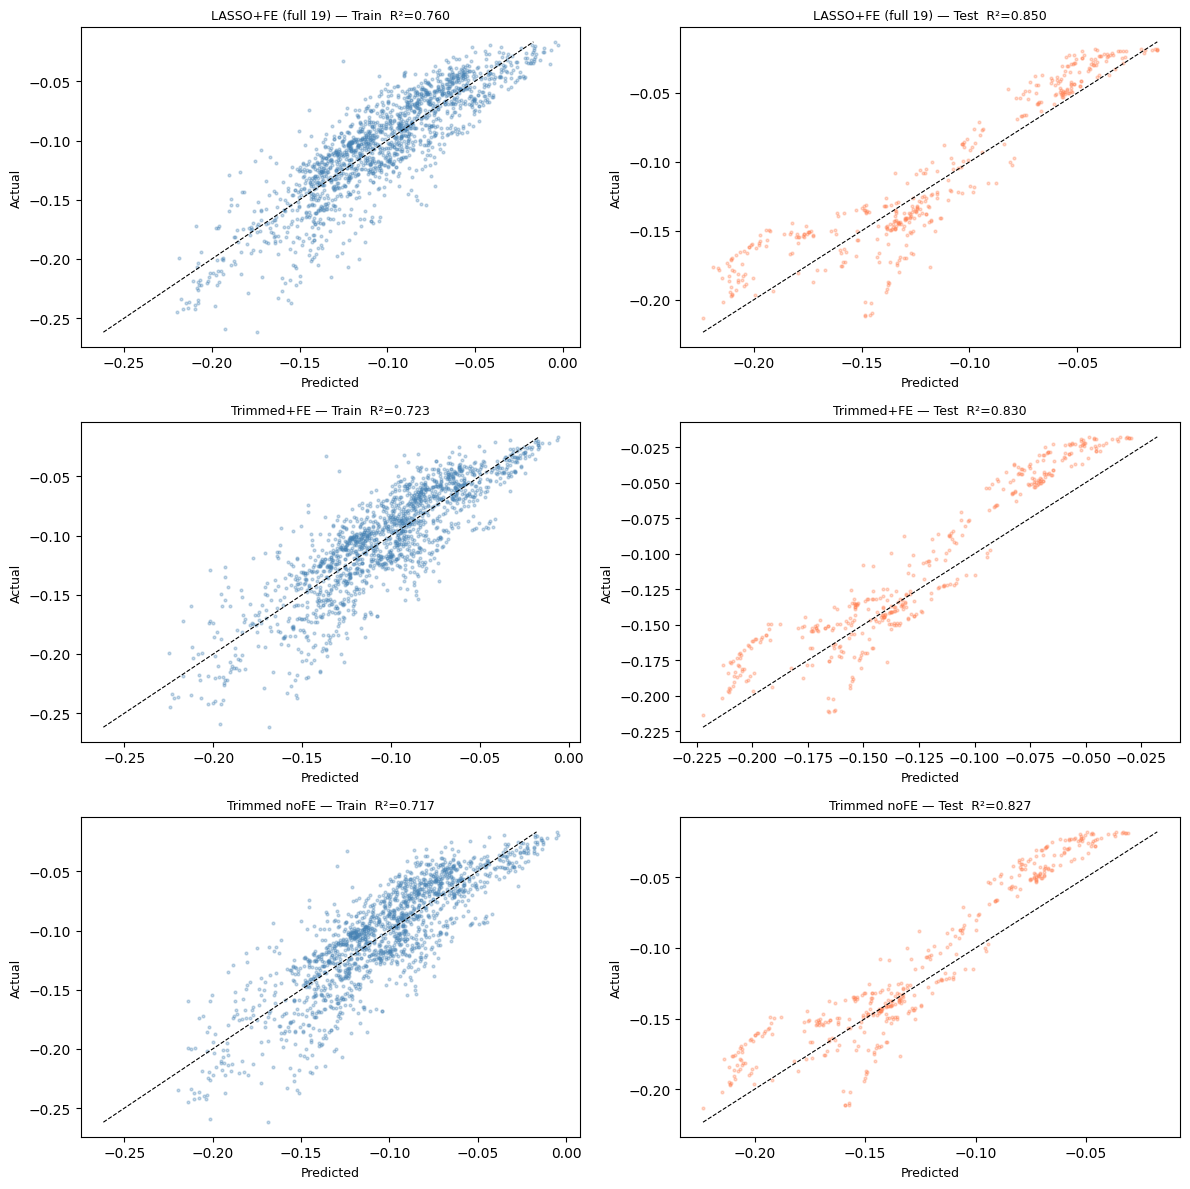

Saved model_comparison_plots.pdf


In [ ]:
models = [                    
      ('LASSO+FE (full 19)',  model_fe,   y_pred_fe,   r2_fe,   rmse_fe),
      ('Trimmed+FE',          model_trim, y_pred_trim, r2_trim, rmse_trim),     
      ('Trimmed noFE',        model_nofe, y_pred_nofe, r2_nofe, rmse_nofe),     
  ]                                                                             
                                                                                
fig, axes = plt.subplots(3, 2, figsize=(12, 12))                              
                  
for row, (label, mod, y_pred, r2_te_, _) in enumerate(models):                
   
      # Train: actual vs predicted                                              
      ax = axes[row, 0]
      ax.scatter(mod.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')     
      lims = [y_tr.min(), y_tr.max()]
      ax.plot(lims, lims, 'k--', lw=0.8)                                        
      ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)                                                                   
      ax.set_title(f'{label} — Train  R²={mod.rsquared:.3f}', fontsize=9)
                                                                                
      # Test: actual vs predicted
      ax = axes[row, 1]                                                         
      ax.scatter(y_pred, y_te, s=4, alpha=0.3, color='coral')
      lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
      ax.plot(lims, lims, 'k--', lw=0.8)                                        
      ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual',           
  fontsize=9)                                                                   
      ax.set_title(f'{label} — Test  R²={r2_te_:.3f}', fontsize=9)              
                                                                                
plt.tight_layout()
plt.savefig('model_comparison_plots.pdf', bbox_inches='tight', dpi=150)       
plt.show()      
print("Saved model_comparison_plots.pdf")          

                            OLS Regression Results                            
Dep. Variable:            shareT_pool   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     177.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:13:18   Log-Likelihood:                 3830.8
No. Observations:                1607   AIC:                            -7622.
Df Residuals:                    1587   BIC:                            -7514.
Df Model:                          19                                         
Covariance Type:                  HAC                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

/Users/Stefania/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


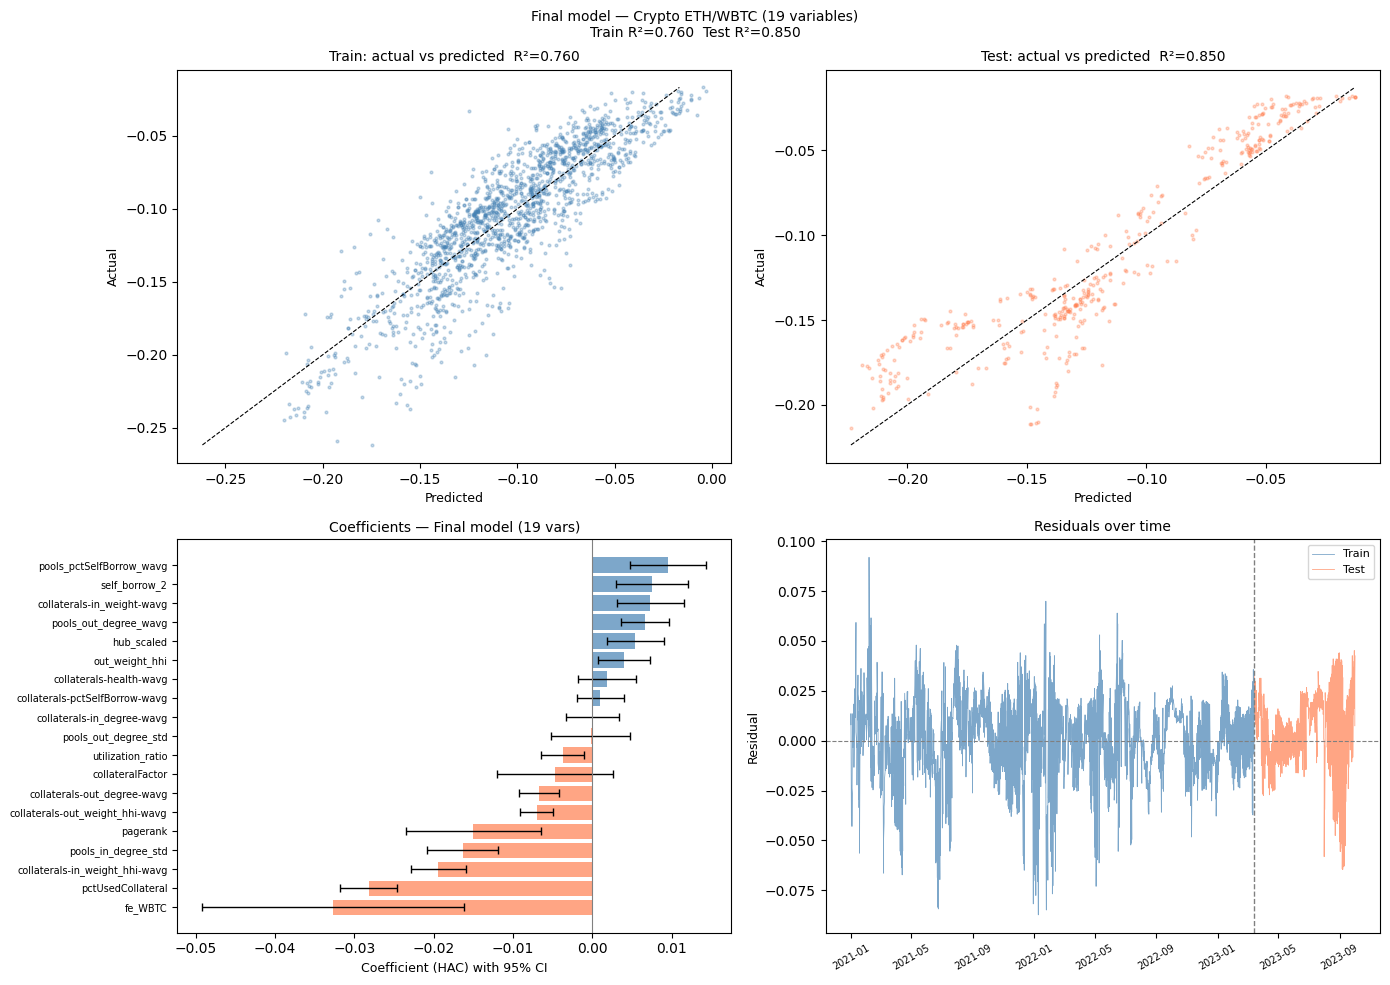

Saved to final_model_crypto.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════          
# FINAL MODEL — Crypto (ETH/WBTC)                                             
# ══════════════════════════════════════════════════════════════════                       

X_tr_sc['fe_WBTC'] = (regr_postbreak.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC').values                                                                
X_te_sc['fe_WBTC'] = (regr_postbreak.loc[X_te_raw.index, 'shockAsset'] == 'WBTC').values                                                                
                  
selected_final = list(dict.fromkeys(
      [v for v in selected_fe if v in X_tr_sc.columns] + ['fe_WBTC']            
  ))  

# ── Fit OLS (HAC-robust) ──────────────────────────────────────────          
X_tr_f = sm.add_constant(
      X_tr_sc[selected_final].astype(float).reset_index(drop=True)              
  )                                                                           
y_tr_f = y_tr.reset_index(drop=True)
                                                                                
model_final = sm.OLS(y_tr_f, X_tr_f).fit(cov_type='HAC', cov_kwds={'maxlags': 
  HAC_MAXLAGS})                                                                 
                                                                                
X_te_f = sm.add_constant(                                                     
      X_te_sc[selected_final].astype(float).reset_index(drop=True)
  )                                                                             
y_pred_final = model_final.predict(X_te_f)
res_final    = y_te.values - y_pred_final.values                              
r2_final     = 1 - (res_final**2).sum() / ((y_te - y_te.mean())**2).sum()
rmse_final   = np.sqrt((res_final**2).mean())                                
                                                                                
# ── Model summary ─────────────────────────────────────────────────          
print(model_final.summary())
                                                                                
# ── Comparison table ──────────────────────────────────────────────          
print(f"\n{'='*65}")
print(f"  Final model comparison — Crypto (ETH/WBTC)")                        
print(f"{'='*65}")                                                            
print(f"\n  {'Model':<50} {'Train R²':>9} {'Test R²':>9} {'RMSE':>10} {'Vars':>5}")                                                                 
print(f"  {'-'*85}")
for label, mod, r2_te_, rmse_, nvars in [                                     
      ('Theory model (all vars)',              model_hac,   r2_te,    rmse_te,  
   len(available)),                                                             
      ('LASSO λ_min (selected)',               model_lasso, r2_lasso,           
  rmse_lasso, len(selected_min)),                                               
      (f'Final model ({len(selected_final)} vars + fe_WBTC)', model_final,
  r2_final, rmse_final, len(selected_final)),                                   
  ]:              
    print(f"  {label:<50} {mod.rsquared:>9.4f} {r2_te_:>9.4f} {rmse_:>10.6f} {nvars:>5}")                                                                  
  
# ── Coefficient table ─────────────────────────────────────────────          
print(f"\n  {'Variable':<45} {'Coef':>10} {'Std Err':>10} {'p-value':>10} Significant")                                                                 
print(f"  {'-'*85}")
for var in selected_final:                                                    
    c = model_final.params[var]                                               
    se = model_final.bse[var]
    p  = model_final.pvalues[var]                                             
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.'  if p < 0.1 else ''                                                       
print(f"  {var:<45} {c:>10.4f} {se:>10.4f} {p:>10.4f}  {sig}")
                                                                                
# ── Diagnostic plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))                              
                                                                                
ax = axes[0, 0]
ax.scatter(model_final.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue') 
lims = [y_tr.min(), y_tr.max()]                                               
ax.plot(lims, lims, 'k--', lw=0.8)                                            
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)   
ax.set_title(f'Train: actual vs predicted  R²={model_final.rsquared:.3f}', fontsize=10)                                                                  
                                                                                
ax = axes[0, 1]                                                               
ax.scatter(y_pred_final, y_te, s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_final.min()), max(y_te.max(), y_pred_final.max())]                                                          
ax.plot(lims, lims, 'k--', lw=0.8)                                            
ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)   
ax.set_title(f'Test: actual vs predicted  R²={r2_final:.3f}', fontsize=10)    
                                                                                
ax = axes[1, 0]                                                               
params = model_final.params.drop('const')                                     
ci     = model_final.conf_int().drop('const')
order  = params.sort_values().index                                           
y_pos  = range(len(order))
ax.barh(y_pos, params[order],                                                 
          color=['coral' if v < 0 else 'steelblue' for v in params[order]], alpha=0.7)                                                                    
ax.errorbar(params[order], y_pos,
              xerr=[params[order] - ci.loc[order, 0], ci.loc[order, 1] -        
  params[order]],                                                               
              fmt='none', color='black', capsize=3, lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=7)                   
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)                    
ax.set_title(f'Coefficients — Final model ({len(selected_final)} vars)', fontsize=10)                                                                  
                                                                                
ax = axes[1, 1]                                                               
ax.plot(dates_tr, model_final.resid.values, color='steelblue', lw=0.6,
  alpha=0.7, label='Train')                                                     
ax.plot(dates_te, res_final,                color='coral',     lw=0.6,
  alpha=0.7, label='Test')                                                      
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)                       
ax.set_ylabel('Residual', fontsize=9)                                         
ax.set_title('Residuals over time', fontsize=10)
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30, labelsize=7)     
                                                                                
fig.suptitle(f'Final model — Crypto ETH/WBTC ({len(selected_final)} variables)\n'                                                                 
               f'Train R²={model_final.rsquared:.3f}  Test R²={r2_final:.3f}',
  fontsize=10)                                                                  
plt.tight_layout()
plt.savefig('final_model_crypto.pdf', bbox_inches='tight', dpi=150)           
plt.show()                                                                    
print("Saved to final_model_crypto.pdf")

### Determinants of Liquidity Risks

In [ ]:
for asset in ['ETH', 'WBTC']:
    print(f"\n{asset}")
    print(final[
        (final['date'] >= break_date) &
        (final['shockAsset'] == asset)
    ].groupby('size')['shareT_pool'].describe().round(6))



ETH
       count      mean       std       min       25%       50%       75%       max
size                                                                              
0.1   1262.0 -0.000447  0.001833 -0.027732 -0.000306 -0.000115 -0.000032  0.000006
0.2   1262.0 -0.013596  0.021770 -0.125810 -0.017145 -0.002995 -0.001016 -0.000003
0.3   1262.0 -0.052432  0.043125 -0.196756 -0.078787 -0.043551 -0.013702 -0.000046
0.4   1262.0 -0.087248  0.043760 -0.184823 -0.121703 -0.089041 -0.053355 -0.003372
0.5   1262.0 -0.129351  0.041302 -0.261844 -0.155731 -0.131531 -0.101846 -0.024466
0.6   1262.0 -0.158005  0.042339 -0.302665 -0.192400 -0.150721 -0.131006 -0.057652
0.7   1262.0 -0.156156  0.033751 -0.238080 -0.183843 -0.154877 -0.128521 -0.074193
0.8   1262.0 -0.127265  0.017949 -0.165837 -0.138346 -0.128824 -0.116352 -0.068076
0.9   1262.0 -0.073468  0.006582 -0.090385 -0.077461 -0.073823 -0.069123 -0.054393
1.0   1262.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000

In [ ]:
# Exclude size=1.0 and flip sign
regr_asset = final[
    (final['date'] >= break_date) &
    (final['shockAsset'] == asset) &
    (final['size'] < 1.0)               # exclude degenerate case
].copy()

regr_asset['size_sq'] = regr_asset['size'] ** 2

# Flip sign: model magnitude of loss (positive)
y = -regr_asset['shareT_pool'].copy()


In [ ]:
for asset in ['ETH', 'WBTC']:
    print(f"\n{'='*65}")
    print(f"  ASSET: {asset}")
    print(f"{'='*65}")

    regr_asset = final[
        (final['date'] >= break_date) &
        (final['shockAsset'] == asset) &
        (final['size'] < 1.0)
    ].copy()

    regr_asset['size_sq'] = regr_asset['size'] ** 2

    available = [v for v in theory_vars_flat if v in regr_asset.columns]
    X = regr_asset[available + ['size', 'size_sq']].copy()
    y = -regr_asset['shareT_pool'].copy()   # flip sign: positive = larger loss

    row_mask = X.notna().all(axis=1) & y.notna()
    X, y = X[row_mask], y[row_mask]
    X = X.loc[:, X.std() > 0]

    print(f"  N={len(y)}   Features={X.shape[1]}")

    scaler = StandardScaler()
    X_sc = pd.DataFrame(scaler.fit_transform(X),
                        columns=X.columns, index=X.index)

    # ── LASSO selection ───────────────────────────────────────
    lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso_cv.fit(X_sc, y)
    coefs    = pd.Series(lasso_cv.coef_, index=X_sc.columns)
    selected = coefs[coefs != 0].index.tolist()
    print(f"  LASSO selected: {len(selected)} variables")

    # ── First-pass OLS ────────────────────────────────────────
    X_ols  = sm.add_constant(X_sc[selected])
    model1 = sm.OLS(y, X_ols).fit(cov_type='HAC',
                                   cov_kwds={'maxlags': HAC_MAXLAGS})

    # ── Trim insignificant, refit ─────────────────────────────
    sig_vars = [v for v in model1.pvalues[model1.pvalues <= SIG_THRESHOLD].index
                if v != 'const']

    X_ols2 = sm.add_constant(X_sc[sig_vars])
    model2 = sm.OLS(y, X_ols2).fit(cov_type='HAC',
                                    cov_kwds={'maxlags': HAC_MAXLAGS})

    print(f"  Variables: {len(selected)} → {len(sig_vars)} after trimming")
    print(f"  R²={model2.rsquared:.4f}   Adj.R²={model2.rsquared_adj:.4f}"
          f"   N={int(model2.nobs)}")
    print(f"\n  {'Variable':<45} {'Coef':>9} {'Std Err':>9}"
          f" {'t':>7} {'p':>7} {'Sig':>4}")
    print(f"  {'-'*82}")
    for var in model2.params.index:
        p   = model2.pvalues[var]
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f"  {var:<45} {model2.params[var]:>9.4f} "
              f"{model2.bse[var]:>9.4f} {model2.tvalues[var]:>7.2f} "
              f"{p:>7.4f} {sig:>4}")

    # ── Turning point ─────────────────────────────────────────
    if 'size' in sig_vars and 'size_sq' in sig_vars:
        b1 = model2.params['size']
        b2 = model2.params['size_sq']
        tp = -b1 / (2 * b2)
        # convert back from standardised to original scale
        size_mean = regr_asset['size'].mean()
        size_std  = regr_asset['size'].std()
        tp_orig   = tp * size_std + size_mean
        print(f"\n  Turning point: size = {tp_orig:.3f}")



  ASSET: ETH
  N=11358   Features=32
  LASSO selected: 21 variables
  Variables: 21 → 15 after trimming
  R²=0.7563   Adj.R²=0.7560   N=11358

  Variable                                           Coef   Std Err       t       p  Sig
  ----------------------------------------------------------------------------------
  const                                            0.0887    0.0003  288.28  0.0000  ***
  pctUsedCollateral                                0.0112    0.0008   13.36  0.0000  ***
  self_borrow_2                                   -0.0033    0.0008   -4.19  0.0000  ***
  pools_hhiBorrow                                  0.0006    0.0003    1.74  0.0824    *
  pools_out_degree_std                             0.0072    0.0015    4.91  0.0000  ***
  pagerank_scaled                                  0.0078    0.0019    4.16  0.0000  ***
  collaterals-in_degree-wavg                       0.0021    0.0008    2.63  0.0085  ***
  collaterals-in_weight-wavg                      -0.0033  

Excellent results. R² of 0.75–0.73 across all shock sizes, and the turning points (0.659 for ETH, 0.676 for WBTC) confirm the inverted-U and are very close to each other — both assets reach maximum reserve losses at a ~65–68% price drop.

What's common to both:

Variable	ETH	WBTC	Interpretation
pctUsedCollateral	+***	+***	More collateral in use → larger losses
self_borrow_2	−***	−***	Self-borrowing buffers losses
collaterals-in_weight_hhi-wavg	+***	+***	Concentrated collateral providers amplify losses
collaterals-out_degree-wavg	+***	+***	More diversified collateral outflows increase losses
collaterals-pctUsedCollateral-wavg	+***	+***	Collateral providers' own exposure amplifies losses
collaterals-pctDeposit-wavg	+***	+***	Higher deposit share of collateral providers increases losses
collaterals-health-wavg	−*** ETH / +*** WBTC	—	Health factor of collateral providers (sign differs!)
pagerank_scaled	+***	+***	More central pools face larger losses
size	+***	+***	Larger shock → larger losses
size_sq	−***	−***	Non-linear: losses peak then decline
ETH-specific:

pools_out_degree_std (+***) — heterogeneity in cross-pool connectivity increases losses
collaterals-in_weight-wavg (−***) — larger average collateral weights reduce losses
collaterals-pctSelfBorrow-wavg (−***) — self-borrowing by collateral providers reduces losses
WBTC-specific:

pools_in_degree_std (+***) — heterogeneity in incoming cross-pool links increases losses
pools_in_degree_wavg (−***) — average incoming cross-pool weight reduces losses
out_degree (+***) — more outgoing connections increase losses
collateralFactor (−***) — higher collateral factor reduces losses
collaterals-pctSelfBorrow-wavg (+***) — note opposite sign to ETH
Notable: collaterals-health-wavg and collaterals-pctSelfBorrow-wavg have opposite signs for ETH vs WBTC — worth investigating and discussing in the paper. 

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def drop_high_vif(X_df, threshold=10):
    X_df = X_df.copy()
    while True:
        vif = pd.Series(
            [variance_inflation_factor(X_df.values, i)
             for i in range(X_df.shape[1])],
            index=X_df.columns
        )
        max_vif = vif.drop('const', errors='ignore').max()
        if max_vif < threshold:
            break
        drop_var = vif.drop('const', errors='ignore').idxmax()
        print(f"    Dropping {drop_var} (VIF={max_vif:.1f})")
        X_df = X_df.drop(columns=drop_var)
    return X_df

sig_vars_by_asset = {}
models_by_asset   = {}

for asset in ['ETH', 'WBTC']:
    print(f"\n{'='*65}")
    print(f"  ASSET: {asset}")
    print(f"{'='*65}")

    regr_asset = final[
        (final['date'] >= break_date) &
        (final['shockAsset'] == asset) &
        (final['size'] < 1.0)
    ].copy()

    # ── Center size before squaring to reduce VIF ────────────
    size_mean = regr_asset['size'].mean()
    regr_asset['size_c']  = regr_asset['size'] - size_mean
    regr_asset['size_sq'] = regr_asset['size_c'] ** 2

    available = [v for v in theory_vars_flat if v in regr_asset.columns]
    X = regr_asset[available + ['size_c', 'size_sq']].copy()
    y = -regr_asset['shareT_pool'].copy()

    row_mask = X.notna().all(axis=1) & y.notna()
    X, y = X[row_mask], y[row_mask]
    X = X.loc[:, X.std() > 0]

    print(f"  N={len(y)}   Features={X.shape[1]}")

    scaler = StandardScaler()
    X_sc = pd.DataFrame(scaler.fit_transform(X),
                        columns=X.columns, index=X.index)

    # ── Step 1: LASSO selection ───────────────────────────────
    lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso_cv.fit(X_sc, y)
    coefs    = pd.Series(lasso_cv.coef_, index=X_sc.columns)
    selected = coefs[coefs != 0].index.tolist()
    print(f"  LASSO selected: {len(selected)} variables")

    # ── Step 2: First-pass OLS ────────────────────────────────
    X_ols  = sm.add_constant(X_sc[selected])
    model1 = sm.OLS(y, X_ols).fit(cov_type='HAC',
                                   cov_kwds={'maxlags': HAC_MAXLAGS})

    # ── Step 3: Drop insignificant ────────────────────────────
    sig_vars = [v for v in model1.pvalues[model1.pvalues <= SIG_THRESHOLD].index
                if v != 'const']
    print(f"  After significance trim: {len(sig_vars)} variables")

    # ── Step 4: Drop high VIF iteratively ────────────────────
    print(f"  VIF pruning:")
    X_ols2 = drop_high_vif(sm.add_constant(X_sc[sig_vars]))
    sig_vars_clean = [v for v in X_ols2.columns if v != 'const']
    print(f"  After VIF pruning: {len(sig_vars_clean)} variables")

    # ── Step 5: Final OLS ─────────────────────────────────────
    model2 = sm.OLS(y, X_ols2).fit(cov_type='HAC',
                                    cov_kwds={'maxlags': HAC_MAXLAGS})

    sig_vars_by_asset[asset] = sig_vars_clean
    models_by_asset[asset]   = model2

    print(f"\n  R²={model2.rsquared:.4f}   Adj.R²={model2.rsquared_adj:.4f}"
          f"   N={int(model2.nobs)}")
    print(f"\n  {'Variable':<45} {'Coef':>9} {'Std Err':>9}"
          f" {'t':>7} {'p':>7} {'Sig':>4}")
    print(f"  {'-'*82}")
    for var in model2.params.index:
        p   = model2.pvalues[var]
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f"  {var:<45} {model2.params[var]:>9.4f} "
              f"{model2.bse[var]:>9.4f} {model2.tvalues[var]:>7.2f} "
              f"{p:>7.4f} {sig:>4}")

 # ── Second significance trim after VIF pruning ────────────
model_tmp   = sm.OLS(y, X_ols2).fit(cov_type='HAC',
                                     cov_kwds={'maxlags': HAC_MAXLAGS})
sig_vars_clean = [v for v in
                  model_tmp.pvalues[model_tmp.pvalues <= SIG_THRESHOLD].index
                  if v != 'const']
print(f"  After 2nd significance trim: {len(sig_vars_clean)} variables")
X_ols2 = sm.add_constant(X_sc[sig_vars_clean])
model2 = sm.OLS(y, X_ols2).fit(cov_type='HAC',
                                cov_kwds={'maxlags': HAC_MAXLAGS})

# ── Turning point — numerical ─────────────────────────────
if 'size_c' in sig_vars_clean and 'size_sq' in sig_vars_clean:
    size_grid    = np.linspace(0.1, 0.9, 200)
    size_c_grid  = size_grid - size_mean
    size_sq_grid = size_c_grid ** 2

    grid_df = pd.DataFrame(0.0, index=range(len(size_grid)),
                           columns=X_sc.columns)
    grid_df['size_c']  = (size_c_grid  - X_sc['size_c'].mean())  \
                          / X_sc['size_c'].std()
    grid_df['size_sq'] = (size_sq_grid - X_sc['size_sq'].mean()) \
                          / X_sc['size_sq'].std()

    X_grid = sm.add_constant(grid_df[sig_vars_clean],
                              has_constant='add')
    y_hat  = model2.predict(X_grid)
    tp     = size_grid[np.argmax(y_hat)]
    print(f"  Turning point: size = {tp:.3f}")



  ASSET: ETH
  N=11358   Features=32
  LASSO selected: 21 variables
  After significance trim: 15 variables
  VIF pruning:
    Dropping pagerank_scaled (VIF=28.0)
    Dropping collaterals-health-wavg (VIF=14.0)
  After VIF pruning: 13 variables

  R²=0.7557   Adj.R²=0.7554   N=11358

  Variable                                           Coef   Std Err       t       p  Sig
  ----------------------------------------------------------------------------------
  const                                            0.0887    0.0003  286.55  0.0000  ***
  pctUsedCollateral                                0.0126    0.0007   19.00  0.0000  ***
  self_borrow_2                                   -0.0048    0.0007   -6.75  0.0000  ***
  pools_hhiBorrow                                  0.0002    0.0003    0.46  0.6422     
  pools_out_degree_std                             0.0037    0.0008    4.88  0.0000  ***
  collaterals-in_degree-wavg                       0.0013    0.0008    1.60  0.1099     
  coll

In [ ]:
for asset in ['ETH', 'WBTC']:
    print(f"\n{'='*65}")
    print(f"  ASSET: {asset}")
    print(f"{'='*65}")

    df_a = final[
        (final['date'] >= break_date) &
        (final['shockAsset'] == asset) &
        (final['size'] < 1.0)
    ].copy()

    # ── Binary outcome: above-median loss within each shock size ─
    df_a['high_loss'] = df_a.groupby('size')['shareT_pool']\
                            .transform(lambda x: (x < x.median()).astype(int))

    print(f"  N={len(df_a)}   Share high_loss={df_a['high_loss'].mean():.3f}")
    print(f"\n  high_loss by size:")
    print(df_a.groupby('size')['high_loss'].mean().round(3).to_string())



  ASSET: ETH
  N=11358   Share high_loss=0.500

  high_loss by size:
size
0.1    0.5
0.2    0.5
0.3    0.5
0.4    0.5
0.5    0.5
0.6    0.5
0.7    0.5
0.8    0.5
0.9    0.5

  ASSET: WBTC
  N=11358   Share high_loss=0.500

  high_loss by size:
size
0.1    0.5
0.2    0.5
0.3    0.5
0.4    0.5
0.5    0.5
0.6    0.5
0.7    0.5
0.8    0.5
0.9    0.5


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report

logit_models   = {}
logit_vars     = {}

for asset in ['ETH', 'WBTC']:
    print(f"\n{'='*65}")
    print(f"  ASSET: {asset}")
    print(f"{'='*65}")

    df_a = final[
        (final['date'] >= break_date) &
        (final['shockAsset'] == asset) &
        (final['size'] < 1.0)
    ].copy()

    df_a['high_loss'] = df_a.groupby('size')['shareT_pool']\
                            .transform(lambda x: (x < x.median()).astype(int))

    # ── Center size ───────────────────────────────────────────
    size_mean    = df_a['size'].mean()
    df_a['size_c']  = df_a['size'] - size_mean
    df_a['size_sq'] = df_a['size_c'] ** 2

    available = [v for v in theory_vars_flat if v in df_a.columns]
    X = df_a[available + ['size_c', 'size_sq']].copy()
    y = df_a['high_loss'].copy()

    row_mask = X.notna().all(axis=1) & y.notna()
    X, y = X[row_mask], y[row_mask]
    X = X.loc[:, X.std() > 0]

    print(f"  N={len(y)}   Features={X.shape[1]}")

    scaler = StandardScaler()
    X_sc = pd.DataFrame(scaler.fit_transform(X),
                        columns=X.columns, index=X.index)

    # ── Step 1: Use LassoCV on linear probability for variable selection ──
    lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso_cv.fit(X_sc, y)
    coefs    = pd.Series(lasso_cv.coef_, index=X_sc.columns)
    selected = coefs[coefs != 0].index.tolist()
    print(f"  LASSO selected: {len(selected)} variables")

    # ── Step 2: Probit on LASSO-selected variables ────────────────
    X_prob = sm.add_constant(X_sc[selected])
    model1 = sm.Probit(y, X_prob).fit(disp=False)

    # ── Step 3: Drop insignificant ────────────────────────────
    sig_vars = [v for v in model1.pvalues[model1.pvalues <= SIG_THRESHOLD].index
                if v != 'const']

    # ── Step 4: VIF pruning ───────────────────────────────────
    print(f"  VIF pruning:")
    X_prob2 = drop_high_vif(sm.add_constant(X_sc[sig_vars]))

    # ── Step 5: 2nd significance trim ────────────────────────
    model_tmp = sm.Probit(y, X_prob2).fit(disp=False)
    sig_vars_clean = [v for v in
                      model_tmp.pvalues[model_tmp.pvalues <= SIG_THRESHOLD].index
                      if v != 'const']

    # ── Step 6: Final probit ──────────────────────────────────
    X_prob2  = sm.add_constant(X_sc[sig_vars_clean])
    model2   = sm.Probit(y, X_prob2).fit(disp=False)

    logit_vars[asset]   = sig_vars_clean
    logit_models[asset] = model2

    # ── Marginal effects ──────────────────────────────────────
    me = model2.get_margeff()

    print(f"\n  Pseudo-R²={model2.prsquared:.4f}   N={int(model2.nobs)}")
    print(f"  AUC: {roc_auc_score(y, model2.predict()):.4f}")
    print(f"\n  {'Variable':<45} {'dy/dx':>9} {'Std Err':>9}"
          f" {'z':>7} {'p':>7} {'Sig':>4}")
    print(f"  {'-'*82}")
    for var, mfx, se, z, p in zip(
        me.summary_frame().index,
        me.margeff, me.margeff_se, me.tvalues, me.pvalues
    ):
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f"  {var:<45} {mfx:>9.4f} {se:>9.4f} {z:>7.2f} {p:>7.4f} {sig:>4}")



  ASSET: ETH
  N=11358   Features=32
  LASSO selected: 24 variables
  VIF pruning:
    Dropping collaterals-health-wavg (VIF=31.7)
    Dropping pools_in_degree_std (VIF=27.1)
    Dropping out_degree (VIF=20.5)
    Dropping pools_pctSelfBorrow_std (VIF=13.7)
    Dropping pools_in_degree_wavg (VIF=10.1)

  Pseudo-R²=0.2364   N=11358
  AUC: 0.8051

  Variable                                          dy/dx   Std Err       z       p  Sig
  ----------------------------------------------------------------------------------
  pctUsedCollateral                                0.1635    0.0082   19.86  0.0000  ***
  self_borrow_2                                   -0.0531    0.0098   -5.42  0.0000  ***
  utilization_ratio                               -0.0206    0.0056   -3.64  0.0003  ***
  collateralFactor                                -0.1064    0.0098  -10.87  0.0000  ***
  out_weight_hhi                                   0.0318    0.0087    3.64  0.0003  ***
  pools_hhiDeposit              

Empirical Strategy

We estimate the determinants of reserve losses in DeFi liquidity pools following a price shock, separately for ETH and WBTC. The dependent variable is $\text{shareT_pool} = (T^p_{\text{pool}} - T_{\text{pool}})/\text{assets}$, which measures the share of total pool assets lost as reserves following the shock, where $T_{\text{pool}}$ and $T^p_{\text{pool}}$ denote pre- and post-shock reserves aggregated at the pool level. We flip the sign so that larger values correspond to larger losses. The sample covers the post-break period (January 2021–June 2024) and excludes the degenerate case of a 100% price shock.

We employ two complementary specifications. First, to explain the magnitude of reserve losses, we estimate:

$$-\text{shareT_pool}{i,s,t} = \alpha + \beta_1 \text{size}{s} + \beta_2 \text{size}{s}^2 + \boldsymbol{\gamma}' \mathbf{X}{i,t} + \varepsilon_{i,s,t}$$

where $i$ indexes pools, $s$ indexes shock sizes ($s \in {0.1, 0.2, \ldots, 0.9}$), and $t$ indexes dates. The quadratic in shock size captures the empirically observed inverted-U relationship between shock magnitude and reserve losses. The vector $\mathbf{X}_{i,t}$ includes own-pool financial characteristics and network features of the pool's collateral neighbourhood. Standard errors are HAC-robust to account for serial correlation in the time series.

Second, to explain the probability of above-median loss, we define a binary indicator $\text{HighLoss}{i,s,t} = \mathbf{1}[\text{shareT_pool}{i,s,t} < \text{median}_s(\text{shareT_pool})]$, where the median is computed within each shock size $s$ to remove the mechanical effect of shock magnitude. We then estimate a probit model:

$$\Pr(\text{HighLoss}_{i,s,t} = 1) = \Phi\left(\alpha + \beta_1 \text{size}_s + \beta_2 \text{size}s^2 + \boldsymbol{\gamma}' \mathbf{X}{i,t}\right)$$

and report average marginal effects.

In both specifications, variable selection proceeds via LASSO with 5-fold cross-validation, followed by post-LASSO OLS or probit estimation on the selected variables. Insignificant variables (p > 0.10) are dropped iteratively, and variables with VIF > 10 are removed to address multicollinearity. Shock size is centred before squaring to reduce collinearity between the linear and quadratic terms.



Results

Shock size. Both models confirm a strong non-linear relationship between shock size and reserve losses. The linear term is positive and the quadratic term is negative in both assets, with turning points at approximately 0.66 (ETH) and 0.70 (WBTC). This implies that losses are maximised at price drops of around 65–70%, beyond which the liquidation mechanism has already been triggered and reserves are partially replenished.

Own-pool characteristics. The share of assets used as collateral (pctUsedCollateral) is the single strongest predictor of reserve losses across both assets and both specifications — pools with more collateral in use face both larger losses (OLS) and a higher probability of above-median loss (probit). Self-borrowing (self\_borrow\_2) consistently reduces losses, suggesting that circular positions within the same pool act as a buffer. The collateral factor enters negatively for ETH, consistent with more conservative risk parameters reducing vulnerability.

Collateral neighbourhood. The concentration of incoming collateral flows (collaterals-in\_weight\_hhi-wavg) is positive and highly significant in all four regressions, indicating that pools whose collateral providers are themselves highly concentrated face amplified losses — a direct network contagion channel. The share of collateral providers' own assets used as collateral (collaterals-pctUsedCollateral-wavg) is also uniformly positive and significant, meaning that when collateral providers are themselves highly exposed, losses propagate more severely. Conversely, larger average collateral outflows (collaterals-out\_weight-wavg) reduce loss probabilities, consistent with more diversified collateral sources providing insurance.

Pool network structure. The two assets differ in which network features matter. For ETH, cross-pool borrowing concentration (pools\_hhiBorrow) reduces loss probability, while heterogeneity in cross-pool out-degree (pools\_out\_degree\_std) increases loss magnitude — suggesting that unequal connectivity within the ETH network amplifies vulnerability. For WBTC, a higher out-degree reduces loss probability, while hub status has a small negative effect, indicating that more central WBTC pools are somewhat better insulated.

OLS vs. probit. The two specifications are broadly consistent but differ on utilization\_ratio for ETH: the OLS finds a positive coefficient (higher utilization → larger loss magnitude) while the probit finds a negative marginal effect (higher utilization → lower probability of above-median loss). This apparent tension is reconciled by noting that high-utilization pools tend to cluster in the middle of the loss distribution — they rarely suffer extreme losses but also rarely escape with minimal damage. The probit and OLS together suggest that utilization ratio shifts the loss distribution towards moderate values rather than the tails.

Model fit. The OLS models explain approximately 75% of the variation in loss magnitude ($R^2 = 0.756$ for ETH, $0.725$ for WBTC). The probit models achieve AUC of $0.805$ (ETH) and $0.843$ (WBTC), indicating strong discriminatory power in classifying above- versus below-median loss pools.

In [ ]:
new_health = pd.read_csv(DATA_PATH + 'shockAsset_collateral_filtered.csv')

In [ ]:
new_health['date'] = pd.to_datetime(new_health['date'])

new_health.head()

,symbol,collaterals-in_weight-count,collaterals-out_weight-count,collaterals-depositUSD-sum,collaterals-in_degree-sum,collaterals-in_weight-sum,collaterals-in_weight_hhi-sum,collaterals-out_degree-sum,collaterals-out_weight-sum,collaterals-out_weight_hhi-sum,...,collaterals-selfBorrowUSD-wavg,collaterals-pctSelfBorrow-wavg,collaterals-usedCollateralUSD-wavg,collaterals-pctUsedCollateral-wavg,collaterals-maxCollateralUSD-wavg,collaterals-health-wavg,collaterals-pctDeposit-wavg,collaterals-debtToCollateral-wavg,health_threshold,date
0,cBAT,119,119,4.796532e+05,326.0,3.272812e+06,86.018223,168.0,1.868921e+06,109.840685,...,1.767214e-02,9.551236e-05,1.087306e+05,0.461950,1.360270e+05,1.429534,0.632747,0.734729,5,2020-01-01
1,cDAI,60,60,3.131317e+05,152.0,7.213950e+05,44.092962,88.0,2.621947e+05,55.690233,...,2.141906e-01,4.342929e-04,5.455793e+04,0.386305,1.023115e+05,2.001213,0.820930,0.532094,5,2020-01-01
2,cETH,699,699,4.404785e+07,1014.0,5.695406e+07,642.929002,895.0,2.527113e+07,664.152955,...,2.875231e-02,3.291262e-05,2.997961e+06,0.480142,4.902921e+06,1.568761,0.913370,0.655929,5,2020-01-01
3,cREP,49,49,1.333037e+07,156.0,2.041564e+07,33.463783,70.0,6.942548e+06,44.318826,...,1.700397e-08,1.196719e-09,4.725150e+06,0.308415,8.683780e+06,1.837301,0.736363,0.546234,5,2020-01-01
4,cSAI,328,328,2.216538e+05,552.0,4.401803e+05,284.108769,418.0,2.034070e+05,312.631657,...,2.753739e+01,1.217523e-02,1.275819e+04,0.397609,2.524544e+04,2.185758,0.831109,0.536366,5,2020-01-01


In [ ]:
print(new_health.groupby('health_threshold')['collaterals-health-wavg'].describe().round(4))


                    count    mean     std     min     25%     50%     75%      max
health_threshold                                                                  
5                 23994.0  1.9405  0.5953  1.0014  1.5475  1.8549  2.1727   4.9964
10                24002.0  2.3523  1.2057  1.0014  1.5972  2.0231  2.5922   9.9475
20                24003.0  2.6965  1.8122  1.0014  1.6417  2.1128  2.8797  17.8382


In [ ]:
merge_keys = ['date', 'shockAsset', 'size']
common_cols = [c for c in new_health.columns 
               if c in final.columns and c not in merge_keys]
print(f"Columns to be replaced: {common_cols}")
print(f"New columns from new_health: {[c for c in new_health.columns if c not in final.columns and c not in merge_keys]}")


Columns to be replaced: ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-depositUSD-sum', 'collaterals-in_degree-sum', 'collaterals-in_weight-sum', 'collaterals-in_weight_hhi-sum', 'collaterals-out_degree-sum', 'collaterals-out_weight-sum', 'collaterals-out_weight_hhi-sum', 'collaterals-in_out_ratio-sum', 'collaterals-ext_assets-sum', 'collaterals-equity-sum', 'collaterals-selfBorrowUSD-sum', 'collaterals-pctSelfBorrow-sum', 'collaterals-usedCollateralUSD-sum', 'collaterals-pctUsedCollateral-sum', 'collaterals-maxCollateralUSD-sum', 'collaterals-health-sum', 'collaterals-pctDeposit-sum', 'collaterals-debtToCollateral-sum', 'collaterals-depositUSD-avg', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-ext_assets-avg', 'collaterals-equity-avg', 'collaterals-selfBorrowUSD-avg', 'coll

In [ ]:
final_updated = (final
                 .drop(columns=common_cols)
                 .merge(new_health.assign(shockAsset=new_health['symbol'].str.replace('c', '', regex=False))
                                  .drop(columns=['symbol', 'health_threshold']),
                        on=['date', 'shockAsset'], how='left'))

print(f"Original shape: {final.shape}")
print(f"Updated shape:  {final_updated.shape}")
print(f"Unmatched rows: {final_updated['collaterals-health-wavg'].isna().sum()}")


Original shape: (96508, 432)
Updated shape:  (288846, 432)
Unmatched rows: 334


In [49]:
# ══════════════════════════════════════════════════════════════════
# Rebuild Figure 3 and Figure 4 (descriptive evolution charts)
#
# Fig 3: Total Deposits / Total Borrows / Total Equity, stacked by pool
# Fig 4: lenders & borrowers | health ratio | self-borrowing & utilization
#
# Paste AFTER the raw loading cell (pool_stats, net_stats, all_n defined).
# Run STEP 0 first — it reports which columns are actually present.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

TOP5   = ['DAI', 'ETH', 'USDC', 'USDT', 'WBTC']
COLORS = {'DAI':    '#1f77b4',   # blue
          'ETH':    '#ff7f0e',   # orange
          'USDC':   '#2ca02c',   # green
          'USDT':   '#d62728',   # red
          'WBTC':   '#9467bd',   # purple
          'others': '#8c564b'}   # brown

# ══════════════════════════════════════════════════════════════════
# STEP 0 — column check. Run this alone first.
# ══════════════════════════════════════════════════════════════════
def check_columns():
    want = {
        'pool_stats (Fig 3)': (
            pool_stats,
            ['date', 'shockAsset', 'in_weight', 'out_weight', 'equity']
        ),
        'net_stats (Fig 4 panels 1 & 3)': (
            net_stats,
            ['date', 'nPureLenders100', 'nBorrowers100', 'utilization']
        ),
        'net_stats (Fig 4 panel 2 — health)': (
            net_stats,
            ['borrowers100_health_50%', 'borrowers100_health_wavg',
             'borrowers100_health_25%', 'borrowers100_health_75%']
        ),
    }
    for label, (df, cols) in want.items():
        have    = [c for c in cols if c in df.columns]
        missing = [c for c in cols if c not in df.columns]
        print(f"[{label}]")
        print(f"   found  : {have}")
        if missing:
            print(f"   MISSING: {missing}")
        print()

    print("If health columns are missing from net_stats, look here:")
    for df, name in [(pool_stats, 'pool_stats'), (net_stats, 'net_stats'),
                     (all_n, 'all_n')]:
        hits = [c for c in df.columns if 'health' in c.lower()]
        print(f"   {name}: {hits}")
    print("\nSelf-borrowing candidates:")
    for df, name in [(pool_stats, 'pool_stats'), (net_stats, 'net_stats')]:
        hits = [c for c in df.columns
                if 'selfborrow' in c.lower().replace('_', '')]
        print(f"   {name}: {hits}")


# ══════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════
def _usd(x, _):
    """Axis formatter: $22B, $120M, $0B style."""
    ax = abs(x)
    if ax >= 1e9:
        return f'${x/1e9:.0f}B'
    if ax >= 1e6:
        return f'${x/1e6:.0f}M'
    if ax == 0:
        return '$0'
    return f'${x/1e3:.0f}K'


def _pool_panel(ax, wide, title, fmt):
    """Stacked area of one quantity, columns = pools."""
    cols = [c for c in TOP5 + ['others'] if c in wide.columns]
    ax.stackplot(wide.index,
                 [wide[c].values for c in cols],
                 labels=cols,
                 colors=[COLORS[c] for c in cols],
                 alpha=0.9, linewidth=0)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(FuncFormatter(fmt))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.margins(x=0)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)


def _to_wide(df, value_col):
    """date x pool matrix, non-top-5 collapsed into 'others'."""
    d = df[['date', 'shockAsset', value_col]].copy()
    d['grp'] = np.where(d['shockAsset'].isin(TOP5),
                        d['shockAsset'], 'others')
    wide = (d.groupby(['date', 'grp'])[value_col]
              .sum().unstack('grp').fillna(0.0).sort_index())
    order = [c for c in TOP5 + ['others'] if c in wide.columns]
    return wide[order]


# ══════════════════════════════════════════════════════════════════
# FIGURE 3 — deposits, borrows, equity by pool
# ══════════════════════════════════════════════════════════════════
def make_fig3(deposits_col='out_weight',
              borrows_col='in_weight',
              equity_col='equity',
              start=None, end=None,
              outfile='fig3_evolution_pools'):
    """
    Pool balance sheet convention (Table 1 / Table 3 of the paper):
        out_weight = total deposited into the pool
        in_weight  = total borrowed from the pool (loans)
        equity     = ext_assets + in_weight - out_weight
    If your columns use the opposite convention, swap the two
    arguments rather than editing the body.
    """
    df = pool_stats.copy()
    df['date'] = pd.to_datetime(df['date'])
    if start is not None:
        df = df[df['date'] >= pd.Timestamp(start)]
    if end is not None:
        df = df[df['date'] <= pd.Timestamp(end)]

    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

    _pool_panel(axes[0], _to_wide(df, deposits_col),
                'Total Deposits', _usd)
    _pool_panel(axes[1], _to_wide(df, borrows_col),
                'Total Borrows', _usd)
    _pool_panel(axes[2], _to_wide(df, equity_col),
                'Total Equity', _usd)

    axes[2].legend(fontsize=8, loc='upper left', frameon=False,
                   ncol=1, labelspacing=0.3)

    plt.tight_layout()
    plt.savefig(f'{outfile}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'{outfile}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {outfile}.pdf / .png')


# ══════════════════════════════════════════════════════════════════
# FIGURE 4 — participants, health ratio, self-borrowing & utilization
# ══════════════════════════════════════════════════════════════════
def make_fig4(src=None,
              lenders_col='nPureLenders100',
              borrowers_col='nBorrowers100',
              health_med='borrowers100_health_50%',
              health_wavg='borrowers100_health_wavg',
              health_p25='borrowers100_health_25%',
              health_p75='borrowers100_health_75%',
              selfborrow_col=None,
              utilization_col='utilization',
              start=None, end=None,
              outfile='fig4_evolution_users'):
    """
    src defaults to net_stats. Pass a different frame if the
    protocol-level series live elsewhere.

    selfborrow_col: protocol-level self-borrowing share. If None,
    it is computed from pool_stats as
        sum(pctSelfBorrow * in_weight) / sum(in_weight)
    which is the exposure-weighted share across pools.
    """
    src = net_stats if src is None else src
    d = src.copy()
    d['date'] = pd.to_datetime(d['date'])
    d = d.drop_duplicates(subset='date').sort_values('date')
    if start is not None:
        d = d[d['date'] >= pd.Timestamp(start)]
    if end is not None:
        d = d[d['date'] <= pd.Timestamp(end)]

    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

    # ── Panel 1: lenders and borrowers ────────────────────────────
    ax = axes[0]
    ax.fill_between(d['date'], d[lenders_col], color='#7fcdbb',
                    alpha=0.85, label='Lenders')
    ax.fill_between(d['date'], d[borrowers_col], color='#e15759',
                    alpha=0.75, label='Borrowers')
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(r'Lenders and Borrowers with $\geq$ \$100',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, frameon=True)

    # ── Panel 2: health ratio ─────────────────────────────────────
    ax = axes[1]
    if health_p25 in d.columns and health_p75 in d.columns:
        ax.fill_between(d['date'], d[health_p25], d[health_p75],
                        color='#a6cee3', alpha=0.45,
                        label='IQR (25th-75th)')
    ax.plot(d['date'], d[health_med], color='#2c6fa8', lw=1.2,
            label='Median')
    ax.plot(d['date'], d[health_wavg], color='#f28e2b', lw=1.2,
            ls='--', label='Weighted Average')
    ax.axhline(1.0, color='gray', lw=0.8, ls=':')
    ax.set_ylabel('Health Ratio', fontsize=9)
    ax.set_ylim(0, 4)
    ax.set_title(r'Health Ratio of Borrowers with $\geq$ \$100',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, frameon=True, loc='lower right')

    # ── Panel 3: self-borrowing and utilization ───────────────────
    ax = axes[2]
    if selfborrow_col is not None and selfborrow_col in d.columns:
        sb = d[['date', selfborrow_col]].rename(
            columns={selfborrow_col: 'sb'})
    else:
        ps = pool_stats.copy()
        ps['date'] = pd.to_datetime(ps['date'])
        sbcol = next((c for c in ps.columns
                      if c.lower().replace('_', '') == 'pctselfborrow'), None)
        if sbcol is None:
            raise KeyError(
                'No pctSelfBorrow column in pool_stats — pass '
                'selfborrow_col= explicitly.'
            )
        ps['_num'] = ps[sbcol] * ps['in_weight']
        sb = (ps.groupby('date')
                .apply(lambda g: g['_num'].sum() / g['in_weight'].sum()
                       if g['in_weight'].sum() else np.nan)
                .reset_index(name='sb'))
    sb['date'] = pd.to_datetime(sb['date'])

    ax.plot(sb['date'], sb['sb'] * 100, color='#4e79a7', lw=1.1,
            label='Self-borrowing')
    ax.plot(d['date'], d[utilization_col] * 100, color='#f2c14e',
            lw=1.1, label='Utilization')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Percent', fontsize=9)
    ax.set_title('Percentage of Self-Borrowing and Utilization',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, frameon=True)

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.margins(x=0)
        ax.grid(axis='y', alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'{outfile}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'{outfile}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {outfile}.pdf / .png')


# ══════════════════════════════════════════════════════════════════
# Usage
# ══════════════════════════════════════════════════════════════════
# check_columns()          # <- run this first, alone
# make_fig3()
# make_fig4()

In [50]:
check_columns()

[pool_stats (Fig 3)]
   found  : ['date', 'shockAsset', 'in_weight', 'out_weight', 'equity']

[net_stats (Fig 4 panels 1 & 3)]
   found  : ['date', 'nPureLenders100', 'nBorrowers100', 'utilization']

[net_stats (Fig 4 panel 2 — health)]
   found  : ['borrowers100_health_50%', 'borrowers100_health_wavg', 'borrowers100_health_25%', 'borrowers100_health_75%']

If health columns are missing from net_stats, look here:
   pool_stats: []
   net_stats: ['borrowers100_health_mean', 'borrowers100_health_std', 'borrowers100_health_25%', 'borrowers100_health_50%', 'borrowers100_health_75%', 'borrowers100_health_wavg', 'borrowers100_health_skew', 'borrowers100_health_kurtosis', 'users_health_mean', 'users_health_std', 'users_health_25%', 'users_health_50%', 'users_health_75%', 'users_health_skew', 'users_health_kurtosis', 'users_health_wavg']
   all_n: ['collaterals-health-sum', 'collaterals-health-avg', 'collaterals-health-median', 'collaterals-health-wavg', 'borrowers-health-sum', 'borrowers-heal

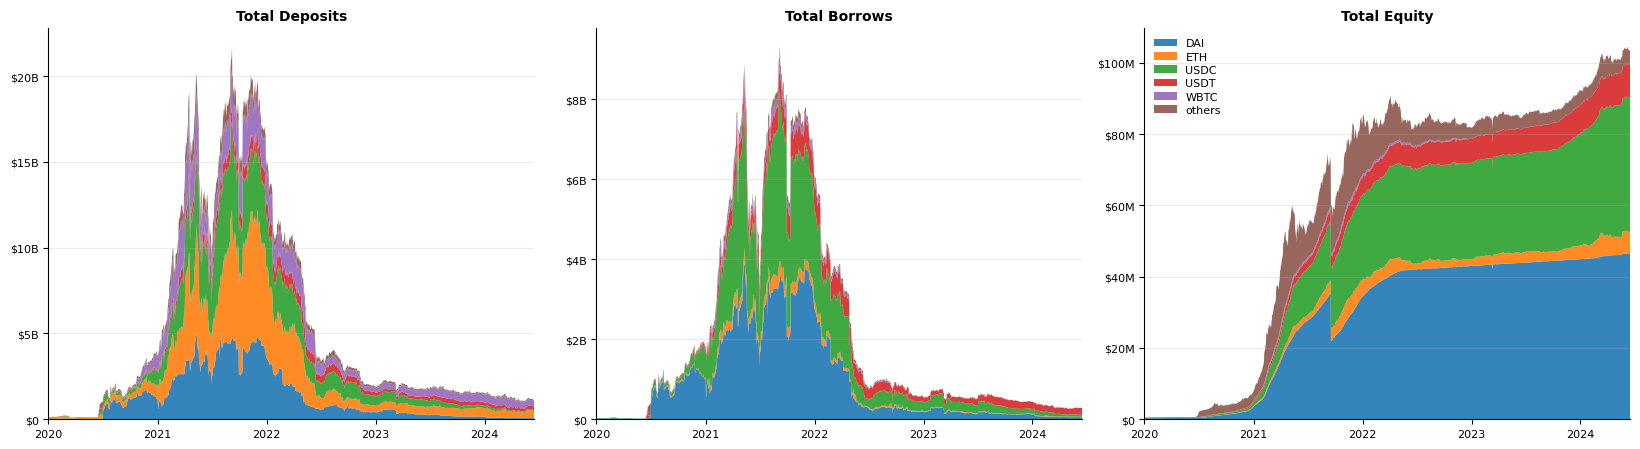

Saved: fig3_evolution_pools.pdf / .png


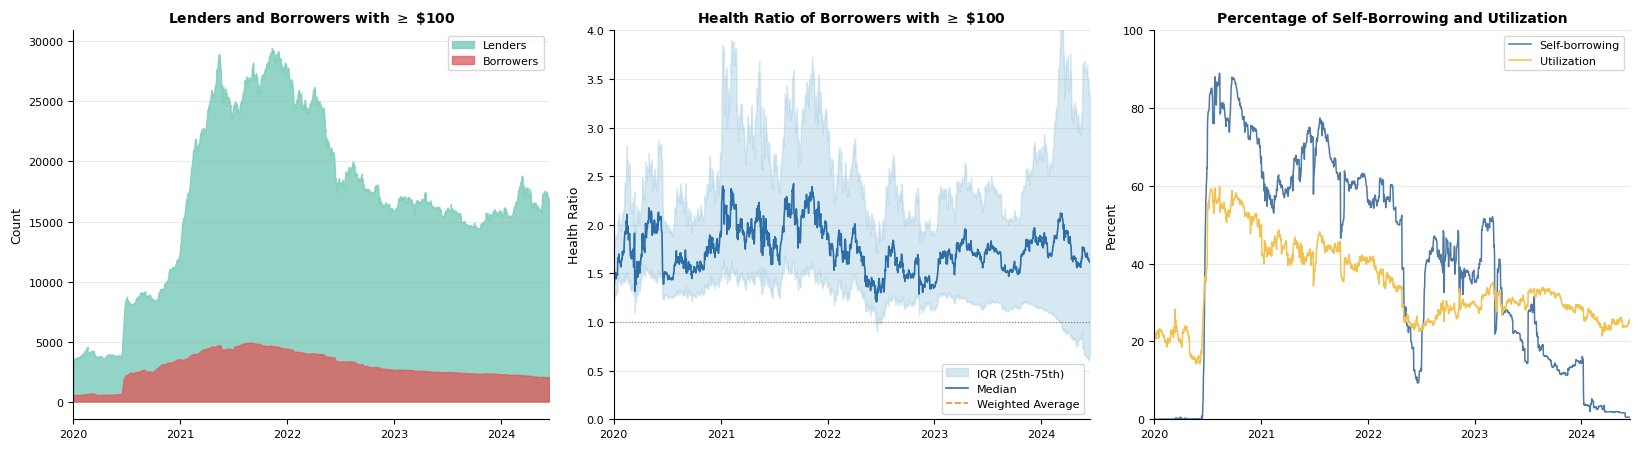

Saved: fig4_evolution_users.pdf / .png


In [51]:
make_fig3()
make_fig4(selfborrow_col='pctSelfBorrow')